<a id="home"></a>
# IEEE Fraud Detection transactions columns reference

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.display import HTML
import warnings
warnings.filterwarnings("ignore")

INPUT_DIR = '../input/'
COLS_TO_SHOW = 150

def h(content):
    display(HTML(content))

def timehist1(col):
    N = 8000 if col in ['TransactionAmt'] else 9999999999999999 # clip trans amount for better view
    tr[tr['isFraud'] == 0].set_index('TransactionDT')[col].clip(0, N).plot(style='.', title='Hist ' + col, figsize=(15, 3))
    tr[tr['isFraud'] == 1].set_index('TransactionDT')[col].clip(0, N).plot(style='.', title='Hist ' + col, figsize=(15, 3))
    te.set_index('TransactionDT')[col].clip(0, N).plot(style='.', title=col + ' values over time (blue=no-fraud, orange=fraud, green=test)', figsize=(15, 3))
    plt.show()
    
def _desc(data, col, label):
    d0 = data.describe().reset_index()
    d0.columns = [col, label]
    return d0.append({col:'unique values', label:data.unique().shape[0]}, ignore_index=True) \
             .append({col:'NaNs', label:data.isnull().sum()}, ignore_index=True) \
             .append({col:'NaNs share', label:np.round(data.isnull().sum() / data.shape[0], 4)}, ignore_index=True) \
    
def desc1(col):
    d0 = _desc(tr[col], col, 'Train')
    d1 = _desc(tr.loc[tr['isFraud'] == 1, col], col, 'Train fraud')
    d2 = _desc(tr.loc[tr['isFraud'] == 0, col], col, 'Train Not fraud')
    d3 = _desc(te[col], col, 'Test')
    n_public = int(te.shape[0] * 0.2)
    d4 = _desc(te.loc[:n_public, col], col, 'Test public')
    d5 = _desc(te.loc[n_public:, col], col, 'Test private')
    dd = d0.merge(d1).merge(d2).merge(d3).merge(d4).merge(d5)
    display(dd)
    
    if col not in ['TransactionID']:
        h('<b>Most popular values (NaN = -999):</b>')
        N = 10
        d0 = tr[['isFraud',col]].fillna(-999).groupby(col)['isFraud'].agg(['size','mean','sum']).reset_index().sort_values('size', ascending=False).reset_index(drop=True)
        d1 = te[['TransactionID',col]].fillna(-999).groupby(col)['TransactionID'].count().reset_index()
        dd = d0.merge(d1, how='left', on=col).head(N)
        dd = dd.rename({'size':'Count in train (desc)','mean':'Mean target','sum':'Sum target','TransactionID':'Count in test'}, axis=1)
        display(dd)

        h('<b>Biggest fraud sum values in train (NaN = -999):</b>')
        dd = d0.sort_values('sum', ascending=False).reset_index(drop=True).head(N).merge(d1, how='left', on=col)
        dd = dd.rename({'size':'Count in train','mean':'Mean target','sum':'Sum target (desc)','TransactionID':'Count in test'}, axis=1)
        display(dd)

def hist1(col):
    plt.figure(figsize=(15, 3))
    plt.subplot(121)
    plt.hist(tr[col], bins=70);
    plt.title('Train histogram: ' + col);
    plt.subplot(122)
    plt.hist(te[col], bins=70);
    plt.title('Test histogram: ' + col);
    plt.show()

def corr1(col):
    N = None #10000
    num_vars = [f for f in tr.columns if tr[f].dtype != 'object']
    trx = tr.head(N) if N is not None else tr.copy()
    corrs = trx[num_vars].corrwith(trx[col]).reset_index().sort_values(0, ascending=False).reset_index(drop=True).rename({'index':'Column',0:'Correlation with ' + col}, axis=1)
    h('<b>Most correlated values with ' + col + ':</b>')
    trx = pd.concat([corrs.head(6), corrs.dropna().tail(5)])
    def linkx(val):
        return '<a href="#c_{}">{}</a>'.format(val, val) if val in included_cols else val
    trx['Column'] = trx['Column'].apply(linkx)
    h(trx.to_html(escape=False))
    
def numeric(col):
    timehist1(col)
    hist1(col)
    desc1(col)
    corr1(col) 
    
def categorical(col):
    desc1(col)

def proc(col):
    if col not in ['isFraud','TransactionDT']:
        h('<h3 id="c_' + col + '">' + col + '</h3>' + '<a style="font-size:11px" href="#home">(Jump to top)</a>')
        categorical(col) if tr[col].dtype == 'object' else numeric(col)
        
tr = pd.read_csv(INPUT_DIR + 'train_transaction.csv')
te = pd.read_csv(INPUT_DIR + 'test_transaction.csv')
trid = pd.read_csv(INPUT_DIR + 'train_identity.csv')
teid = pd.read_csv(INPUT_DIR + 'test_identity.csv')

included_cols = list(tr.columns.values[:COLS_TO_SHOW])
split_on = ['TransactionID','card1','addr1','C1','D1','M1','V1']
h('<b>Links to column info:</b> ' + ', '.join([('<li>' if col in split_on else '') + '<a href="#c_' + col + '">' + col + '</a>' for col in included_cols]))
h('Train transactions shape: <b>' + str(tr.shape) + '</b>, identity <b>' + str(trid.shape) + '</b>' + 
  '<br>Test transactions shape: <b>' + str(te.shape) + '</b>, identity <b>' + str(teid.shape) + '</b>')
h('Train transactions preview:')
display(tr.head(10))

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,debit,272.0,87.0,36.0,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,debit,126.0,87.0,0.0,NaN,yahoo.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,debit,325.0,87.0,NaN,NaN,mail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,debit,337.0,87.0,NaN,NaN,anonymous.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,debit,204.0,87.0,19.0,NaN,yahoo.com,NaN,2.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,1.0,0.0,12.0,2.0,61.0,61.0,30.0,318.0,30.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,495.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


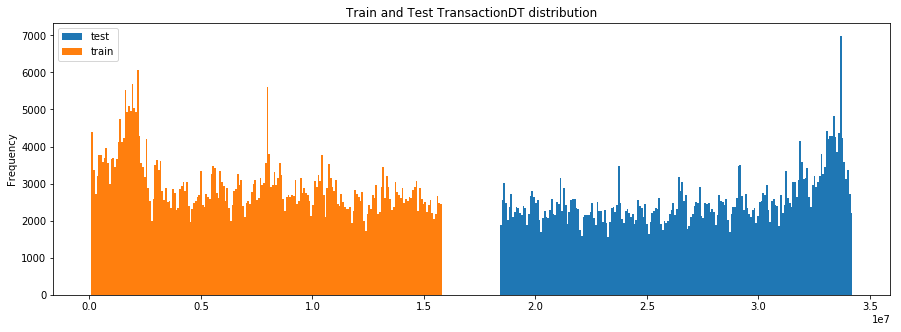

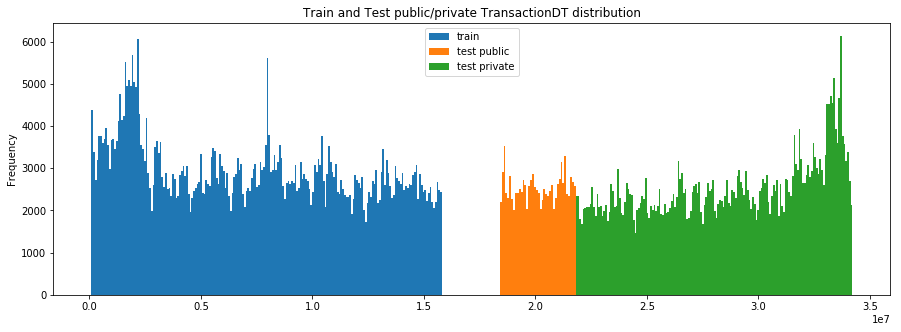

,Column,Correlation with TransactionDT
0,TransactionDT,1.000000
1,TransactionID,0.998280
2,V330,0.258603
3,V326,0.257295
4,V329,0.252599
5,V327,0.248494
375,V145,-0.252731
376,V160,-0.265566
377,V159,-0.279138
378,V151,-0.280576


In [2]:
COL = 'TransactionDT'
h('<h2 id="c_' + COL + '">' + COL + '</h2>' + '<a style="font-size:11px" href="#home">(Jump to top)</a>')

te['TransactionDT'].plot(kind='hist', figsize=(15, 5), label='test', bins=200, title='Train and Test TransactionDT distribution')
tr['TransactionDT'].plot(kind='hist', label='train', bins=200)
plt.legend()
plt.show()
tr['TransactionDT'].plot(kind='hist', figsize=(15, 5), label='train', bins=200, title='Train and Test public/private TransactionDT distribution')
n_public = int(te.shape[0] * 0.2)
te.loc[:n_public, 'TransactionDT'].plot(kind='hist', label='test public', bins=40)
te.loc[n_public:, 'TransactionDT'].plot(kind='hist', label='test private', bins=160)
plt.legend()
plt.show()
corr1(COL)

In [3]:
COL = 'isFraud'
h('<h2 id="c_' + COL + '">' + COL + '</h2>' + '<a style="font-size:11px" href="#home">(Jump to top)</a>')
h('This is target column.')
trx = tr['isFraud'].value_counts().reset_index().rename({'index':'Value','isFraud':'Count'}, axis=1)
trx['Share'] = np.round(trx['Count'] / trx['Count'].sum(), 6)
display(trx)
corr1(COL)

,Value,Count,Share
0,0,569877,0.96501
1,1,20663,0.03499


,Column,Correlation with isFraud
0,isFraud,1.000000
1,V257,0.383060
2,V246,0.366878
3,V244,0.364129
4,V242,0.360590
5,V201,0.328005
375,V90,-0.110168
376,V49,-0.110920
377,V48,-0.115786
378,D7,-0.127199


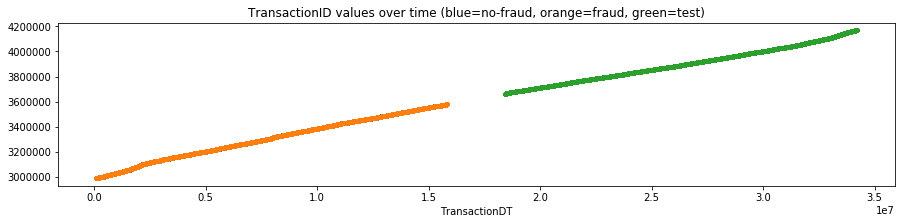

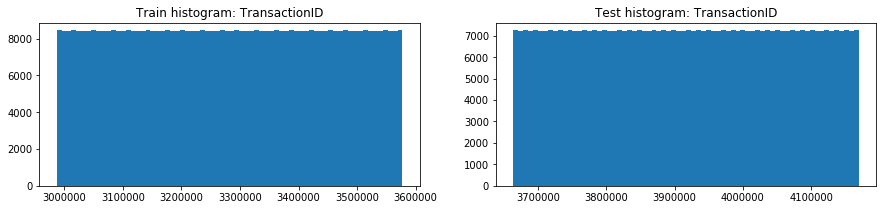

,TransactionID,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,5.905400e+05,2.066300e+04,5.698770e+05,5.066910e+05,1.013390e+05,4.053530e+05
1,mean,3.282270e+06,3.294952e+06,3.281810e+06,3.916894e+06,3.714218e+06,3.967563e+06
2,std,1.704744e+05,1.620403e+05,1.707548e+05,1.462692e+05,2.925419e+04,1.170155e+05
3,min,2.987000e+06,2.987203e+06,2.987000e+06,3.663549e+06,3.663549e+06,3.764887e+06
4,25%,3.134635e+06,3.167366e+06,3.133317e+06,3.790222e+06,3.688884e+06,3.866225e+06
5,50%,3.282270e+06,3.291934e+06,3.281808e+06,3.916894e+06,3.714218e+06,3.967563e+06
6,75%,3.429904e+06,3.428646e+06,3.429974e+06,4.043566e+06,3.739552e+06,4.068901e+06
7,max,3.577539e+06,3.577526e+06,3.577539e+06,4.170239e+06,3.764887e+06,4.170239e+06
8,unique values,5.905400e+05,2.066300e+04,5.698770e+05,5.066910e+05,1.013390e+05,4.053530e+05
9,NaNs,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


,Column,Correlation with TransactionID
0,TransactionID,1.000000
1,TransactionDT,0.998280
2,V326,0.251746
3,V330,0.250831
4,V329,0.244867
5,V327,0.242576
375,V145,-0.273548
376,V160,-0.282572
377,V159,-0.302742
378,V151,-0.303988


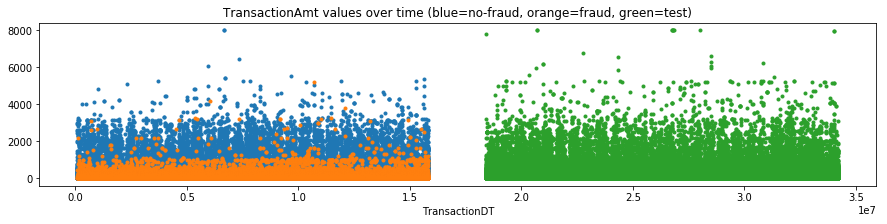

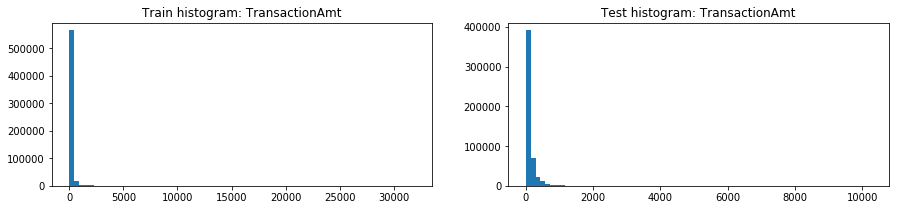

,TransactionAmt,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506691.000000,101339.000000,405353.000000
1,mean,135.027176,149.244779,134.511665,134.725568,141.732271,132.973690
2,std,239.162522,232.212163,239.395078,245.779822,257.473804,242.736757
3,min,0.251000,0.292000,0.251000,0.018000,0.018000,0.140000
4,25%,43.321000,35.044000,43.970000,40.000000,45.950000,39.000000
5,50%,68.769000,75.000000,68.500000,67.950000,72.950000,67.950000
6,75%,125.000000,161.000000,120.000000,125.000000,134.950000,120.950000
7,max,31937.391000,5191.000000,31937.391000,10270.000000,9154.460000,10270.000000
8,unique values,20902.000000,2515.000000,20560.000000,14119.000000,5144.000000,12117.000000
9,NaNs,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,TransactionAmt,Count in train (desc),Mean target,Sum target,Count in test
0,59.00,30582,0.021124,646,27365.0
1,117.00,28933,0.024851,719,25798.0
2,107.95,23954,0.009226,221,20243.0
3,57.95,23600,0.003814,90,20063.0
4,100.00,20362,0.025685,523,17565.0
5,50.00,17009,0.020754,353,14469.0
6,49.00,15990,0.029331,469,14231.0
7,226.00,11704,0.033322,390,11084.0
8,39.00,11095,0.021812,242,9926.0
9,29.00,10683,0.018815,201,9019.0


,TransactionAmt,Count in train,Mean target,Sum target (desc),Count in test
0,117.0,28933,0.024851,719,25798
1,59.0,30582,0.021124,646,27365
2,150.0,8356,0.067137,561,7426
3,100.0,20362,0.025685,523,17565
4,49.0,15990,0.029331,469,14231
5,200.0,6590,0.064188,423,6115
6,226.0,11704,0.033322,390,11084
7,300.0,2438,0.145611,355,2104
8,50.0,17009,0.020754,353,14469
9,171.0,7682,0.035407,272,7233


,Column,Correlation with TransactionAmt
0,TransactionAmt,1.000000
1,V139,0.222308
2,V140,0.207470
3,V208,0.198601
4,V161,0.197351
5,V163,0.191320
375,V15,-0.139413
376,V94,-0.141014
377,V52,-0.142297
378,V50,-0.144958


,ProductCD,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540,20663,569877,506691,101339,405353
1,unique,5,5,5,5,5,5
2,top,W,W,W,W,W,W
3,freq,439670,8969,430701,360987,82563,278425
4,unique values,5,5,5,5,5,5
5,NaNs,0,0,0,0,0,0
6,NaNs share,0,0,0,0,0,0


,ProductCD,Count in train (desc),Mean target,Sum target,Count in test
0,W,439670,0.020399,8969,360987
1,C,68519,0.116873,8008,69266
2,R,37699,0.037826,1426,35647
3,H,33024,0.047662,1574,29373
4,S,11628,0.058996,686,11418


,ProductCD,Count in train,Mean target,Sum target (desc),Count in test
0,W,439670,0.020399,8969,360987
1,C,68519,0.116873,8008,69266
2,H,33024,0.047662,1574,29373
3,R,37699,0.037826,1426,35647
4,S,11628,0.058996,686,11418


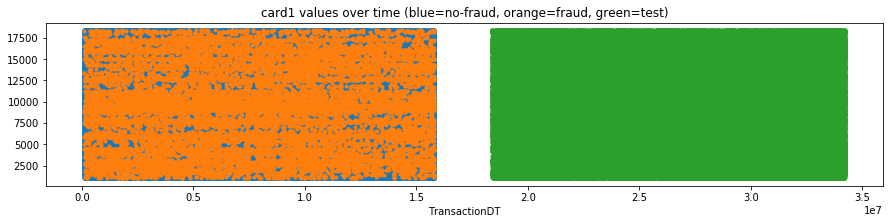

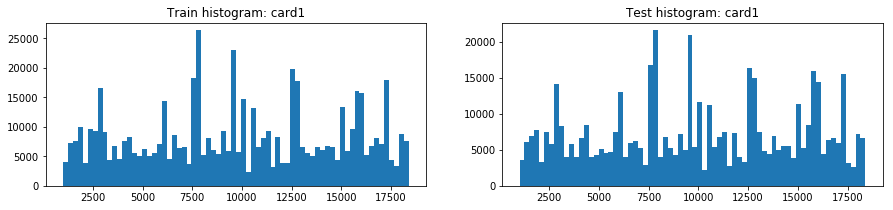

,card1,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506691.000000,101339.000000,405353.000000
1,mean,9898.734658,9547.654164,9911.464381,9957.222175,9907.330406,9969.701591
2,std,4901.170153,4762.051380,4905.672370,4884.960969,4854.917514,4892.365179
3,min,1000.000000,1015.000000,1000.000000,1001.000000,1006.000000,1001.000000
4,25%,6019.000000,5732.500000,6019.000000,6019.000000,6053.000000,6019.000000
5,50%,9678.000000,9633.000000,9711.000000,9803.000000,9653.000000,9803.000000
6,75%,14184.000000,13623.000000,14229.000000,14276.000000,14052.000000,14290.000000
7,max,18396.000000,18375.000000,18396.000000,18397.000000,18396.000000,18397.000000
8,unique values,13553.000000,1740.000000,13350.000000,13244.000000,6935.000000,12300.000000
9,NaNs,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,card1,Count in train (desc),Mean target,Sum target,Count in test
0,7919,14932,0.007501,112,13083.0
1,9500,14162,0.037283,528,12081.0
2,15885,10361,0.042853,444,12330.0
3,17188,10344,0.026875,278,9262.0
4,15066,7945,0.039396,313,6661.0
5,12695,7091,0.028346,201,5641.0
6,12544,6773,0.021556,146,5921.0
7,6019,6771,0.043420,294,6497.0
8,2803,6141,0.011887,73,4902.0
9,7585,5334,0.049306,263,4763.0


,card1,Count in train,Mean target,Sum target (desc),Count in test
0,9633,4158,0.178451,742,4751
1,9500,14162,0.037283,528,12081
2,15885,10361,0.042853,444,12330
3,9026,2076,0.191233,397,894
4,15063,2522,0.126487,319,2060
5,5812,2818,0.111427,314,3879
6,2616,4410,0.071202,314,1786
7,15066,7945,0.039396,313,6661
8,9917,919,0.332971,306,920
9,6019,6771,0.043420,294,6497


,Column,Correlation with card1
0,card1,1.000000
1,V330,0.146483
2,V329,0.142539
3,V324,0.138616
4,V333,0.136557
5,V328,0.134419
375,V149,-0.023889
376,V156,-0.024232
377,D13,-0.028603
378,D8,-0.040851


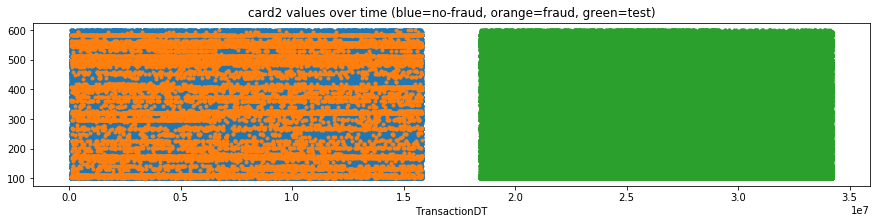

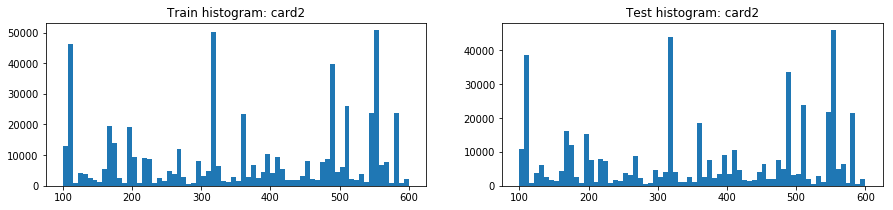

,card2,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,581607.000000,20240.000000,561367.000000,498037.000000,99008.000000,399030.000000
1,mean,362.555488,365.370850,362.453981,363.735379,358.809076,364.957595
2,std,157.793246,159.623511,157.726065,158.688653,157.772855,158.891431
3,min,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
4,25%,214.000000,204.000000,215.000000,207.000000,204.000000,214.000000
5,50%,361.000000,375.000000,361.000000,369.000000,360.000000,375.000000
6,75%,512.000000,514.000000,512.000000,512.000000,512.000000,514.000000
7,max,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
8,unique values,501.000000,328.000000,501.000000,498.000000,497.000000,497.000000
9,NaNs,8933.000000,423.000000,8510.000000,8654.000000,2331.000000,6323.000000


,card2,Count in train (desc),Mean target,Sum target,Count in test
0,321.0,48935,0.028528,1396,42796.0
1,111.0,45191,0.021641,978,37346.0
2,555.0,41995,0.022836,959,38409.0
3,490.0,38145,0.024014,916,32351.0
4,583.0,21803,0.041233,899,19700.0
5,170.0,18214,0.031295,570,15197.0
6,194.0,16938,0.007675,130,14573.0
7,545.0,16355,0.086824,1420,15539.0
8,360.0,15190,0.010402,158,11342.0
9,514.0,14541,0.046214,672,12684.0


,card2,Count in train,Mean target,Sum target (desc),Count in test
0,545.0,16355,0.086824,1420,15539
1,321.0,48935,0.028528,1396,42796
2,111.0,45191,0.021641,978,37346
3,555.0,41995,0.022836,959,38409
4,490.0,38145,0.024014,916,32351
5,500.0,5045,0.180575,911,2430
6,583.0,21803,0.041233,899,19700
7,408.0,8012,0.083999,673,9148
8,514.0,14541,0.046214,672,12684
9,130.0,2746,0.239257,657,5395


,Column,Correlation with card2
0,card2,1.000000
1,V302,0.097911
2,V304,0.096949
3,V303,0.092447
4,V50,0.084508
5,V71,0.081179
375,V36,-0.042237
376,V13,-0.043501
377,V12,-0.043553
378,V53,-0.043736


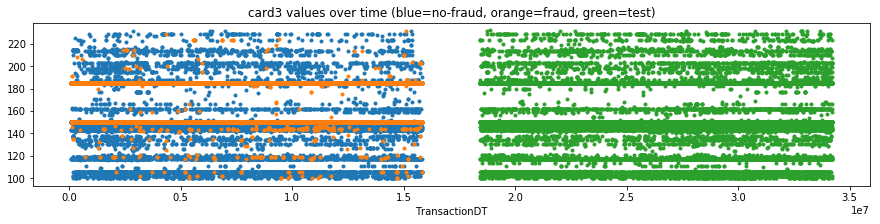

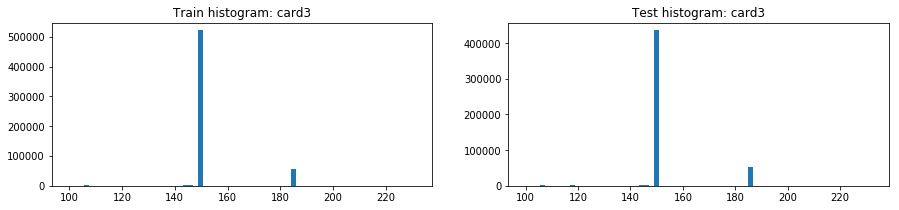

,card3,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,588975.000000,20624.000000,568351.000000,503689.000000,100033.000000,403657.000000
1,mean,153.194925,162.368648,152.862034,153.543409,152.127938,153.894177
2,std,11.336444,17.495775,10.904432,12.443013,10.591923,12.836503
3,min,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
4,25%,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
5,50%,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
6,75%,150.000000,185.000000,150.000000,150.000000,150.000000,150.000000
7,max,231.000000,231.000000,231.000000,232.000000,232.000000,231.000000
8,unique values,115.000000,63.000000,107.000000,116.000000,75.000000,111.000000
9,NaNs,1565.000000,39.000000,1526.000000,3002.000000,1306.000000,1696.000000


,card3,Count in train (desc),Mean target,Sum target,Count in test
0,150.0,521287,0.024568,12807,435558.0
1,185.0,56346,0.130657,7362,53614.0
2,106.0,1571,0.015277,24,1972.0
3,-999.0,1565,0.024920,39,3002.0
4,146.0,1252,0.019968,25,1218.0
5,144.0,1252,0.089457,112,1381.0
6,117.0,962,0.018711,18,1879.0
7,143.0,899,0.031146,28,771.0
8,119.0,750,0.093333,70,341.0
9,102.0,460,0.023913,11,738.0


,card3,Count in train,Mean target,Sum target (desc),Count in test
0,150.0,521287,0.024568,12807,435558
1,185.0,56346,0.130657,7362,53614
2,144.0,1252,0.089457,112,1381
3,119.0,750,0.093333,70,341
4,-999.0,1565,0.024920,39,3002
5,143.0,899,0.031146,28,771
6,146.0,1252,0.019968,25,1218
7,106.0,1571,0.015277,24,1972
8,117.0,962,0.018711,18,1879
9,223.0,55,0.254545,14,126


,Column,Correlation with card3
0,card3,1.000000
1,V15,0.759508
2,V94,0.758586
3,V16,0.744826
4,V57,0.744299
5,V79,0.738073
375,V53,-0.341900
376,V35,-0.348554
377,V54,-0.351214
378,V36,-0.356215


,card4,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,588963,20622,568341,503605,99996,403610
1,unique,4,4,4,4,4,4
2,top,visa,visa,visa,visa,visa,visa
3,freq,384767,13373,371394,334882,66078,268805
4,unique values,5,5,5,5,5,5
5,NaNs,1577,41,1536,3086,1343,1743
6,NaNs share,0.0027,0.002,0.0027,0.0061,0.0133,0.0043


,card4,Count in train (desc),Mean target,Sum target,Count in test
0,visa,384767,0.034756,13373,334882
1,mastercard,189217,0.034331,6496,158169
2,american express,8328,0.028698,239,7681
3,discover,6651,0.077282,514,2873
4,-999,1577,0.025999,41,3086


,card4,Count in train,Mean target,Sum target (desc),Count in test
0,visa,384767,0.034756,13373,334882
1,mastercard,189217,0.034331,6496,158169
2,discover,6651,0.077282,514,2873
3,american express,8328,0.028698,239,7681
4,-999,1577,0.025999,41,3086


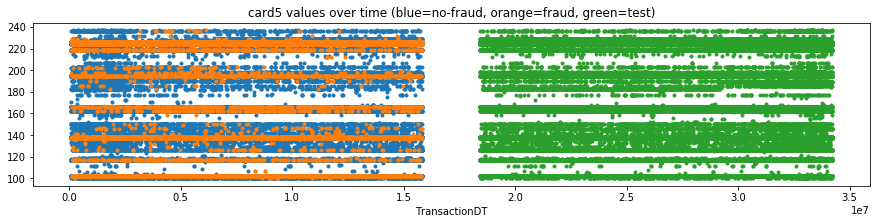

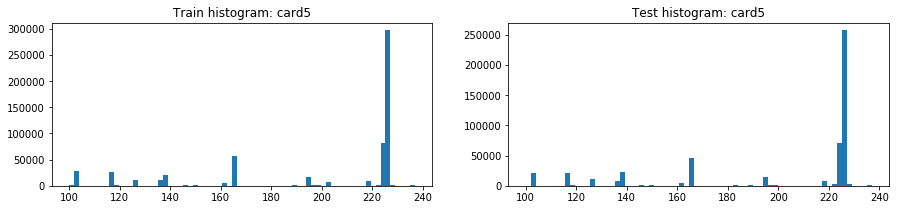

,card5,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,586281.000000,20453.000000,565828.000000,502144.000000,99816.000000,402329.000000
1,mean,199.278897,191.994328,199.542212,200.162975,200.406638,200.102588
2,std,41.244453,45.779886,41.046975,40.562461,40.584474,40.556792
3,min,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
4,25%,166.000000,138.000000,166.000000,166.000000,166.000000,166.000000
5,50%,226.000000,224.000000,226.000000,226.000000,226.000000,226.000000
6,75%,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000
7,max,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000
8,unique values,120.000000,50.000000,119.000000,103.000000,70.000000,97.000000
9,NaNs,4259.000000,210.000000,4049.000000,4547.000000,1523.000000,3024.000000


,card5,Count in train (desc),Mean target,Sum target,Count in test
0,226.0,296546,0.029516,8753,256991.0
1,224.0,81513,0.038669,3152,71596.0
2,166.0,57140,0.011026,630,45790.0
3,102.0,29105,0.062945,1832,20386.0
4,117.0,25941,0.013646,354,21120.0
5,138.0,19737,0.085221,1682,22102.0
6,195.0,16945,0.040189,681,14951.0
7,137.0,11720,0.147184,1725,7730.0
8,126.0,10298,0.010196,105,11439.0
9,219.0,9924,0.057537,571,8402.0


,card5,Count in train,Mean target,Sum target (desc),Count in test
0,226.0,296546,0.029516,8753,256991
1,224.0,81513,0.038669,3152,71596
2,102.0,29105,0.062945,1832,20386
3,137.0,11720,0.147184,1725,7730
4,138.0,19737,0.085221,1682,22102
5,195.0,16945,0.040189,681,14951
6,166.0,57140,0.011026,630,45790
7,219.0,9924,0.057537,571,8402
8,117.0,25941,0.013646,354,21120
9,162.0,4524,0.066534,301,4512


,Column,Correlation with card5
0,card5,1.000000
1,D15,0.110301
2,D1,0.099504
3,D2,0.096315
4,D4,0.095706
5,D10,0.095575
375,V333,-0.265948
376,V324,-0.268091
377,V328,-0.270129
378,V329,-0.282868


,card6,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,588969,20624,568345,503684,100033,403652
1,unique,4,2,4,3,2,3
2,top,debit,debit,debit,debit,debit,debit
3,freq,439938,10674,429264,385021,78402,306620
4,unique values,5,3,5,4,3,4
5,NaNs,1571,39,1532,3007,1306,1701
6,NaNs share,0.0027,0.0019,0.0027,0.0059,0.0129,0.0042


,card6,Count in train (desc),Mean target,Sum target,Count in test
0,debit,439938,0.024263,10674,385021.0
1,credit,148986,0.066785,9950,118662.0
2,-999,1571,0.024825,39,3007.0
3,debit or credit,30,0.000000,0,NaN
4,charge card,15,0.000000,0,1.0


,card6,Count in train,Mean target,Sum target (desc),Count in test
0,debit,439938,0.024263,10674,385021.0
1,credit,148986,0.066785,9950,118662.0
2,-999,1571,0.024825,39,3007.0
3,debit or credit,30,0.000000,0,NaN
4,charge card,15,0.000000,0,1.0


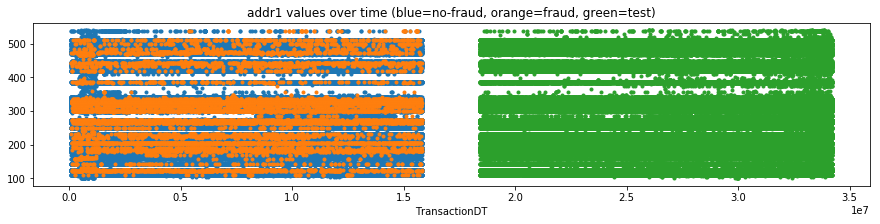

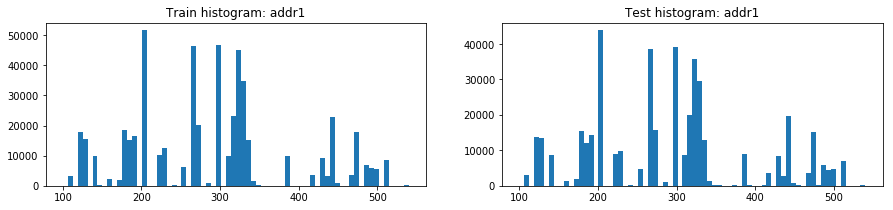

,addr1,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,524834.000000,12922.000000,511912.000000,441082.000000,91556.000000,349527.000000
1,mean,290.733794,294.317134,290.643341,291.846514,290.515029,292.194978
2,std,101.741072,103.584955,101.692564,102.062730,101.350107,102.245872
3,min,100.000000,110.000000,100.000000,100.000000,110.000000,100.000000
4,25%,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
5,50%,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
6,75%,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
7,max,540.000000,536.000000,540.000000,540.000000,536.000000,540.000000
8,unique values,333.000000,87.000000,333.000000,293.000000,83.000000,289.000000
9,NaNs,65706.000000,7741.000000,57965.000000,65609.000000,9783.000000,55826.000000


,addr1,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,65706,0.117813,7741,65609.0
1,299.0,46335,0.021258,985,38710.0
2,325.0,42751,0.025426,1087,34151.0
3,204.0,42020,0.026654,1120,35049.0
4,264.0,39870,0.018259,728,32710.0
5,330.0,26287,0.031955,840,22100.0
6,315.0,23078,0.017809,411,19957.0
7,441.0,20827,0.025592,533,18063.0
8,272.0,20141,0.028598,576,15788.0
9,123.0,16105,0.024713,398,12595.0


,addr1,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,65706,0.117813,7741,65609
1,204.0,42020,0.026654,1120,35049
2,325.0,42751,0.025426,1087,34151
3,299.0,46335,0.021258,985,38710
4,330.0,26287,0.031955,840,22100
5,264.0,39870,0.018259,728,32710
6,272.0,20141,0.028598,576,15788
7,441.0,20827,0.025592,533,18063
8,337.0,15149,0.028979,439,12932
9,315.0,23078,0.017809,411,19957


,Column,Correlation with addr1
0,addr1,1.000000
1,V326,0.050944
2,D13,0.050886
3,V327,0.047731
4,V330,0.042601
5,V329,0.042381
375,V100,-0.019761
376,V99,-0.021358
377,V287,-0.022924
378,V285,-0.028060


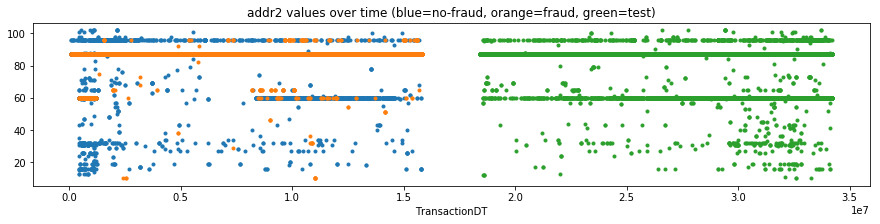

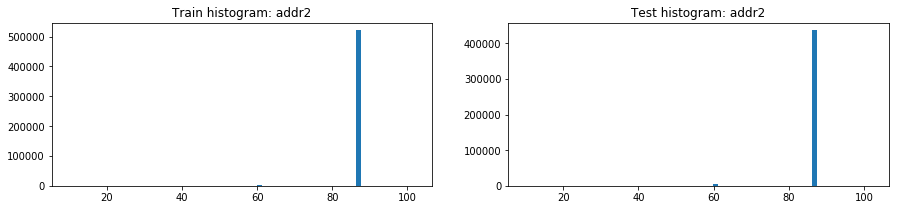

,addr2,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,524834.000000,12922.000000,511912.000000,441082.000000,91556.000000,349527.000000
1,mean,86.800630,86.286024,86.813620,86.723412,86.964372,86.660295
2,std,2.690623,4.936238,2.607742,2.987328,1.217604,3.294569
3,min,10.000000,10.000000,13.000000,10.000000,12.000000,10.000000
4,25%,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
5,50%,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
6,75%,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
7,max,102.000000,96.000000,102.000000,102.000000,96.000000,102.000000
8,unique values,75.000000,18.000000,69.000000,73.000000,18.000000,72.000000
9,NaNs,65706.000000,7741.000000,57965.000000,65609.000000,9783.000000,55826.000000


,addr2,Count in train (desc),Mean target,Sum target,Count in test
0,87.0,520481,0.023972,12477,435934.0
1,-999.0,65706,0.117813,7741,65609.0
2,60.0,3084,0.090467,279,4041.0
3,96.0,638,0.139498,89,608.0
4,32.0,91,0.065934,6,61.0
5,65.0,82,0.536585,44,49.0
6,16.0,55,0.000000,0,22.0
7,31.0,47,0.000000,0,36.0
8,19.0,33,0.000000,0,23.0
9,26.0,25,0.000000,0,7.0


,addr2,Count in train,Mean target,Sum target (desc),Count in test
0,87.0,520481,0.023972,12477,435934
1,-999.0,65706,0.117813,7741,65609
2,60.0,3084,0.090467,279,4041
3,96.0,638,0.139498,89,608
4,65.0,82,0.536585,44,49
5,10.0,8,1.000000,8,3
6,32.0,91,0.065934,6,61
7,51.0,4,1.000000,4,1
8,46.0,3,1.000000,3,1
9,54.0,6,0.333333,2,10


,Column,Correlation with addr2
0,addr2,1.000000
1,D6,0.290653
2,D13,0.208817
3,D14,0.142099
4,V36,0.113776
5,V35,0.110642
375,V16,-0.712508
376,V15,-0.819340
377,V58,-0.876798
378,V57,-0.876965


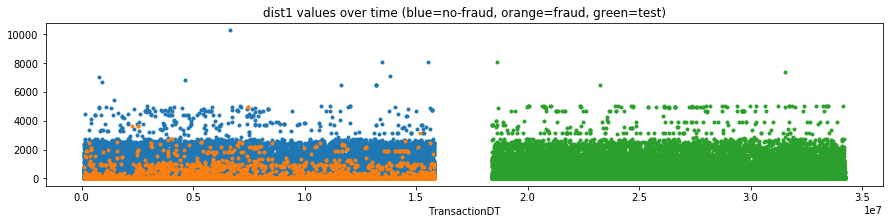

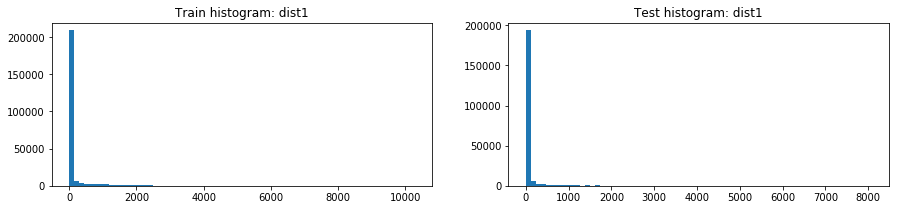

,dist1,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,238269.000000,4755.000000,233514.000000,215474.000000,47587.000000,167888.000000
1,mean,118.502180,174.588854,117.360098,87.065270,92.930464,85.404353
2,std,371.872026,424.232313,370.641879,314.131694,332.382991,308.742753
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
5,50%,8.000000,10.000000,8.000000,8.000000,8.000000,8.000000
6,75%,24.000000,85.500000,24.000000,20.000000,20.000000,20.000000
7,max,10286.000000,4942.000000,10286.000000,8081.000000,8081.000000,7385.000000
8,unique values,2652.000000,471.000000,2636.000000,1989.000000,1347.000000,1843.000000
9,NaNs,352271.000000,15908.000000,336363.000000,291217.000000,53752.000000,237465.000000


,dist1,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,352271,0.045158,15908,291217.0
1,0.0,19824,0.019169,380,19278.0
2,1.0,18330,0.027932,512,18025.0
3,2.0,17028,0.011745,200,15687.0
4,4.0,13067,0.016454,215,12137.0
5,3.0,12808,0.011711,150,12333.0
6,5.0,12004,0.022243,267,11238.0
7,6.0,9843,0.014630,144,8775.0
8,7.0,9340,0.014668,137,9210.0
9,8.0,7731,0.015134,117,7333.0


,dist1,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,352271,0.045158,15908,291217
1,1.0,18330,0.027932,512,18025
2,0.0,19824,0.019169,380,19278
3,5.0,12004,0.022243,267,11238
4,4.0,13067,0.016454,215,12137
5,2.0,17028,0.011745,200,15687
6,3.0,12808,0.011711,150,12333
7,9.0,7728,0.018892,146,7608
8,6.0,9843,0.014630,144,8775
9,7.0,9340,0.014668,137,9210


,Column,Correlation with dist1
0,dist1,1.000000
1,V8,0.094938
2,V9,0.088465
3,V2,0.079191
4,V6,0.076624
5,V3,0.067514
166,V91,-0.066577
167,V70,-0.066690
168,V90,-0.068074
169,V69,-0.068412


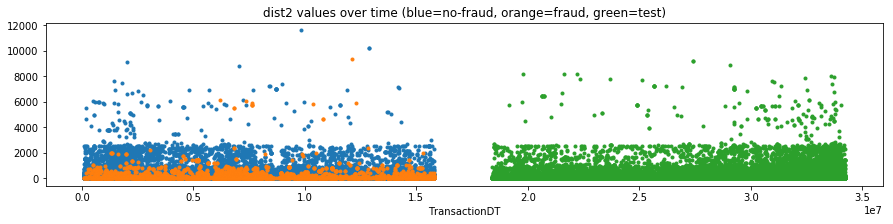

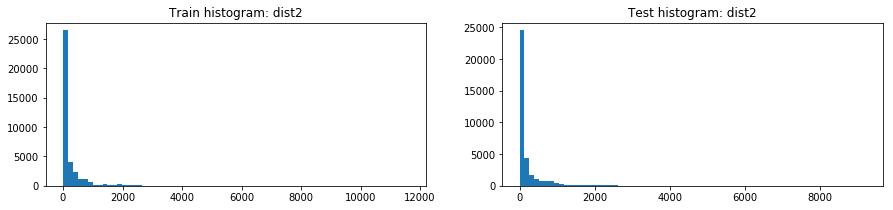

,dist2,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,37627.000000,3731.000000,33896.000000,36436.000000,4716.000000,31720.000000
1,mean,231.855423,201.472259,235.199758,237.175047,233.553223,237.713525
2,std,529.053494,451.589576,536.798492,556.450834,555.365698,556.618714
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
5,50%,37.000000,49.000000,36.000000,44.000000,50.000000,42.000000
6,75%,206.000000,233.000000,206.000000,196.000000,190.000000,196.000000
7,max,11623.000000,9337.000000,11623.000000,9213.000000,8169.000000,9213.000000
8,unique values,1752.000000,345.000000,1724.000000,1815.000000,611.000000,1730.000000
9,NaNs,552913.000000,16932.000000,535981.000000,470255.000000,96623.000000,373633.000000


,dist2,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,552913,0.030623,16932,470255.0
1,7.0,5687,0.087216,496,2660.0
2,0.0,3519,0.153453,540,2821.0
3,1.0,1374,0.139738,192,1565.0
4,9.0,742,0.148248,110,993.0
5,4.0,659,0.071320,47,557.0
6,2.0,556,0.035971,20,805.0
7,3.0,490,0.077551,38,606.0
8,68.0,485,0.096907,47,342.0
9,6.0,412,0.024272,10,497.0


,dist2,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,552913,0.030623,16932,470255
1,0.0,3519,0.153453,540,2821
2,7.0,5687,0.087216,496,2660
3,1.0,1374,0.139738,192,1565
4,9.0,742,0.148248,110,993
5,17.0,257,0.276265,71,367
6,199.0,362,0.193370,70,138
7,49.0,110,0.509091,56,74
8,478.0,102,0.539216,55,25
9,150.0,215,0.237209,51,43


,Column,Correlation with dist2
0,dist2,1.000000
1,V192,0.102090
2,V187,0.094572
3,V193,0.091043
4,V234,0.076003
5,V191,0.066564
342,V260,-0.044111
343,D6,-0.045920
344,D4,-0.058390
345,D12,-0.075249


,P_emaildomain,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,496084,17873,478211,437499,85891,351609
1,unique,59,42,59,60,59,60
2,top,gmail.com,gmail.com,gmail.com,gmail.com,gmail.com,gmail.com
3,freq,228355,9943,218412,207448,41104,166345
4,unique values,60,43,60,61,60,61
5,NaNs,94456,2790,91666,69192,15448,53744
6,NaNs share,0.1599,0.135,0.1609,0.1366,0.1524,0.1326


,P_emaildomain,Count in train (desc),Mean target,Sum target,Count in test
0,gmail.com,228355,0.043542,9943,207448
1,yahoo.com,100934,0.022757,2297,81850
2,-999,94456,0.029538,2790,69192
3,hotmail.com,45250,0.052950,2396,40399
4,anonymous.com,36998,0.023217,859,34064
5,aol.com,28289,0.021811,617,24048
6,comcast.net,7888,0.031187,246,6586
7,icloud.com,6267,0.031434,197,6049
8,outlook.com,5096,0.094584,482,4838
9,msn.com,4092,0.021994,90,3388


,P_emaildomain,Count in train,Mean target,Sum target (desc),Count in test
0,gmail.com,228355,0.043542,9943,207448
1,-999,94456,0.029538,2790,69192
2,hotmail.com,45250,0.052950,2396,40399
3,yahoo.com,100934,0.022757,2297,81850
4,anonymous.com,36998,0.023217,859,34064
5,aol.com,28289,0.021811,617,24048
6,outlook.com,5096,0.094584,482,4838
7,comcast.net,7888,0.031187,246,6586
8,icloud.com,6267,0.031434,197,6049
9,mail.com,559,0.189624,106,597


,R_emaildomain,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,137291,11227,126064,135870,18223,117647
1,unique,60,32,60,60,57,60
2,top,gmail.com,gmail.com,gmail.com,gmail.com,gmail.com,gmail.com
3,freq,57147,6811,50336,61738,8588,53150
4,unique values,61,33,61,61,58,61
5,NaNs,453249,9436,443813,370821,83116,287706
6,NaNs share,0.7675,0.4567,0.7788,0.7318,0.8202,0.7098


,R_emaildomain,Count in train (desc),Mean target,Sum target,Count in test
0,-999,453249,0.020819,9436,370821
1,gmail.com,57147,0.119184,6811,61738
2,hotmail.com,27509,0.077793,2140,25657
3,anonymous.com,20529,0.029130,598,19115
4,yahoo.com,11842,0.051512,610,9563
5,aol.com,3701,0.034855,129,3538
6,outlook.com,2507,0.165138,414,2504
7,comcast.net,1812,0.011589,21,1701
8,yahoo.com.mx,1508,0.010610,16,1235
9,icloud.com,1398,0.128755,180,1422


,R_emaildomain,Count in train,Mean target,Sum target (desc),Count in test
0,-999,453249,0.020819,9436,370821
1,gmail.com,57147,0.119184,6811,61738
2,hotmail.com,27509,0.077793,2140,25657
3,yahoo.com,11842,0.051512,610,9563
4,anonymous.com,20529,0.029130,598,19115
5,outlook.com,2507,0.165138,414,2504
6,icloud.com,1398,0.128755,180,1422
7,aol.com,3701,0.034855,129,3538
8,outlook.es,433,0.131640,57,420
9,mail.com,122,0.377049,46,219


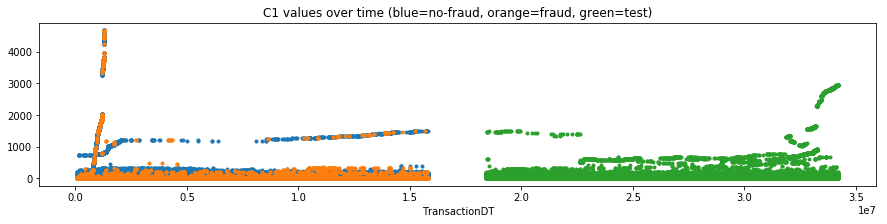

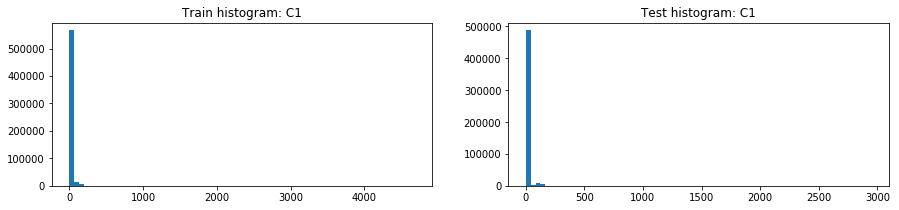

,C1,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.00000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,14.092458,35.53574,13.314952,10.093211,8.408707,10.514326
2,std,133.569018,242.97626,127.787969,79.334782,40.872210,86.307573
3,min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,2.00000,1.000000,1.000000,2.000000,1.000000
6,75%,3.000000,6.00000,3.000000,3.000000,3.000000,3.000000
7,max,4685.000000,4682.00000,4685.000000,2950.000000,1501.000000,2950.000000
8,unique values,1657.000000,497.00000,1526.000000,1175.000000,344.000000,1118.000000
9,NaNs,0.000000,0.00000,0.000000,3.000000,0.000000,3.000000


,C1,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,316791,0.024230,7676,269951.0
1,2.0,105071,0.030284,3182,92449.0
2,3.0,51315,0.035876,1841,45254.0
3,4.0,28845,0.040596,1171,24949.0
4,5.0,17922,0.054179,971,14929.0
5,6.0,10567,0.053658,567,9207.0
6,7.0,7263,0.058240,423,5721.0
7,8.0,5072,0.066246,336,3996.0
8,9.0,3612,0.080011,289,2771.0
9,10.0,2904,0.091942,267,1969.0


,C1,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,316791,0.024230,7676,269951
1,2.0,105071,0.030284,3182,92449
2,3.0,51315,0.035876,1841,45254
3,4.0,28845,0.040596,1171,24949
4,5.0,17922,0.054179,971,14929
5,6.0,10567,0.053658,567,9207
6,7.0,7263,0.058240,423,5721
7,8.0,5072,0.066246,336,3996
8,9.0,3612,0.080011,289,2771
9,10.0,2904,0.091942,267,1969


,Column,Correlation with C1
0,C1,1.000000
1,C11,0.996515
2,C2,0.995089
3,C6,0.982238
4,C4,0.967800
5,C8,0.967746
375,V75,-0.051347
376,V76,-0.051632
377,TransactionID,-0.053154
378,V35,-0.054029


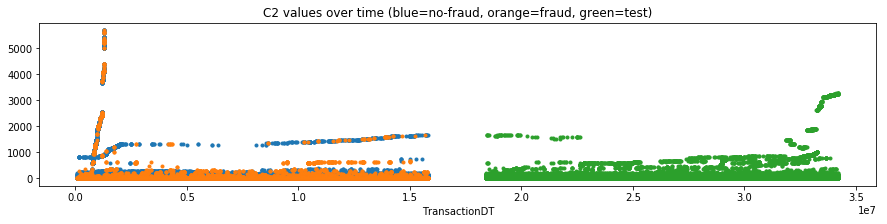

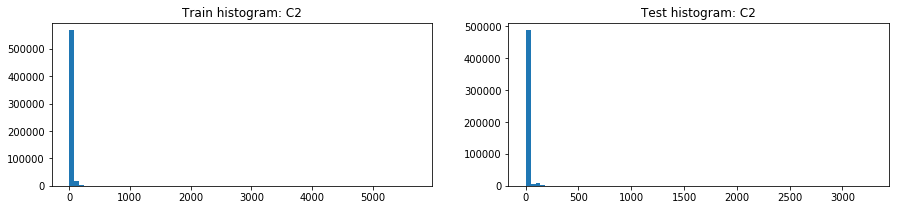

,C2,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,15.269734,45.509413,14.173283,10.714635,8.606923,11.241549
2,std,154.668899,287.813648,147.485925,88.896921,44.375338,96.874447
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000
6,75%,3.000000,7.000000,3.000000,3.000000,3.000000,3.000000
7,max,5691.000000,5690.000000,5691.000000,3275.000000,1672.000000,3275.000000
8,unique values,1216.000000,544.000000,1075.000000,1124.000000,370.000000,1054.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C2,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,316261,0.023073,7297,265435.0
1,2.0,103948,0.031978,3324,93084.0
2,3.0,51770,0.036160,1872,44267.0
3,4.0,28251,0.050370,1423,24329.0
4,5.0,16971,0.049496,840,14711.0
5,6.0,10682,0.049991,534,9662.0
6,7.0,7382,0.060824,449,6097.0
7,8.0,5105,0.053477,273,4387.0
8,9.0,3750,0.058933,221,3364.0
9,10.0,2797,0.085449,239,2432.0


,C2,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,316261,0.023073,7297,265435
1,2.0,103948,0.031978,3324,93084
2,3.0,51770,0.036160,1872,44267
3,4.0,28251,0.050370,1423,24329
4,5.0,16971,0.049496,840,14711
5,6.0,10682,0.049991,534,9662
6,7.0,7382,0.060824,449,6097
7,8.0,5105,0.053477,273,4387
8,10.0,2797,0.085449,239,2432
9,9.0,3750,0.058933,221,3364


,Column,Correlation with C2
0,C2,1.000000
1,C1,0.995089
2,C11,0.993898
3,C8,0.975863
4,C6,0.974845
5,C4,0.972134
375,TransactionID,-0.055186
376,V75,-0.056251
377,V76,-0.056896
378,V35,-0.059538


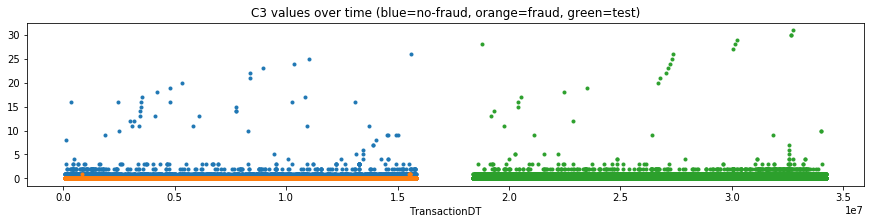

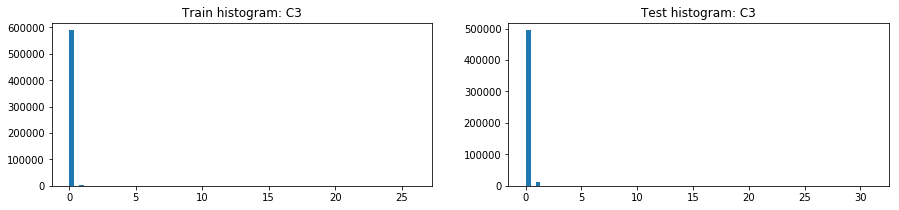

,C3,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,0.005644,0.000242,0.005840,0.027403,0.009365,0.031913
2,std,0.150536,0.015554,0.153208,0.227753,0.176030,0.238727
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,max,26.000000,1.000000,26.000000,31.000000,28.000000,31.000000
8,unique values,27.000000,2.000000,27.000000,32.000000,14.000000,26.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C3,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,588111,0.035126,20658,493779.0
1,1.0,2137,0.002340,5,12506.0
2,2.0,180,0.000000,0,320.0
3,3.0,58,0.000000,0,37.0
4,4.0,7,0.000000,0,11.0
5,16.0,6,0.000000,0,1.0
6,9.0,5,0.000000,0,3.0
7,11.0,5,0.000000,0,1.0
8,14.0,3,0.000000,0,1.0
9,13.0,3,0.000000,0,1.0


,C3,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,588111,0.035126,20658,493779
1,1.0,2137,0.002340,5,12506
2,15.0,2,0.000000,0,1
3,6.0,1,0.000000,0,1
4,19.0,1,0.000000,0,1
5,20.0,1,0.000000,0,1
6,21.0,1,0.000000,0,1
7,18.0,1,0.000000,0,1
8,23.0,1,0.000000,0,1
9,24.0,1,0.000000,0,1


,Column,Correlation with C3
0,C3,1.000000
1,V28,0.593655
2,V89,0.592326
3,V68,0.554881
4,V27,0.548193
5,D6,0.090308
361,V155,-0.039395
362,V82,-0.040171
363,V148,-0.040378
364,V154,-0.041643


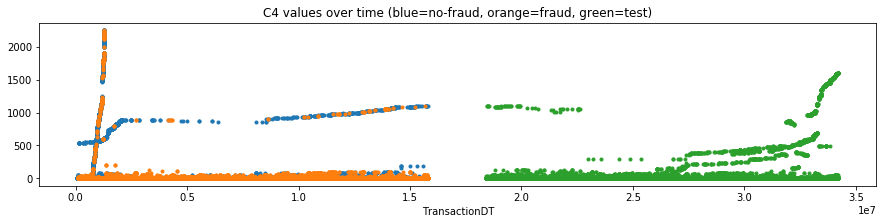

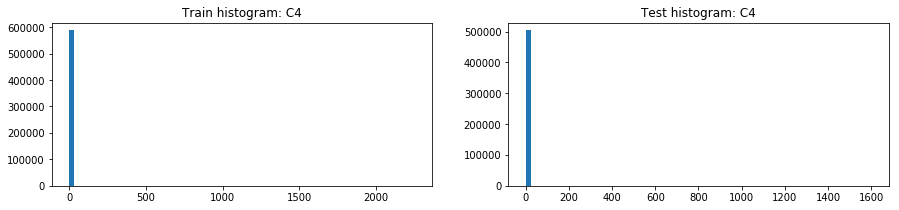

,C4,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,4.092185,15.077336,3.693878,2.385875,0.985040,2.736082
2,std,68.848459,125.673738,65.839255,41.942977,23.116076,45.440263
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000
7,max,2253.000000,2251.000000,2253.000000,1601.000000,1100.000000,1601.000000
8,unique values,1260.000000,224.000000,1180.000000,729.000000,99.000000,698.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C4,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,451883,0.020386,9212,371571.0
1,1.0,111817,0.051298,5736,107826.0
2,2.0,12994,0.128444,1669,13702.0
3,3.0,4949,0.144070,713,4307.0
4,4.0,1902,0.305468,581,1759.0
5,5.0,851,0.404230,344,1159.0
6,6.0,597,0.402010,240,713.0
7,7.0,372,0.325269,121,482.0
8,9.0,273,0.545788,149,298.0
9,10.0,233,0.682403,159,305.0


,C4,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,451883,0.020386,9212,371571
1,1.0,111817,0.051298,5736,107826
2,2.0,12994,0.128444,1669,13702
3,3.0,4949,0.144070,713,4307
4,4.0,1902,0.305468,581,1759
5,5.0,851,0.404230,344,1159
6,6.0,597,0.402010,240,713
7,10.0,233,0.682403,159,305
8,9.0,273,0.545788,149,298
9,7.0,372,0.325269,121,482


,Column,Correlation with C4
0,C4,1.000000
1,C11,0.974547
2,C2,0.972134
3,C1,0.967800
4,C6,0.962319
5,C8,0.959995
362,V54,-0.057470
363,V197,-0.058750
364,V35,-0.058768
365,V36,-0.060052


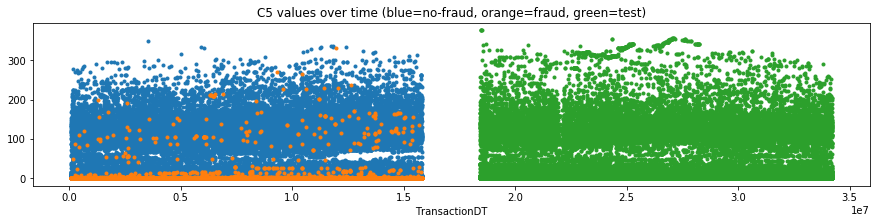

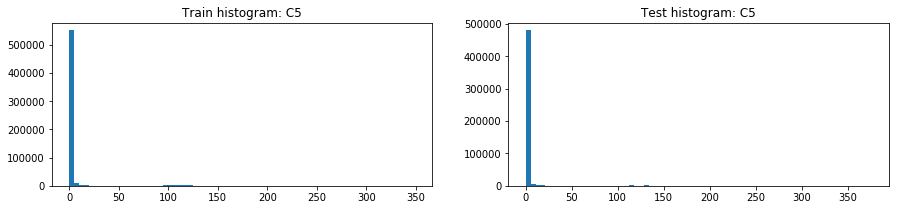

,C5,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,5.571526,1.406717,5.722537,4.962701,5.711493,4.775493
2,std,25.786976,12.946092,26.121841,25.462195,26.488371,25.195644
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,349.000000,331.000000,349.000000,376.000000,376.000000,355.000000
8,unique values,319.000000,124.000000,319.000000,354.000000,300.000000,353.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C5,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,372435,0.050369,18759,334573
1,1.0,122883,0.007560,929,96588
2,2.0,34776,0.010956,381,29363
3,3.0,13189,0.011980,158,10699
4,4.0,6828,0.006591,45,5446
5,5.0,3763,0.004252,16,2832
6,6.0,2837,0.004230,12,1938
7,7.0,1906,0.003673,7,1369
8,8.0,1443,0.009009,13,991
9,9.0,1076,0.009294,10,905


,C5,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,372435,0.050369,18759,334573
1,1.0,122883,0.007560,929,96588
2,2.0,34776,0.010956,381,29363
3,3.0,13189,0.011980,158,10699
4,4.0,6828,0.006591,45,5446
5,26.0,203,0.113300,23,119
6,14.0,420,0.054762,23,450
7,13.0,583,0.029160,17,546
8,5.0,3763,0.004252,16,2832
9,8.0,1443,0.009009,13,991


,Column,Correlation with C5
0,C5,1.000000
1,C9,0.925786
2,C13,0.717509
3,C14,0.378950
4,V70,0.284101
5,V49,0.279314
208,V51,-0.095805
209,V303,-0.098097
210,V50,-0.100054
211,V304,-0.108065


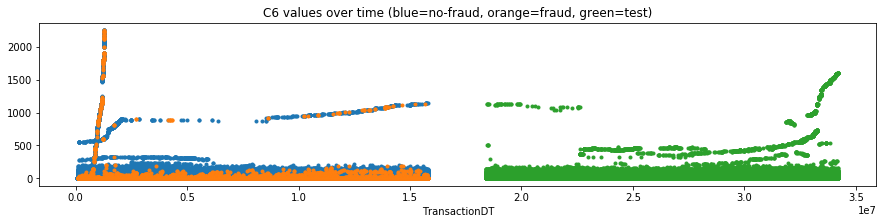

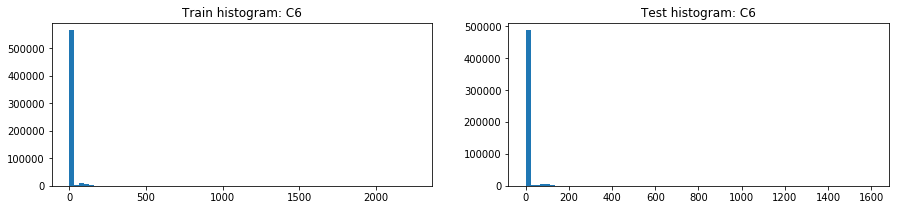

,C6,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,9.071082,16.923148,8.786377,6.854992,5.905969,7.092244
2,std,71.508467,126.298758,68.689176,46.783565,29.791262,50.136998
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000
7,max,2253.000000,2251.000000,2253.000000,1601.000000,1138.000000,1601.000000
8,unique values,1328.000000,282.000000,1270.000000,835.000000,201.000000,820.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C6,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,341552,0.027764,9483,289685.0
1,2.0,86103,0.037850,3259,75316.0
2,0.0,49066,0.031305,1536,45707.0
3,3.0,35490,0.042575,1511,31815.0
4,4.0,17805,0.053300,949,16420.0
5,5.0,10187,0.059880,610,8914.0
6,6.0,6048,0.078042,472,5293.0
7,7.0,3934,0.054652,215,3366.0
8,8.0,3048,0.057415,175,2105.0
9,9.0,2335,0.098073,229,1563.0


,C6,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,341552,0.027764,9483,289685
1,2.0,86103,0.037850,3259,75316
2,0.0,49066,0.031305,1536,45707
3,3.0,35490,0.042575,1511,31815
4,4.0,17805,0.053300,949,16420
5,5.0,10187,0.059880,610,8914
6,6.0,6048,0.078042,472,5293
7,10.0,1817,0.128233,233,1267
8,9.0,2335,0.098073,229,1563
9,7.0,3934,0.054652,215,3366


,Column,Correlation with C6
0,C6,1.000000
1,C11,0.991105
2,C14,0.984201
3,C1,0.982238
4,C2,0.974845
5,C4,0.962319
375,V75,-0.050655
376,V35,-0.052205
377,V36,-0.052338
378,V197,-0.058367


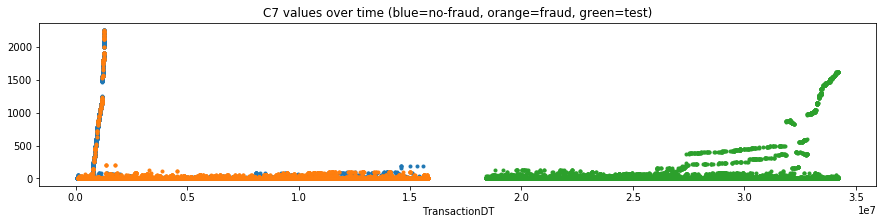

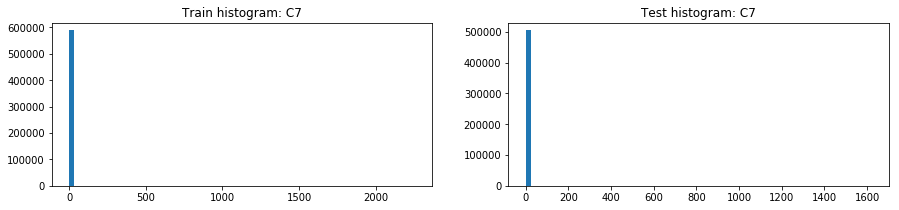

,C7,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,2.848478,11.977157,2.517484,1.678173,0.377999,2.003217
2,std,61.727304,115.143177,58.860773,37.874827,3.769156,42.297173
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,2255.000000,2253.000000,2255.000000,1621.000000,130.000000,1621.000000
8,unique values,1103.000000,197.000000,1018.000000,519.000000,74.000000,512.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C7,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,523142,0.024376,12752,438095.0
1,1.0,51966,0.067294,3497,50141.0
2,2.0,7314,0.141509,1035,8712.0
3,3.0,2033,0.232661,473,2734.0
4,4.0,1109,0.431019,478,1344.0
5,5.0,481,0.580042,279,691.0
6,6.0,409,0.491443,201,478.0
7,7.0,267,0.441948,118,369.0
8,9.0,233,0.626609,146,216.0
9,10.0,175,0.782857,137,199.0


,C7,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,523142,0.024376,12752,438095
1,1.0,51966,0.067294,3497,50141
2,2.0,7314,0.141509,1035,8712
3,4.0,1109,0.431019,478,1344
4,3.0,2033,0.232661,473,2734
5,5.0,481,0.580042,279,691
6,6.0,409,0.491443,201,478
7,9.0,233,0.626609,146,216
8,10.0,175,0.782857,137,199
9,7.0,267,0.441948,118,369


,Column,Correlation with C7
0,C7,1.000000
1,C12,0.999489
2,C10,0.985062
3,C8,0.982983
4,C2,0.938867
5,C1,0.926258
315,V54,-0.056192
316,V35,-0.056947
317,V36,-0.058191
318,TransactionID,-0.059485


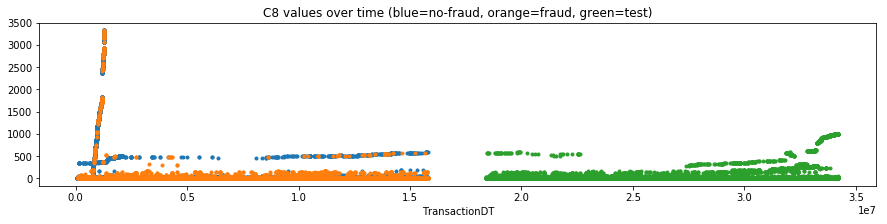

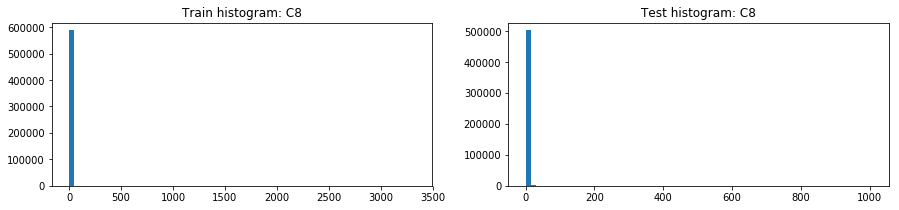

,C8,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,5.144574,21.242608,4.560881,1.893994,1.030146,2.109954
2,std,95.378574,176.695771,91.023016,26.766115,13.587585,29.140063
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000
7,max,3331.000000,3328.000000,3331.000000,1005.000000,584.000000,1005.000000
8,unique values,1253.000000,311.000000,1115.000000,443.000000,120.000000,422.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C8,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,447667,0.020899,9356,368637.0
1,1.0,104994,0.044393,4661,97332.0
2,2.0,15927,0.097633,1555,18261.0
3,3.0,5493,0.137266,754,6801.0
4,4.0,2817,0.182464,514,3172.0
5,8.0,1790,0.112849,202,810.0
6,6.0,1774,0.204059,362,1386.0
7,5.0,1721,0.222545,383,2035.0
8,7.0,988,0.237854,235,1015.0
9,9.0,718,0.307799,221,660.0


,C8,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,447667,0.020899,9356,368637
1,1.0,104994,0.044393,4661,97332
2,2.0,15927,0.097633,1555,18261
3,3.0,5493,0.137266,754,6801
4,4.0,2817,0.182464,514,3172
5,5.0,1721,0.222545,383,2035
6,6.0,1774,0.204059,362,1386
7,7.0,988,0.237854,235,1015
8,9.0,718,0.307799,221,660
9,8.0,1790,0.112849,202,810


,Column,Correlation with C8
0,C8,1.000000
1,C10,0.996970
2,C12,0.983027
3,C7,0.982983
4,C2,0.975863
5,C1,0.967746
362,V54,-0.056765
363,V35,-0.057420
364,V36,-0.058675
365,addr2,-0.059482


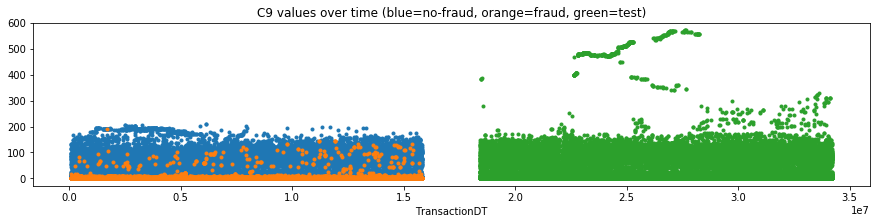

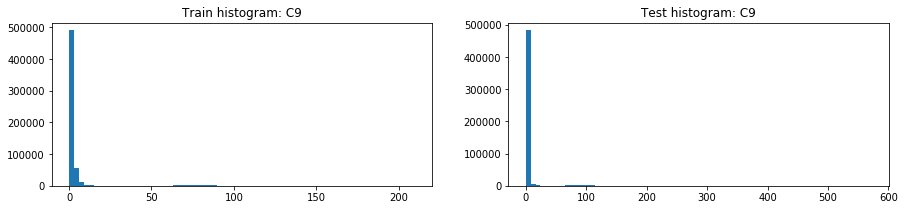

,C9,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,4.480240,1.703964,4.580904,4.611943,5.117645,4.485509
2,std,16.674897,8.453280,16.889451,21.282640,18.153293,21.993710
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000
7,max,210.000000,192.000000,210.000000,572.000000,386.000000,572.000000
8,unique values,205.000000,111.000000,205.000000,355.000000,175.000000,352.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C9,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,228938,0.019062,4364,191416.0
1,0.0,183795,0.066683,12256,157766.0
2,2.0,77829,0.021663,1686,68814.0
3,3.0,32505,0.026211,852,31510.0
4,4.0,16196,0.019820,321,15476.0
5,5.0,8648,0.034806,301,7835.0
6,6.0,5760,0.029514,170,4910.0
7,7.0,3529,0.026636,94,2970.0
8,8.0,2548,0.029827,76,2164.0
9,9.0,1871,0.078033,146,1480.0


,C9,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,183795,0.066683,12256,157766
1,1.0,228938,0.019062,4364,191416
2,2.0,77829,0.021663,1686,68814
3,3.0,32505,0.026211,852,31510
4,4.0,16196,0.019820,321,15476
5,5.0,8648,0.034806,301,7835
6,6.0,5760,0.029514,170,4910
7,9.0,1871,0.078033,146,1480
8,7.0,3529,0.026636,94,2970
9,8.0,2548,0.029827,76,2164


,Column,Correlation with C9
0,C9,1.000000
1,C5,0.925786
2,C13,0.704056
3,C14,0.397396
4,V70,0.266079
5,V49,0.264768
208,V51,-0.117889
209,V303,-0.121989
210,V50,-0.124945
211,V304,-0.134387


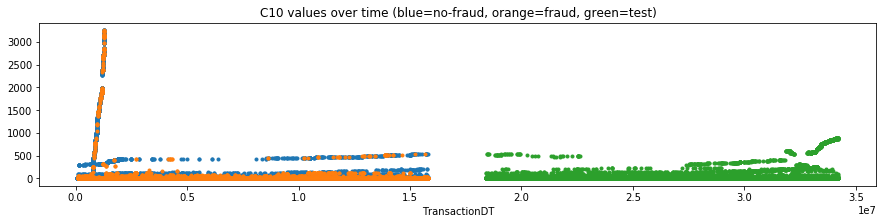

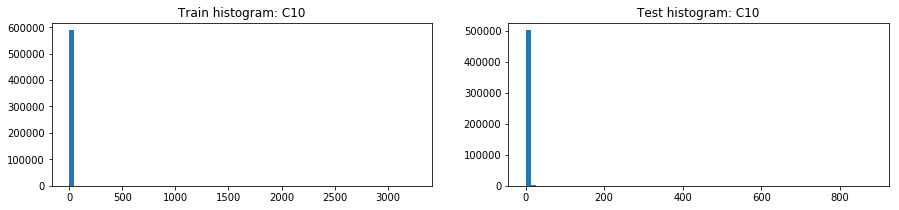

,C10,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,5.240343,19.493926,4.723526,1.810149,0.869409,2.045334
2,std,95.581443,176.919186,91.239098,23.692393,11.906035,25.805962
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000
7,max,3257.000000,3254.000000,3257.000000,881.000000,530.000000,881.000000
8,unique values,1231.000000,234.000000,1163.000000,457.000000,111.000000,439.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C10,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,453442,0.021273,9646,370978.0
1,1.0,100231,0.046303,4641,92343.0
2,2.0,14938,0.109452,1635,17752.0
3,3.0,6417,0.134175,861,6869.0
4,4.0,2836,0.197461,560,4002.0
5,5.0,1806,0.209856,379,2550.0
6,6.0,1286,0.209176,269,1858.0
7,7.0,817,0.250918,205,1235.0
8,8.0,627,0.280702,176,999.0
9,9.0,553,0.227848,126,782.0


,C10,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,453442,0.021273,9646,370978
1,1.0,100231,0.046303,4641,92343
2,2.0,14938,0.109452,1635,17752
3,3.0,6417,0.134175,861,6869
4,4.0,2836,0.197461,560,4002
5,5.0,1806,0.209856,379,2550
6,6.0,1286,0.209176,269,1858
7,7.0,817,0.250918,205,1235
8,8.0,627,0.280702,176,999
9,10.0,420,0.373810,157,705


,Column,Correlation with C10
0,C10,1.000000
1,C8,0.996970
2,C7,0.985062
3,C12,0.983817
4,C2,0.970624
5,C1,0.958202
362,TransactionDT,-0.057734
363,V35,-0.058026
364,V36,-0.059294
365,TransactionID,-0.062073


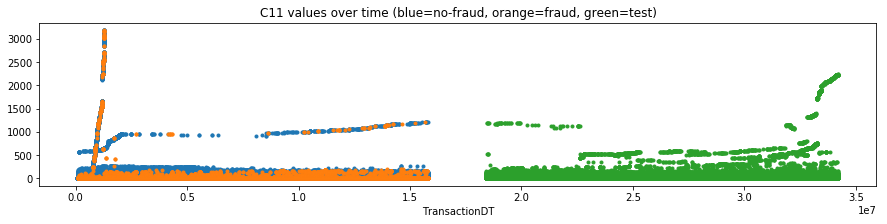

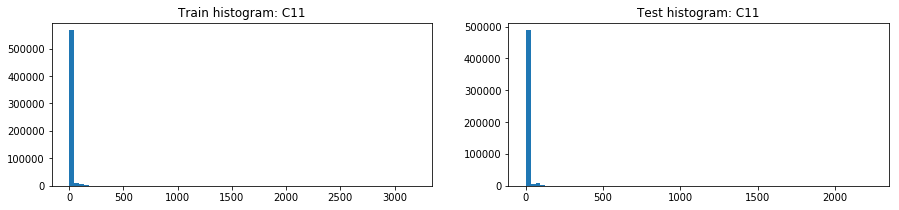

,C11,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,10.241521,23.857475,9.747825,7.484594,6.042649,7.845072
2,std,94.336292,170.966234,90.306569,61.322505,31.477895,66.724831
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
6,75%,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000
7,max,3188.000000,3186.000000,3188.000000,2234.000000,1196.000000,2234.000000
8,unique values,1476.000000,330.000000,1400.000000,938.000000,246.000000,913.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C11,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,389692,0.025346,9877,342100.0
1,2.0,89677,0.040378,3621,79103.0
2,3.0,34463,0.047181,1626,27179.0
3,4.0,16051,0.062675,1006,12427.0
4,5.0,9972,0.061472,613,6394.0
5,6.0,5966,0.070734,422,3686.0
6,7.0,3663,0.068523,251,2466.0
7,8.0,2892,0.079876,231,1799.0
8,0.0,1864,0.068133,127,4909.0
9,9.0,1805,0.077008,139,1147.0


,C11,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,389692,0.025346,9877,342100
1,2.0,89677,0.040378,3621,79103
2,3.0,34463,0.047181,1626,27179
3,4.0,16051,0.062675,1006,12427
4,5.0,9972,0.061472,613,6394
5,6.0,5966,0.070734,422,3686
6,7.0,3663,0.068523,251,2466
7,8.0,2892,0.079876,231,1799
8,10.0,1634,0.091187,149,934
9,9.0,1805,0.077008,139,1147


,Column,Correlation with C11
0,C11,1.000000
1,C1,0.996515
2,C2,0.993898
3,C6,0.991105
4,C4,0.974547
5,C8,0.962722
375,V76,-0.052040
376,TransactionID,-0.054122
377,V35,-0.054781
378,V36,-0.055351


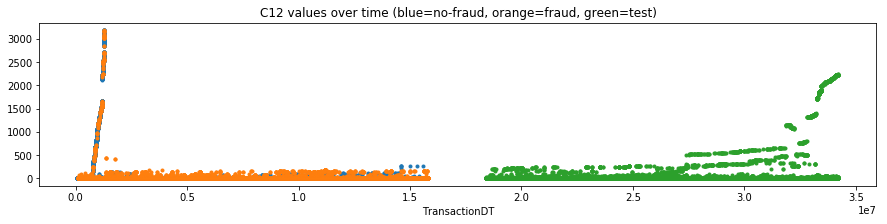

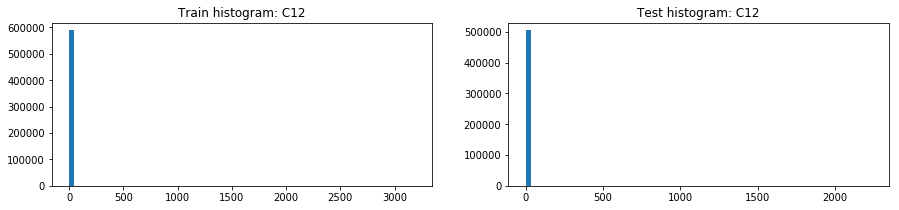

,C12,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.00000
1,mean,4.076227,18.597541,3.549703,2.649486,0.870711,3.09418
2,std,86.666218,162.082460,82.601169,53.973060,9.524789,60.14732
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
6,75%,0.000000,2.000000,0.000000,1.000000,0.000000,1.00000
7,max,3188.000000,3186.000000,3188.000000,2234.000000,240.000000,2234.00000
8,unique values,1199.000000,282.000000,1050.000000,664.000000,129.000000,628.00000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.00000


,C12,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,489199,0.022897,11201,366881.0
1,1.0,76661,0.053339,4089,108347.0
2,2.0,12242,0.106437,1303,17804.0
3,3.0,4185,0.163441,684,4980.0
4,4.0,1716,0.245921,422,2064.0
5,5.0,1085,0.268203,291,997.0
6,6.0,629,0.352941,222,876.0
7,7.0,393,0.351145,138,432.0
8,8.0,262,0.438931,115,349.0
9,9.0,177,0.395480,70,227.0


,C12,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,489199,0.022897,11201,366881
1,1.0,76661,0.053339,4089,108347
2,2.0,12242,0.106437,1303,17804
3,3.0,4185,0.163441,684,4980
4,4.0,1716,0.245921,422,2064
5,5.0,1085,0.268203,291,997
6,6.0,629,0.352941,222,876
7,7.0,393,0.351145,138,432
8,8.0,262,0.438931,115,349
9,10.0,176,0.477273,84,185


,Column,Correlation with C12
0,C12,1.000000
1,C7,0.999489
2,C10,0.983817
3,C8,0.983027
4,C2,0.940258
5,C1,0.927939
328,V36,-0.058057
329,TransactionID,-0.058796
330,addr2,-0.116901
331,V11,-0.202619


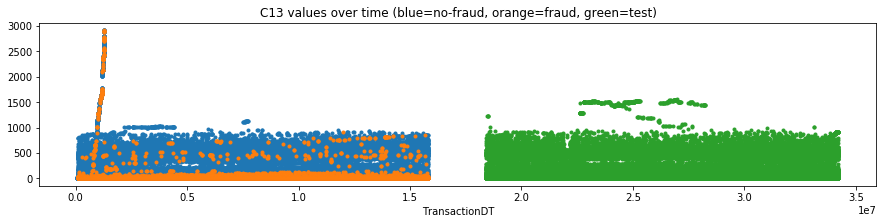

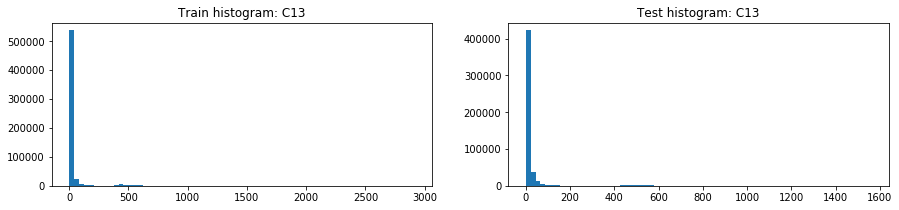

,C13,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,501943.000000,101339.000000,400605.000000
1,mean,32.539918,24.967768,32.814474,27.816035,30.227395,27.205996
2,std,129.364844,165.979050,127.832166,101.114033,99.669624,101.467080
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,3.000000,1.000000,3.000000,3.000000,4.000000,2.000000
6,75%,12.000000,6.000000,13.000000,13.000000,15.000000,12.000000
7,max,2918.000000,2915.000000,2918.000000,1562.000000,1230.000000,1562.000000
8,unique values,1597.000000,392.000000,1567.000000,1070.000000,797.000000,1062.000000
9,NaNs,0.000000,0.000000,0.000000,4748.000000,0.000000,4748.000000


,C13,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,199337,0.028304,5642,168280.0
1,2.0,57616,0.039277,2263,49947.0
2,0.0,35460,0.141032,5001,29778.0
3,3.0,33033,0.033058,1092,27602.0
4,4.0,23704,0.035943,852,19240.0
5,5.0,18355,0.031926,586,15076.0
6,6.0,15127,0.031599,478,12659.0
7,7.0,13001,0.029536,384,10885.0
8,8.0,11424,0.032213,368,9603.0
9,9.0,10189,0.018549,189,8972.0


,C13,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,199337,0.028304,5642,168280
1,0.0,35460,0.141032,5001,29778
2,2.0,57616,0.039277,2263,49947
3,3.0,33033,0.033058,1092,27602
4,4.0,23704,0.035943,852,19240
5,5.0,18355,0.031926,586,15076
6,6.0,15127,0.031599,478,12659
7,7.0,13001,0.029536,384,10885
8,8.0,11424,0.032213,368,9603
9,13.0,8032,0.030752,247,6945


,Column,Correlation with C13
0,C13,1.000000
1,C14,0.880722
2,C6,0.808531
3,C11,0.779286
4,C1,0.774603
5,C2,0.751221
375,V21,-0.094623
376,V31,-0.096270
377,V34,-0.098281
378,V15,-0.098404


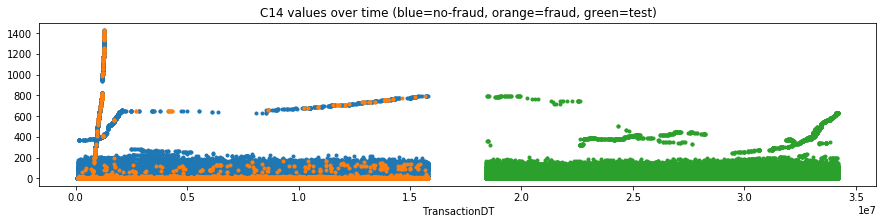

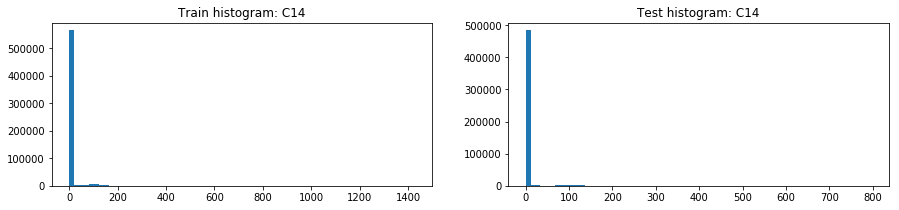

,C14,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590540.000000,20663.000000,569877.000000,506688.000000,101339.000000,405350.000000
1,mean,8.295215,10.356047,8.220491,6.083890,6.089058,6.082590
2,std,49.544262,82.902579,47.898725,28.315616,25.507991,28.975051
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000
7,max,1429.000000,1426.000000,1429.000000,797.000000,797.000000,748.000000
8,unique values,1108.000000,244.000000,1085.000000,570.000000,204.000000,548.000000
9,NaNs,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000


,C14,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,320189,0.026859,8600,278331.0
1,2.0,93843,0.027663,2596,81914.0
2,3.0,44471,0.026939,1198,38444.0
3,0.0,35947,0.145047,5214,34564.0
4,4.0,25390,0.030248,768,21074.0
5,5.0,15655,0.026828,420,11757.0
6,6.0,8563,0.032932,282,6781.0
7,7.0,5030,0.031014,156,3987.0
8,8.0,3471,0.048113,167,2583.0
9,9.0,2651,0.064881,172,2203.0


,C14,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,320189,0.026859,8600,278331
1,0.0,35947,0.145047,5214,34564
2,2.0,93843,0.027663,2596,81914
3,3.0,44471,0.026939,1198,38444
4,4.0,25390,0.030248,768,21074
5,5.0,15655,0.026828,420,11757
6,6.0,8563,0.032932,282,6781
7,9.0,2651,0.064881,172,2203
8,8.0,3471,0.048113,167,2583
9,7.0,5030,0.031014,156,3987


,Column,Correlation with C14
0,C14,1.000000
1,C6,0.984201
2,C11,0.962465
3,C1,0.951761
4,C2,0.936148
5,C4,0.907676
375,V31,-0.073593
376,V15,-0.074301
377,V21,-0.075669
378,V33,-0.077545


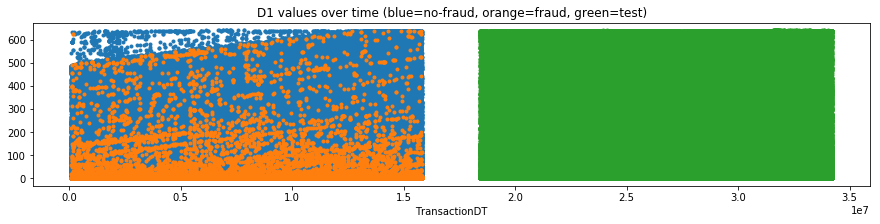

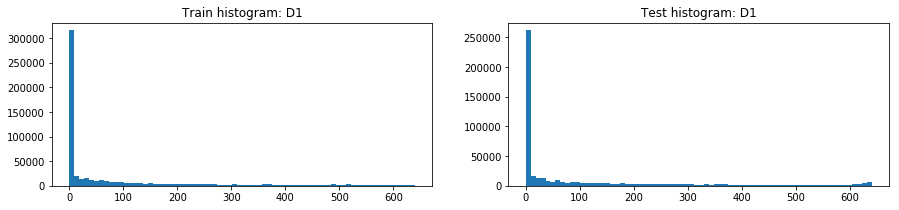

,D1,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,589271.000000,20617.000000,568654.000000,500660.000000,100922.000000,399739.000000
1,mean,94.347568,38.711306,96.364705,108.207504,116.985543,105.991247
2,std,157.660387,100.915599,158.973258,176.964526,180.117849,176.090322
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,3.000000,0.000000,4.000000,5.000000,16.000000,3.000000
6,75%,122.000000,14.000000,126.000000,148.000000,167.000000,142.000000
7,max,640.000000,637.000000,640.000000,641.000000,638.000000,641.000000
8,unique values,642.000000,578.000000,642.000000,643.000000,640.000000,643.000000
9,NaNs,1269.000000,46.000000,1223.000000,6031.000000,417.000000,5614.000000


,D1,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,280130,0.042084,11789,227724
1,1.0,8634,0.120454,1040,8253
2,2.0,4969,0.114107,567,5005
3,3.0,3954,0.098634,390,4084
4,4.0,3570,0.075350,269,3395
5,7.0,3455,0.043994,152,3317
6,6.0,3164,0.075853,240,2867
7,5.0,3076,0.076723,236,2873
8,14.0,2979,0.035247,105,2569
9,8.0,2637,0.056883,150,2275


,D1,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,280130,0.042084,11789,227724
1,1.0,8634,0.120454,1040,8253
2,2.0,4969,0.114107,567,5005
3,3.0,3954,0.098634,390,4084
4,4.0,3570,0.075350,269,3395
5,6.0,3164,0.075853,240,2867
6,5.0,3076,0.076723,236,2873
7,9.0,2387,0.067449,161,1939
8,7.0,3455,0.043994,152,3317
9,8.0,2637,0.056883,150,2275


,Column,Correlation with D1
0,D1,1.000000
1,D2,0.981311
2,D15,0.638957
3,D11,0.592629
4,D4,0.585714
5,D10,0.562145
375,V153,-0.269759
376,V197,-0.272491
377,V194,-0.295450
378,V283,-0.355794


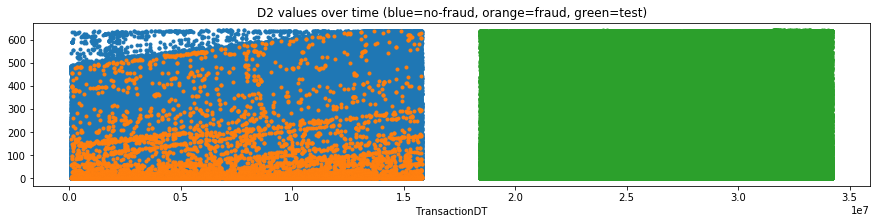

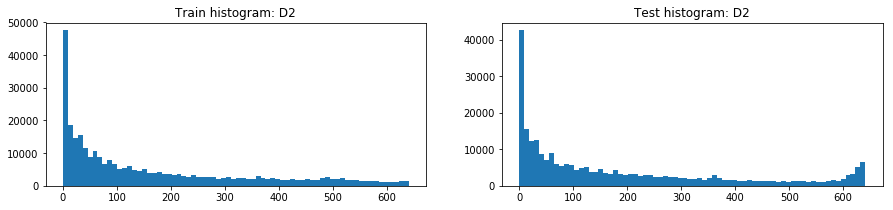

,D2,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,309743.000000,7870.000000,301873.000000,271922.000000,58869.000000,213054.000000
1,mean,169.563231,77.774206,171.956223,188.666621,190.231582,188.233701
2,std,177.315865,128.697847,177.773639,197.099611,195.973461,197.407591
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,26.000000,2.000000,27.000000,26.000000,29.000000,24.000000
5,50%,97.000000,16.000000,100.000000,112.000000,118.000000,111.000000
6,75%,276.000000,95.000000,280.000000,305.000000,301.000000,307.000000
7,max,640.000000,637.000000,640.000000,641.000000,638.000000,641.000000
8,unique values,642.000000,542.000000,642.000000,643.000000,640.000000,643.000000
9,NaNs,280797.000000,12793.000000,268004.000000,234769.000000,42470.000000,192299.000000


,D2,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,280797,0.045560,12793,234769
1,0.0,15124,0.061822,935,11944
2,1.0,6654,0.114968,765,6467
3,2.0,4454,0.099461,443,4445
4,3.0,3677,0.088659,326,3829
5,4.0,3344,0.063397,212,3162
6,7.0,3331,0.036325,121,3198
7,6.0,3068,0.067471,207,2771
8,5.0,2972,0.066285,197,2752
9,14.0,2919,0.029805,87,2477


,D2,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,280797,0.045560,12793,234769
1,0.0,15124,0.061822,935,11944
2,1.0,6654,0.114968,765,6467
3,2.0,4454,0.099461,443,4445
4,3.0,3677,0.088659,326,3829
5,4.0,3344,0.063397,212,3162
6,6.0,3068,0.067471,207,2771
7,5.0,2972,0.066285,197,2752
8,7.0,3331,0.036325,121,3198
9,8.0,2593,0.042422,110,2140


,Column,Correlation with D2
0,D2,1.000000
1,D1,0.981311
2,D12,0.668833
3,D15,0.618243
4,D6,0.601299
5,D4,0.570017
375,V174,-0.335111
376,V283,-0.375585
377,V282,-0.453760
378,V289,-0.507014


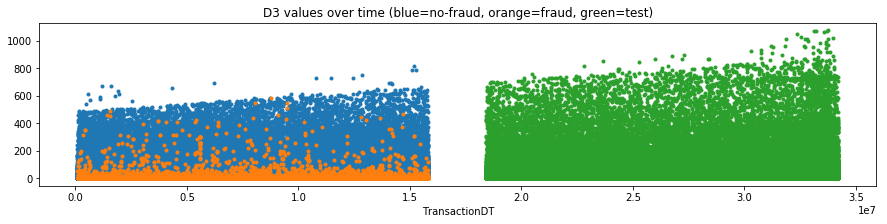

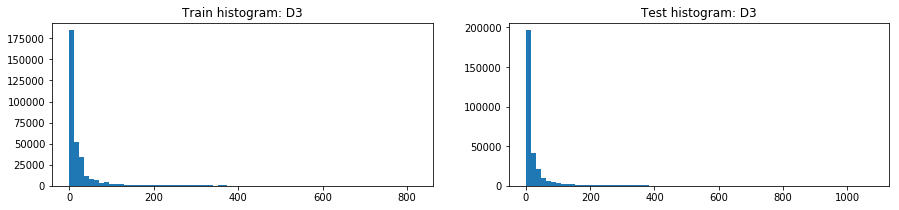

,D3,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,327662.000000,9619.000000,318043.000000,303549.000000,63607.000000,239943.000000
1,mean,28.343348,11.744880,28.845357,33.394727,29.559294,34.411381
2,std,62.384721,42.005468,62.830058,82.558210,68.249815,85.924044
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
5,50%,8.000000,1.000000,8.000000,7.000000,8.000000,7.000000
6,75%,27.000000,5.000000,28.000000,28.000000,28.000000,28.000000
7,max,819.000000,582.000000,819.000000,1076.000000,754.000000,1076.000000
8,unique values,650.000000,262.000000,650.000000,888.000000,654.000000,888.000000
9,NaNs,262878.000000,11044.000000,251834.000000,203142.000000,37732.000000,165410.000000


,D3,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,262878,0.042012,11044,203142.0
1,0.0,73094,0.060251,4404,73232.0
2,1.0,21258,0.069386,1475,20276.0
3,2.0,13789,0.046776,645,13103.0
4,7.0,13320,0.015015,200,11442.0
5,3.0,10786,0.031986,345,10226.0
6,4.0,9552,0.026068,249,8664.0
7,14.0,9547,0.011312,108,8060.0
8,6.0,9245,0.020227,187,8093.0
9,5.0,8800,0.022386,197,7722.0


,D3,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,262878,0.042012,11044,203142
1,0.0,73094,0.060251,4404,73232
2,1.0,21258,0.069386,1475,20276
3,2.0,13789,0.046776,645,13103
4,3.0,10786,0.031986,345,10226
5,4.0,9552,0.026068,249,8664
6,7.0,13320,0.015015,200,11442
7,5.0,8800,0.022386,197,7722
8,6.0,9245,0.020227,187,8093
9,8.0,8092,0.016189,131,6859


,Column,Correlation with D3
0,D3,1.000000
1,D7,0.818080
2,D5,0.707425
3,D12,0.349025
4,D6,0.304947
5,D1,0.280423
374,V144,-0.266504
375,V330,-0.276352
376,V328,-0.279979
377,V327,-0.341241


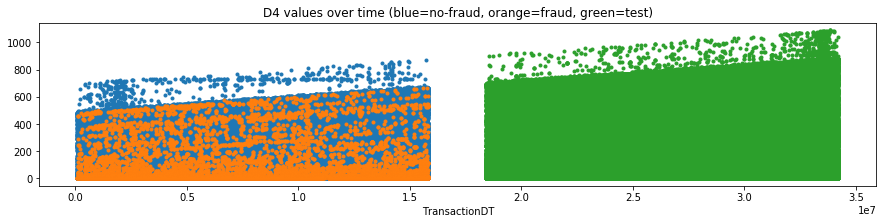

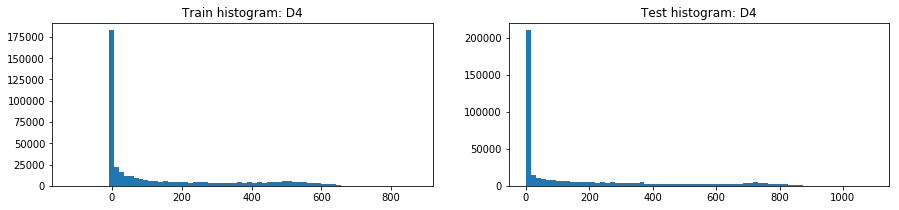

,D4,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421618.000000,14567.000000,407051.000000,429840.000000,80248.000000,349593.000000
1,mean,140.002441,72.102904,142.432339,175.060799,180.750735,173.754323
2,std,191.096774,140.656090,192.213375,250.417470,233.899500,254.039684
3,min,-122.000000,0.000000,-122.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,26.000000,1.000000,28.000000,21.000000,54.000000,14.000000
6,75%,253.000000,61.000000,261.000000,290.000000,313.000000,284.000000
7,max,869.000000,667.000000,869.000000,1091.000000,924.000000,1091.000000
8,unique values,809.000000,606.000000,809.000000,1057.000000,779.000000,1056.000000
9,NaNs,168922.000000,6096.000000,162826.000000,76851.000000,21091.000000,55760.000000


,D4,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,168922,0.036088,6096,76851.0
1,0.0,166571,0.039641,6603,178278.0
2,1.0,5315,0.144873,770,5750.0
3,2.0,3385,0.126145,427,3502.0
4,3.0,2572,0.108476,279,2871.0
5,4.0,2354,0.084962,200,2459.0
6,7.0,2317,0.060855,141,2165.0
7,5.0,2172,0.100829,219,2125.0
8,14.0,2117,0.033066,70,1644.0
9,6.0,2038,0.074092,151,2093.0


,D4,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,166571,0.039641,6603,178278
1,-999.0,168922,0.036088,6096,76851
2,1.0,5315,0.144873,770,5750
3,2.0,3385,0.126145,427,3502
4,3.0,2572,0.108476,279,2871
5,5.0,2172,0.100829,219,2125
6,4.0,2354,0.084962,200,2459
7,6.0,2038,0.074092,151,2093
8,7.0,2317,0.060855,141,2165
9,9.0,1548,0.080749,125,1241


,Column,Correlation with D4
0,D4,1.000000
1,D12,0.999999
2,D6,0.956966
3,D15,0.751546
4,D11,0.657797
5,D10,0.636928
375,V149,-0.360508
376,V155,-0.373805
377,V148,-0.376986
378,V154,-0.377323


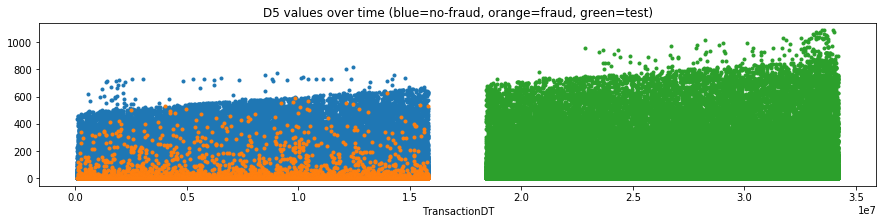

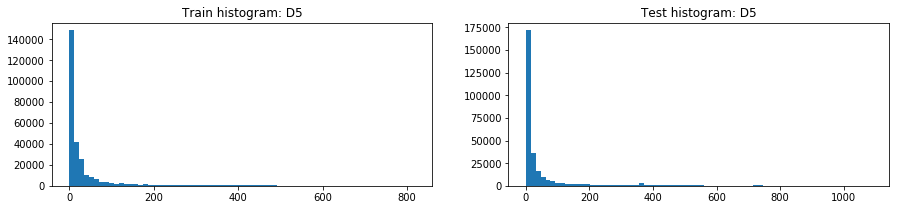

,D5,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,280699.000000,10880.000000,269819.000000,282316.000000,58085.000000,224232.000000
1,mean,42.335965,13.687776,43.491155,50.977752,42.060222,53.287649
2,std,89.000144,51.891635,89.985719,116.829786,94.246337,121.893591
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
5,50%,10.000000,0.000000,10.000000,8.000000,9.000000,8.000000
6,75%,32.000000,3.000000,34.000000,34.000000,32.000000,34.000000
7,max,819.000000,625.000000,819.000000,1088.000000,779.000000,1088.000000
8,unique values,689.000000,342.000000,689.000000,962.000000,711.000000,962.000000
9,NaNs,309841.000000,9783.000000,300058.000000,224375.000000,43254.000000,181121.000000


,D5,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,309841,0.031574,9783,224375
1,0.0,65377,0.101534,6638,73887
2,1.0,15282,0.065829,1006,15642
3,2.0,10244,0.044026,451,10188
4,7.0,9734,0.015307,149,9103
5,3.0,7987,0.033805,270,7977
6,14.0,7340,0.008311,61,6557
7,4.0,7176,0.027592,198,6755
8,6.0,6907,0.020414,141,6521
9,5.0,6696,0.025090,168,6196


,D5,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,309841,0.031574,9783,224375
1,0.0,65377,0.101534,6638,73887
2,1.0,15282,0.065829,1006,15642
3,2.0,10244,0.044026,451,10188
4,3.0,7987,0.033805,270,7977
5,4.0,7176,0.027592,198,6755
6,5.0,6696,0.025090,168,6196
7,7.0,9734,0.015307,149,9103
8,6.0,6907,0.020414,141,6521
9,8.0,6140,0.018567,114,5549


,Column,Correlation with D5
0,D5,1.000000
1,D7,0.986496
2,D3,0.707425
3,D12,0.565222
4,D6,0.551310
5,D4,0.313650
372,V155,-0.344677
373,V153,-0.346386
374,V148,-0.347020
375,V158,-0.367735


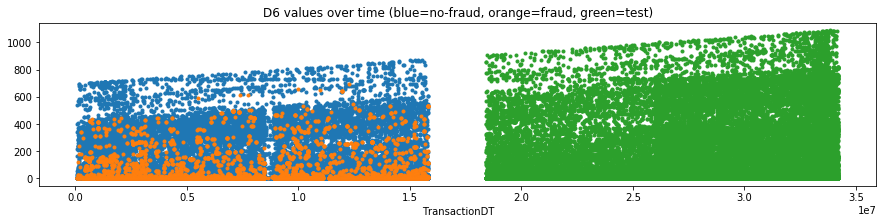

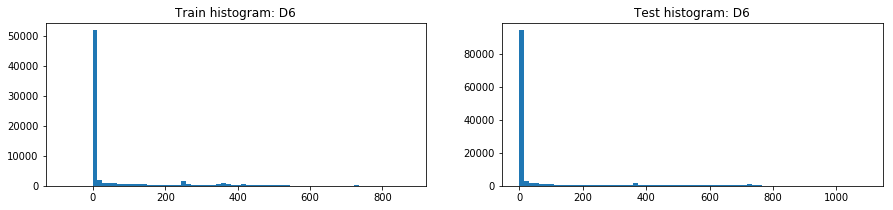

,D6,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,73187.000000,7718.000000,65469.000000,124783.000000,11194.000000,113589.000000
1,mean,69.805717,45.856439,72.629046,82.443145,89.538503,81.743910
2,std,143.669253,101.424445,147.600963,192.867671,178.595333,194.204124
3,min,-83.000000,0.000000,-83.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,40.000000,24.000000,43.000000,13.000000,68.750000,10.000000
7,max,873.000000,694.000000,873.000000,1091.000000,939.000000,1091.000000
8,unique values,830.000000,381.000000,830.000000,1073.000000,726.000000,1072.000000
9,NaNs,517353.000000,12945.000000,504408.000000,381908.000000,90145.000000,291764.000000


,D6,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,517353,0.025022,12945,381908.0
1,0.0,45782,0.092897,4253,83120.0
2,1.0,1588,0.261335,415,2475.0
3,256.0,895,0.012291,11,22.0
4,2.0,855,0.215205,184,1482.0
5,3.0,642,0.208723,134,1192.0
6,4.0,579,0.143351,83,927.0
7,5.0,436,0.236239,103,783.0
8,7.0,380,0.184211,70,717.0
9,6.0,353,0.141643,50,710.0


,D6,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,517353,0.025022,12945,381908
1,0.0,45782,0.092897,4253,83120
2,1.0,1588,0.261335,415,2475
3,2.0,855,0.215205,184,1482
4,3.0,642,0.208723,134,1192
5,5.0,436,0.236239,103,783
6,4.0,579,0.143351,83,927
7,7.0,380,0.184211,70,717
8,9.0,258,0.213178,55,352
9,8.0,288,0.180556,52,474


,Column,Correlation with D6
0,D6,1.000000
1,D12,0.976834
2,D4,0.956966
3,D15,0.700615
4,D2,0.601299
5,D5,0.551310
342,V149,-0.698995
343,V155,-0.703838
344,V148,-0.703948
345,V154,-0.704417


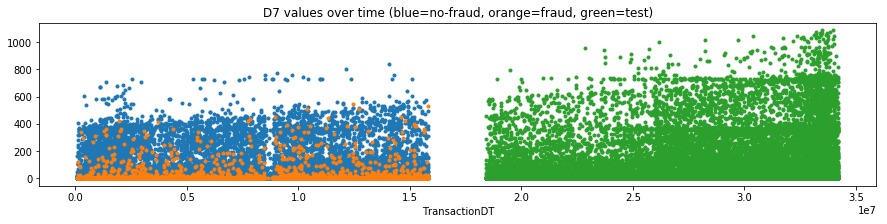

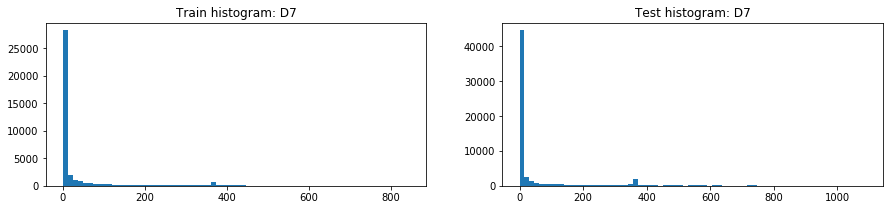

,D7,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,38917.000000,5790.000000,33127.000000,60133.000000,7160.000000,52973.000000
1,mean,41.638950,11.292228,46.943007,61.815642,33.610615,65.627924
2,std,99.743264,46.743057,105.435756,150.299612,94.096670,155.963738
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,17.000000,0.000000,24.000000,18.000000,9.000000,20.000000
7,max,843.000000,547.000000,843.000000,1088.000000,798.000000,1088.000000
8,unique values,598.000000,242.000000,598.000000,905.000000,440.000000,904.000000
9,NaNs,551623.000000,14873.000000,536750.000000,446558.000000,94179.000000,352380.000000


,D7,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,551623,0.026962,14873,446558.0
1,0.0,21135,0.211592,4472,31939.0
2,1.0,1717,0.141526,243,2868.0
3,2.0,998,0.108216,108,1850.0
4,3.0,791,0.085967,68,1296.0
5,7.0,606,0.059406,36,886.0
6,4.0,601,0.093178,56,1004.0
7,5.0,513,0.097466,50,852.0
8,6.0,435,0.073563,32,792.0
9,8.0,387,0.080103,31,567.0


,D7,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,551623,0.026962,14873,446558
1,0.0,21135,0.211592,4472,31939
2,1.0,1717,0.141526,243,2868
3,2.0,998,0.108216,108,1850
4,3.0,791,0.085967,68,1296
5,4.0,601,0.093178,56,1004
6,5.0,513,0.097466,50,852
7,7.0,606,0.059406,36,886
8,6.0,435,0.073563,32,792
9,8.0,387,0.080103,31,567


,Column,Correlation with D7
0,D7,1.000000
1,D5,0.986496
2,D3,0.818080
3,D4,0.574098
4,D12,0.553886
5,D6,0.506527
342,V328,-0.266689
343,V144,-0.269043
344,V152,-0.275670
345,V327,-0.332058


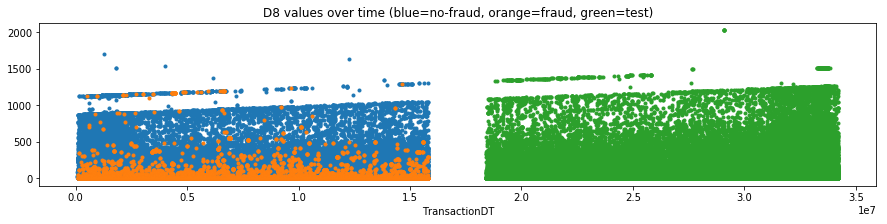

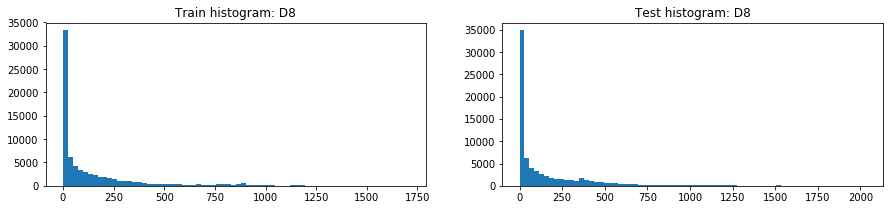

,D8,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,74926.000000,7827.000000,67099.000000,74338.000000,10200.000000,64138.000000
1,mean,146.058108,49.309191,157.343727,160.834483,146.638799,163.092053
2,std,231.663840,133.254994,237.987816,257.003738,249.691565,258.077466
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.958333,0.750000,1.750000,1.083333,0.916666,1.208333
5,50%,37.875000,2.666666,50.583332,37.708332,30.916666,38.875000
6,75%,187.958328,32.375000,207.541672,221.125000,182.875000,227.750000
7,max,1707.791626,1290.583374,1707.791626,2029.583374,1373.041626,2029.583374
8,unique values,12354.000000,1352.000000,12207.000000,13245.000000,3683.000000,12457.000000
9,NaNs,515614.000000,12836.000000,502778.000000,432353.000000,91139.000000,341215.000000


,D8,Count in train (desc),Mean target,Sum target,Count in test
0,-999.000000,515614,0.024895,12836,432353.0
1,0.791666,1351,0.179127,242,1263.0
2,0.833333,1327,0.158252,210,1282.0
3,0.875000,1304,0.199387,260,1299.0
4,0.958333,1300,0.197692,257,1180.0
5,0.916666,1259,0.181096,228,1132.0
6,0.750000,1248,0.173878,217,1107.0
7,0.708333,1175,0.122553,144,1038.0
8,0.083333,1118,0.167263,187,1083.0
9,0.666666,1097,0.121240,133,1075.0


,D8,Count in train,Mean target,Sum target (desc),Count in test
0,-999.000000,515614,0.024895,12836,432353
1,0.875000,1304,0.199387,260,1299
2,0.958333,1300,0.197692,257,1180
3,0.791666,1351,0.179127,242,1263
4,0.916666,1259,0.181096,228,1132
5,0.750000,1248,0.173878,217,1107
6,0.833333,1327,0.158252,210,1282
7,0.083333,1118,0.167263,187,1083
8,0.000000,835,0.203593,170,763
9,0.125000,1028,0.162451,167,1052


,Column,Correlation with D8
0,D8,1.000000
1,D13,0.521432
2,D2,0.275304
3,D5,0.249365
4,D15,0.226635
5,V192,0.226623
342,V171,-0.206093
343,V197,-0.206170
344,V79,-0.229298
345,V194,-0.232542


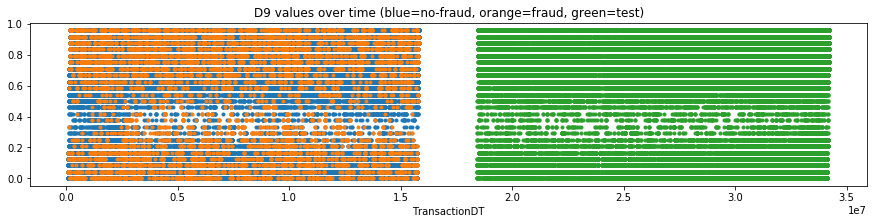

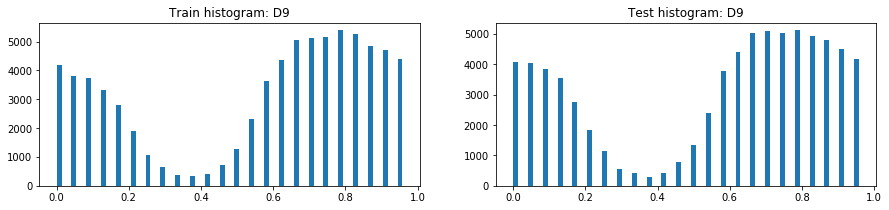

,D9,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,74926.000000,7827.000000,67099.000000,74338.000000,10200.000000,64138.000000
1,mean,0.561057,0.520000,0.565846,0.553981,0.554093,0.553963
2,std,0.316880,0.333188,0.314576,0.317327,0.314076,0.317843
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.208333,0.166666,0.208333,0.208333,0.208333,0.208333
5,50%,0.666666,0.625000,0.666666,0.666666,0.666666,0.666666
6,75%,0.833333,0.833333,0.833333,0.791666,0.791666,0.791666
7,max,0.958333,0.958333,0.958333,0.958333,0.958333,0.958333
8,unique values,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
9,NaNs,515614.000000,12836.000000,502778.000000,432353.000000,91139.000000,341215.000000


,D9,Count in train (desc),Mean target,Sum target,Count in test
0,-999.000000,515614,0.024895,12836,432353
1,0.791666,5388,0.095768,516,5111
2,0.833333,5273,0.095202,502,4939
3,0.750000,5147,0.091898,473,5033
4,0.708333,5132,0.080670,414,5106
5,0.666666,5069,0.074965,380,5021
6,0.875000,4857,0.106444,517,4805
7,0.916666,4694,0.106306,499,4503
8,0.958333,4411,0.120834,533,4179
9,0.625000,4380,0.059817,262,4415


,D9,Count in train,Mean target,Sum target (desc),Count in test
0,-999.000000,515614,0.024895,12836,432353
1,0.958333,4411,0.120834,533,4179
2,0.875000,4857,0.106444,517,4805
3,0.791666,5388,0.095768,516,5111
4,0.833333,5273,0.095202,502,4939
5,0.916666,4694,0.106306,499,4503
6,0.750000,5147,0.091898,473,5033
7,0.083333,3726,0.123725,461,3841
8,0.000000,4190,0.108353,454,4062
9,0.166666,2786,0.151113,421,2760


,Column,Correlation with D9
0,D9,1.000000
1,TransactionAmt,0.073852
2,D8,0.066085
3,D10,0.063333
4,D15,0.054647
5,D2,0.042867
342,V79,-0.078992
343,V15,-0.080027
344,V33,-0.081018
345,V94,-0.101789


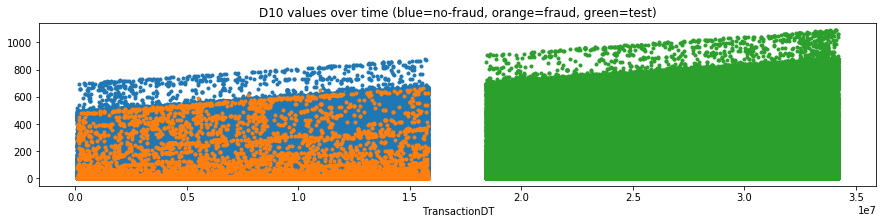

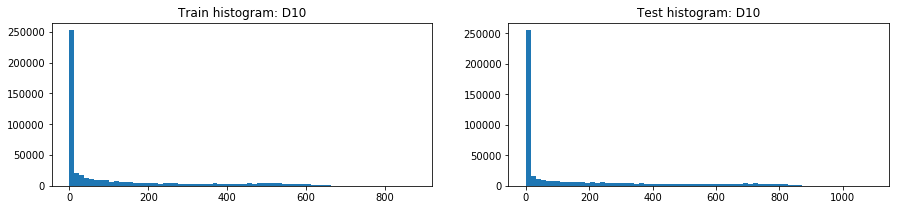

,D10,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514518.000000,16777.000000,497741.000000,494146.000000,93904.000000,400243.000000
1,mean,123.982137,52.363653,126.396130,159.810552,166.648183,158.206127
2,std,182.615225,127.051078,183.710646,240.566557,226.360455,243.751914
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,15.000000,0.000000,18.000000,10.000000,42.000000,4.000000
6,75%,197.000000,14.000000,205.000000,250.000000,266.000000,246.000000
7,max,876.000000,664.000000,876.000000,1091.000000,947.000000,1091.000000
8,unique values,819.000000,614.000000,819.000000,1076.000000,820.000000,1076.000000
9,NaNs,76022.000000,3886.000000,72136.000000,12545.000000,7435.000000,5110.000000


,D10,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,221930,0.047497,10541,227999
1,-999.0,76022,0.051117,3886,12545
2,1.0,5186,0.104512,542,4298
3,2.0,3482,0.097358,339,2782
4,3.0,2756,0.068578,189,2169
5,7.0,2740,0.041971,115,1817
6,14.0,2512,0.024283,61,1698
7,5.0,2377,0.052587,125,1670
8,28.0,2346,0.016198,38,1453
9,4.0,2344,0.062713,147,1945


,D10,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,221930,0.047497,10541,227999
1,-999.0,76022,0.051117,3886,12545
2,1.0,5186,0.104512,542,4298
3,2.0,3482,0.097358,339,2782
4,3.0,2756,0.068578,189,2169
5,4.0,2344,0.062713,147,1945
6,5.0,2377,0.052587,125,1670
7,7.0,2740,0.041971,115,1817
8,6.0,2303,0.044724,103,1688
9,9.0,1769,0.049746,88,1132


,Column,Correlation with D10
0,D10,1.000000
1,D15,0.712252
2,D4,0.636928
3,D11,0.609652
4,D1,0.562145
5,D2,0.525967
375,V156,-0.408720
376,V155,-0.427236
377,V148,-0.427647
378,V154,-0.428474


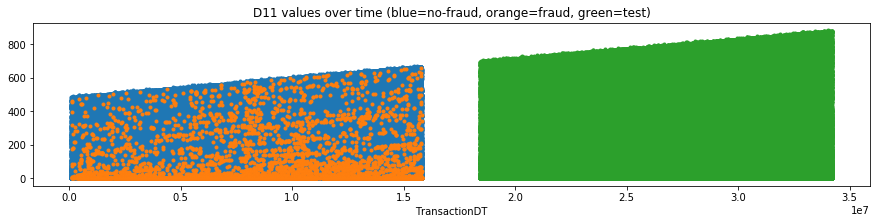

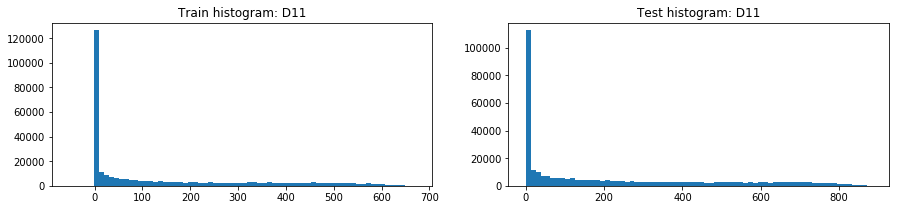

,D11,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,146.621465,87.314445,147.808201,218.414895,197.138943,224.585117
2,std,186.042622,146.561013,186.555365,253.091693,227.897598,259.616540
3,min,-53.000000,0.000000,-53.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,43.000000,7.000000,44.000000,102.000000,93.000000,106.000000
6,75%,274.000000,107.750000,277.000000,401.000000,366.000000,412.000000
7,max,670.000000,655.000000,670.000000,883.000000,742.000000,883.000000
8,unique values,677.000000,557.000000,677.000000,881.000000,739.000000,881.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,D11,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,279287,0.052122,14557,176518.0
1,0.0,112281,0.019522,2192,93125.0
2,1.0,3165,0.087836,278,3812.0
3,2.0,2020,0.083168,168,2334.0
4,3.0,1642,0.077954,128,1889.0
5,7.0,1639,0.042709,70,1564.0
6,14.0,1496,0.020722,31,1403.0
7,4.0,1449,0.077295,112,1709.0
8,6.0,1440,0.062500,90,1553.0
9,5.0,1424,0.052669,75,1414.0


,D11,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,0.0,112281,0.019522,2192,93125
2,1.0,3165,0.087836,278,3812
3,2.0,2020,0.083168,168,2334
4,3.0,1642,0.077954,128,1889
5,4.0,1449,0.077295,112,1709
6,6.0,1440,0.062500,90,1553
7,5.0,1424,0.052669,75,1414
8,7.0,1639,0.042709,70,1564
9,11.0,1011,0.055391,56,993


,Column,Correlation with D11
0,D11,1.000000
1,D15,0.765000
2,D4,0.657797
3,D10,0.609652
4,D1,0.592629
5,D2,0.563220
168,V36,-0.269785
169,V35,-0.284230
170,V76,-0.289223
171,V75,-0.308764


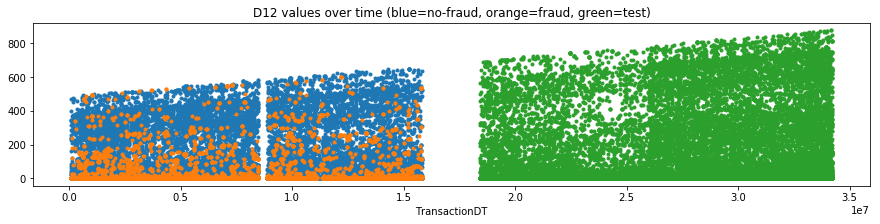

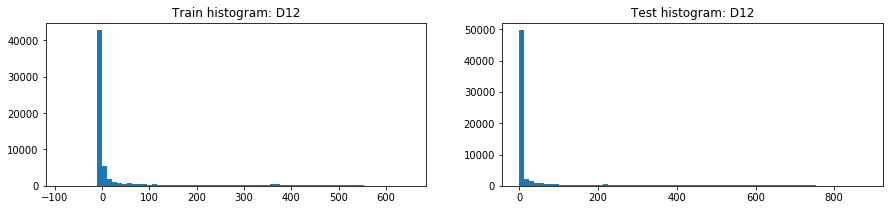

,D12,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,64717.000000,7598.000000,57119.000000,69254.000000,9801.000000,59453.000000
1,mean,54.037533,44.202553,55.345787,77.404179,69.285787,78.742519
2,std,124.274558,99.349394,127.166079,176.218548,154.518366,179.510165
3,min,-83.000000,0.000000,-83.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,13.000000,22.000000,11.000000,25.000000,24.000000,25.000000
7,max,648.000000,602.000000,648.000000,879.000000,728.000000,879.000000
8,unique values,636.000000,364.000000,635.000000,867.000000,602.000000,867.000000
9,NaNs,525823.000000,13065.000000,512758.000000,437437.000000,91538.000000,345900.000000


,D12,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,525823,0.024847,13065,437437.0
1,0.0,42756,0.098676,4219,40855.0
2,1.0,1526,0.275229,420,2043.0
3,2.0,818,0.223716,183,1272.0
4,3.0,634,0.219243,139,1061.0
5,4.0,564,0.141844,80,798.0
6,5.0,418,0.239234,100,691.0
7,7.0,373,0.195710,73,658.0
8,6.0,341,0.146628,50,630.0
9,8.0,273,0.179487,49,414.0


,D12,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,525823,0.024847,13065,437437
1,0.0,42756,0.098676,4219,40855
2,1.0,1526,0.275229,420,2043
3,2.0,818,0.223716,183,1272
4,3.0,634,0.219243,139,1061
5,5.0,418,0.239234,100,691
6,4.0,564,0.141844,80,798
7,7.0,373,0.195710,73,658
8,9.0,249,0.216867,54,309
9,6.0,341,0.146628,50,630


,Column,Correlation with D12
0,D12,1.000000
1,D4,0.999999
2,D6,0.976834
3,D2,0.668833
4,D15,0.608192
5,D5,0.565222
287,V195,-0.281923
288,V194,-0.288072
289,V198,-0.292729
290,V197,-0.310688


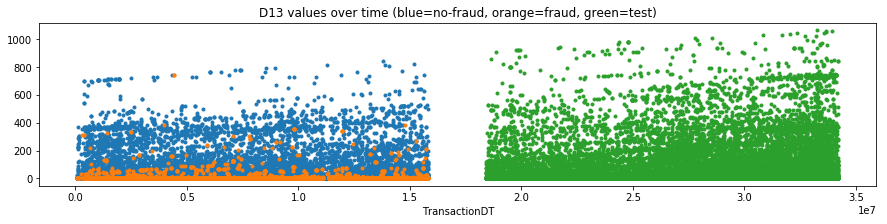

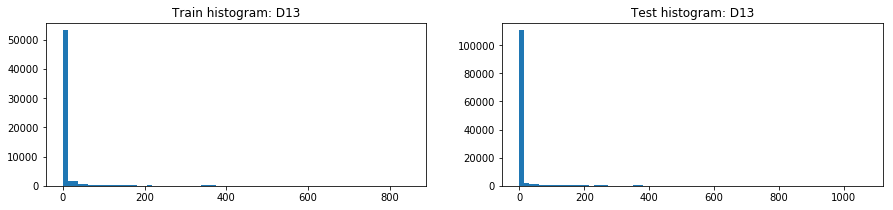

,D13,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,61952.000000,6837.000000,55115.000000,123384.000000,10039.000000,113345.000000
1,mean,17.901295,6.492321,19.316574,18.225961,24.144138,17.701787
2,std,67.614425,31.330429,70.703174,78.079890,82.980232,77.609589
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
7,max,847.000000,745.000000,847.000000,1066.000000,946.000000,1066.000000
8,unique values,578.000000,130.000000,578.000000,806.000000,398.000000,790.000000
9,NaNs,528588.000000,13826.000000,514762.000000,383307.000000,91300.000000,292008.000000


,D13,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,528588,0.026156,13826,383307.0
1,0.0,48840,0.111138,5428,101387.0
2,1.0,1097,0.227894,250,2103.0
3,26.0,891,0.001122,1,118.0
4,2.0,623,0.290530,181,1294.0
5,3.0,476,0.197479,94,898.0
6,4.0,366,0.174863,64,702.0
7,19.0,343,0.000000,0,158.0
8,5.0,316,0.202532,64,552.0
9,7.0,303,0.158416,48,623.0


,D13,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,528588,0.026156,13826,383307
1,0.0,48840,0.111138,5428,101387
2,1.0,1097,0.227894,250,2103
3,2.0,623,0.290530,181,1294
4,3.0,476,0.197479,94,898
5,4.0,366,0.174863,64,702
6,5.0,316,0.202532,64,552
7,7.0,303,0.158416,48,623
8,9.0,203,0.221675,45,355
9,6.0,262,0.164122,43,584


,Column,Correlation with D13
0,D13,1.000000
1,D8,0.521432
2,D15,0.431177
3,D6,0.419894
4,D2,0.394203
5,D4,0.383803
342,V188,-0.283609
343,V195,-0.709209
344,V198,-0.714801
345,V194,-0.722523


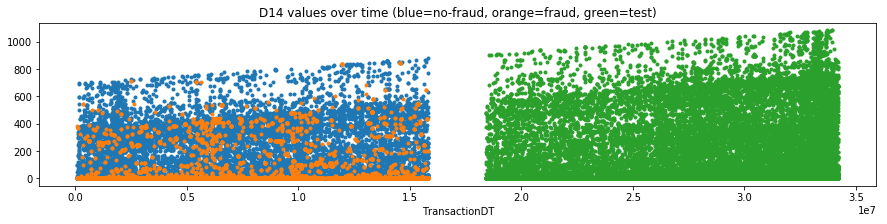

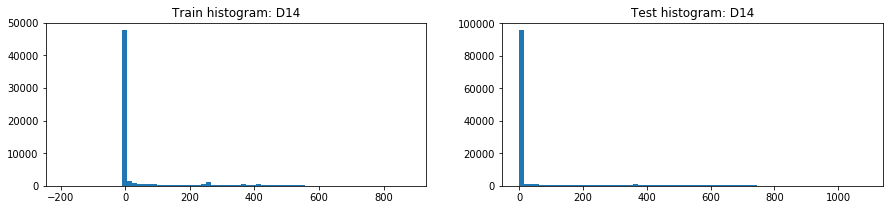

,D14,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,62187.000000,7213.000000,54974.000000,115194.000000,9735.000000,105459.000000
1,mean,57.724444,54.464578,58.152163,58.163186,76.289985,56.489887
2,std,136.312450,126.586127,137.532930,164.015525,168.656158,163.480027
3,min,-193.000000,0.000000,-193.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,2.000000,9.000000,1.000000,0.000000,17.000000,0.000000
7,max,878.000000,847.000000,878.000000,1085.000000,938.000000,1085.000000
8,unique values,803.000000,382.000000,801.000000,1032.000000,648.000000,1029.000000
9,NaNs,528353.000000,13450.000000,514903.000000,391497.000000,91604.000000,299894.000000


,D14,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,528353,0.025456,13450,391497.0
1,0.0,45266,0.097954,4434,89500.0
2,1.0,1105,0.361086,399,1744.0
3,256.0,658,0.001520,1,19.0
4,2.0,495,0.397980,197,740.0
5,3.0,307,0.312704,96,498.0
6,249.0,284,0.000000,0,15.0
7,4.0,260,0.234615,61,531.0
8,7.0,233,0.188841,44,363.0
9,5.0,210,0.219048,46,478.0


,D14,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,528353,0.025456,13450,391497
1,0.0,45266,0.097954,4434,89500
2,1.0,1105,0.361086,399,1744
3,2.0,495,0.397980,197,740
4,3.0,307,0.312704,96,498
5,4.0,260,0.234615,61,531
6,8.0,158,0.316456,50,234
7,5.0,210,0.219048,46,478
8,7.0,233,0.188841,44,363
9,6.0,183,0.240437,44,333


,Column,Correlation with D14
0,D14,1.000000
1,D10,0.336933
2,V326,0.269067
3,V327,0.260535
4,V335,0.243918
5,V330,0.242274
342,V153,-0.249805
343,V255,-0.309611
344,V256,-0.309642
345,V251,-0.654479


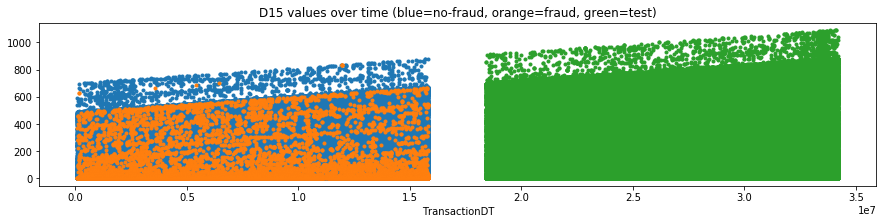

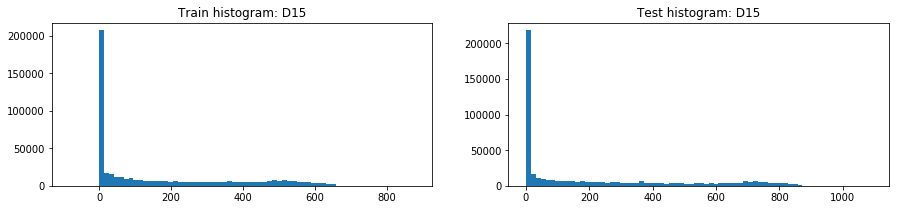

,D15,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501427.000000,16387.000000,485040.000000,494622.000000,94029.000000,400594.000000
1,mean,163.744579,78.245805,166.633142,206.854137,216.941571,204.486061
2,std,202.726660,151.956762,203.595694,269.419196,250.887517,273.533320
3,min,-83.000000,0.000000,-83.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,52.000000,1.000000,56.000000,48.000000,99.000000,35.000000
6,75%,314.000000,63.000000,321.000000,370.000000,406.000000,365.000000
7,max,879.000000,835.000000,879.000000,1091.000000,948.000000,1091.000000
8,unique values,860.000000,642.000000,860.000000,1079.000000,850.000000,1079.000000
9,NaNs,89113.000000,4276.000000,84837.000000,12069.000000,7310.000000,4759.000000


,D15,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,174246,0.045258,7886,183720.0
1,-999.0,89113,0.047984,4276,12069.0
2,1.0,5936,0.120620,716,6202.0
3,2.0,3691,0.119209,440,3793.0
4,3.0,2878,0.092078,265,3106.0
5,7.0,2577,0.051998,134,2360.0
6,4.0,2573,0.071512,184,2747.0
7,5.0,2336,0.076199,178,2202.0
8,6.0,2276,0.060193,137,2276.0
9,14.0,2265,0.039294,89,1853.0


,D15,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,174246,0.045258,7886,183720
1,-999.0,89113,0.047984,4276,12069
2,1.0,5936,0.120620,716,6202
3,2.0,3691,0.119209,440,3793
4,3.0,2878,0.092078,265,3106
5,4.0,2573,0.071512,184,2747
6,5.0,2336,0.076199,178,2202
7,6.0,2276,0.060193,137,2276
8,7.0,2577,0.051998,134,2360
9,8.0,1973,0.060314,119,1674


,Column,Correlation with D15
0,D15,1.000000
1,D11,0.765000
2,D4,0.751546
3,D10,0.712252
4,D6,0.700615
5,D1,0.638957
375,V149,-0.438651
376,V155,-0.442840
377,V154,-0.444239
378,V148,-0.445041


,M1,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,319440,6342,313098,330052,74212,255841
1,unique,2,1,2,2,2,2
2,top,T,T,T,T,T,T
3,freq,319415,6342,313073,330021,74202,255820
4,unique values,3,2,3,3,3,3
5,NaNs,271100,14321,256779,176639,27127,149512
6,NaNs share,0.4591,0.6931,0.4506,0.3486,0.2677,0.3688


...

,M8,Count in train (desc),Mean target,Sum target,Count in test
0,-999,346252,0.045764,15846,235004
1,F,155251,0.021726,3373,168399
2,T,89037,0.016218,1444,103288


,M8,Count in train,Mean target,Sum target (desc),Count in test
0,-999,346252,0.045764,15846,235004
1,F,155251,0.021726,3373,168399
2,T,89037,0.016218,1444,103288


,M9,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,244288,4817,239471,271687,61998,209690
1,unique,2,2,2,2,2,2
2,top,T,T,T,T,T,T
3,freq,205656,3658,201998,236279,53776,182503
4,unique values,3,3,3,3,3,3
5,NaNs,346252,15846,330406,235004,39341,195663
6,NaNs share,0.5863,0.7669,0.5798,0.4638,0.3882,0.4827


,M9,Count in train (desc),Mean target,Sum target,Count in test
0,-999,346252,0.045764,15846,235004
1,T,205656,0.017787,3658,236279
2,F,38632,0.030001,1159,35408


,M9,Count in train,Mean target,Sum target (desc),Count in test
0,-999,346252,0.045764,15846,235004
1,T,205656,0.017787,3658,236279
2,F,38632,0.030001,1159,35408


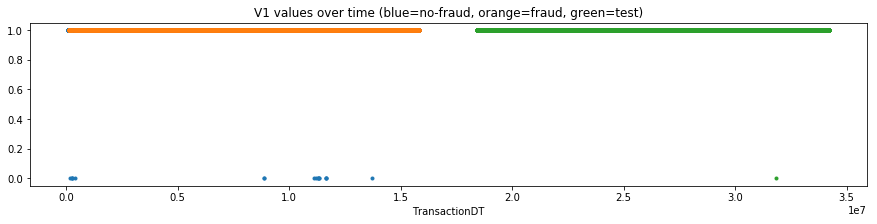

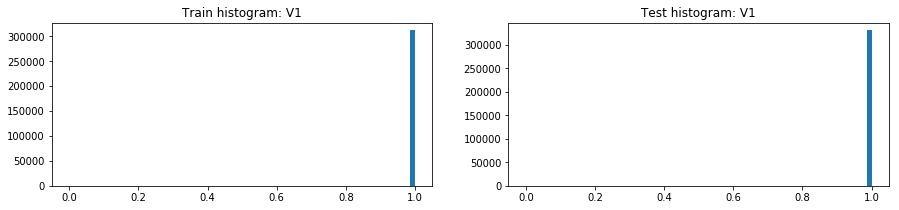

,V1,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.0000,305147.000000,330173.000000,74232.0000,255942.000000
1,mean,0.999945,1.0000,0.999944,0.999997,1.0000,0.999996
2,std,0.007390,0.0000,0.007464,0.001740,0.0000,0.001977
3,min,0.000000,1.0000,0.000000,0.000000,1.0000,0.000000
4,25%,1.000000,1.0000,1.000000,1.000000,1.0000,1.000000
5,50%,1.000000,1.0000,1.000000,1.000000,1.0000,1.000000
6,75%,1.000000,1.0000,1.000000,1.000000,1.0000,1.000000
7,max,1.000000,1.0000,1.000000,1.000000,1.0000,1.000000
8,unique values,3.000000,2.0000,3.000000,3.000000,2.0000,3.000000
9,NaNs,279287.000000,14557.0000,264730.000000,176518.000000,27107.0000,149411.000000


,V1,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,311236,0.019619,6106,330172
1,-999.0,279287,0.052122,14557,176518
2,0.0,17,0.000000,0,1


,V1,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,311236,0.019619,6106,330172
2,0.0,17,0.000000,0,1


,Column,Correlation with V1
0,V1,1.000000
1,V88,0.547708
2,V41,0.462228
3,V8,0.040820
4,V66,0.035722
5,V9,0.034009
167,V282,-0.001198
168,addr1,-0.001638
169,card5,-0.001866
170,D3,-0.002702


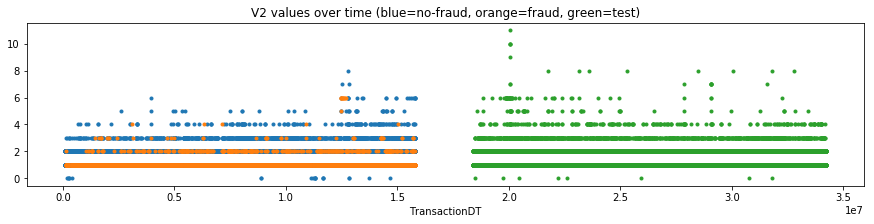

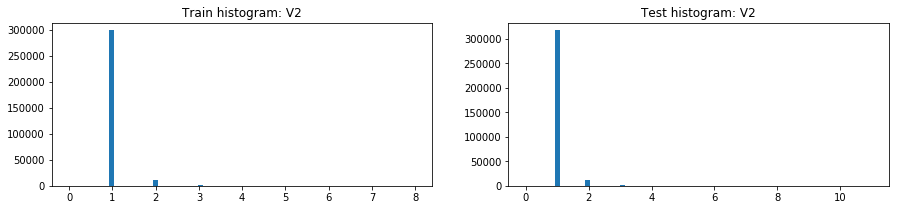

,V2,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,1.045204,1.078939,1.044529,1.046636,1.051649,1.045182
2,std,0.240133,0.351422,0.237326,0.250847,0.284682,0.240125
3,min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,8.000000,6.000000,8.000000,11.000000,11.000000,8.000000
8,unique values,10.000000,7.000000,10.000000,13.000000,13.000000,10.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V2,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,298894,0.019127,5717,316786
1,-999.0,279287,0.052122,14557,176518
2,2.0,10926,0.030203,330,11933
3,3.0,1181,0.037257,44,1099
4,4.0,163,0.030675,5,227
5,5.0,36,0.027778,1,51
6,6.0,30,0.300000,9,47
7,0.0,20,0.000000,0,8
8,7.0,2,0.000000,0,9
9,8.0,1,0.000000,0,8


,V2,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,298894,0.019127,5717,316786
2,2.0,10926,0.030203,330,11933
3,3.0,1181,0.037257,44,1099
4,6.0,30,0.300000,9,47
5,4.0,163,0.030675,5,227
6,5.0,36,0.027778,1,51
7,0.0,20,0.000000,0,8
8,7.0,2,0.000000,0,9
9,8.0,1,0.000000,0,8


,Column,Correlation with V2
0,V2,1.000000
1,V3,0.773039
2,V8,0.732730
3,V6,0.621459
4,V9,0.618591
5,V7,0.496921
168,D15,-0.038601
169,D3,-0.039085
170,D10,-0.039635
171,D2,-0.061555


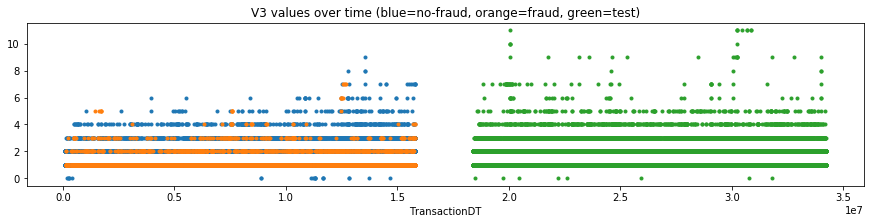

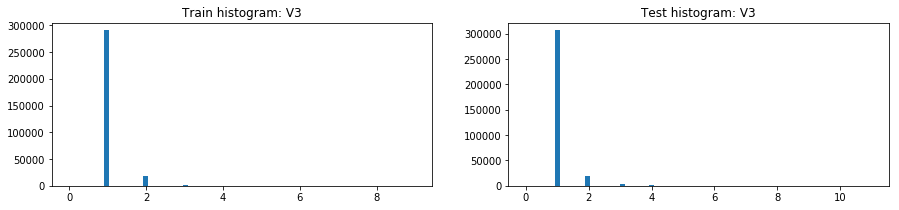

,V3,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,1.078075,1.189813,1.075839,1.087436,1.089180,1.086930
2,std,0.320890,0.541936,0.314484,0.359033,0.372204,0.355121
3,min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,9.000000,7.000000,9.000000,11.000000,11.000000,11.000000
8,unique values,11.000000,8.000000,11.000000,13.000000,12.000000,13.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V3,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,290583,0.018064,5249,306610
1,-999.0,279287,0.052122,14557,176518
2,2.0,17763,0.035523,631,19796
3,3.0,2335,0.077944,182,2797
4,4.0,403,0.062035,25,644
5,5.0,93,0.107527,10,200
6,6.0,34,0.147059,5,37
7,0.0,20,0.000000,0,8
8,7.0,18,0.222222,4,48
9,8.0,3,0.000000,0,4


,V3,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,290583,0.018064,5249,306610
2,2.0,17763,0.035523,631,19796
3,3.0,2335,0.077944,182,2797
4,4.0,403,0.062035,25,644
5,5.0,93,0.107527,10,200
6,6.0,34,0.147059,5,37
7,7.0,18,0.222222,4,48
8,0.0,20,0.000000,0,8
9,8.0,3,0.000000,0,4


,Column,Correlation with V3
0,V3,1.000000
1,V2,0.773039
2,V9,0.653087
3,V8,0.556536
4,V7,0.546875
5,V6,0.472570
168,D10,-0.053322
169,D5,-0.061979
170,D3,-0.062549
171,D11,-0.093579


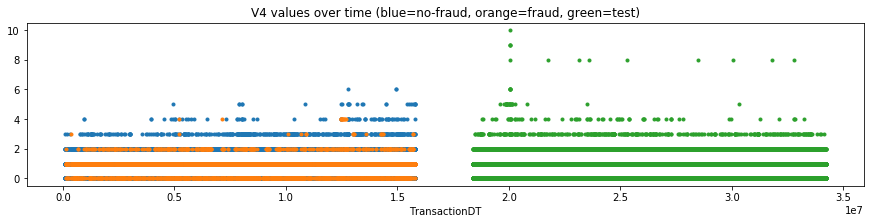

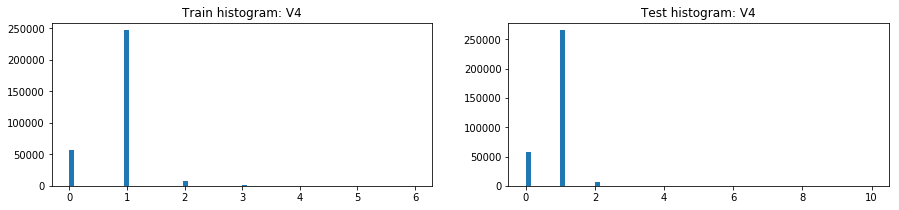

,V4,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,0.846456,0.885686,0.845671,0.850563,0.849768,0.850794
2,std,0.440053,0.504883,0.438623,0.427938,0.448183,0.421885
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,4.000000,6.000000,10.000000,10.000000,8.000000
8,unique values,8.000000,6.000000,8.000000,11.000000,11.000000,8.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V4,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,246500,0.018742,4620,265348
2,0.0,56687,0.019634,1113,57449
3,2.0,7385,0.046445,343,6851
4,3.0,564,0.031915,18,412
5,4.0,88,0.136364,12,67
6,5.0,26,0.000000,0,28
7,6.0,3,0.000000,0,5


,V4,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,246500,0.018742,4620,265348
2,0.0,56687,0.019634,1113,57449
3,2.0,7385,0.046445,343,6851
4,3.0,564,0.031915,18,412
5,4.0,88,0.136364,12,67
6,5.0,26,0.000000,0,28
7,6.0,3,0.000000,0,5


,Column,Correlation with V4
0,V4,1.000000
1,V5,0.915164
2,V82,0.683717
3,V83,0.629883
4,V61,0.606855
5,V19,0.606202
168,D2,-0.050060
169,D10,-0.053423
170,D15,-0.053686
171,D1,-0.073723


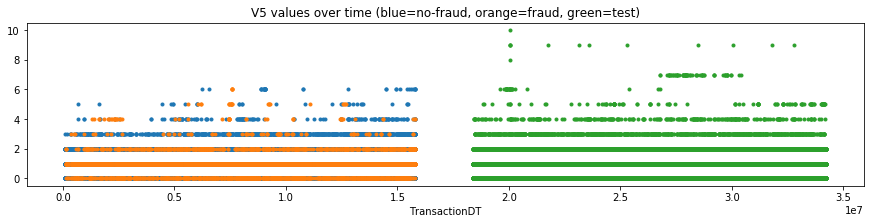

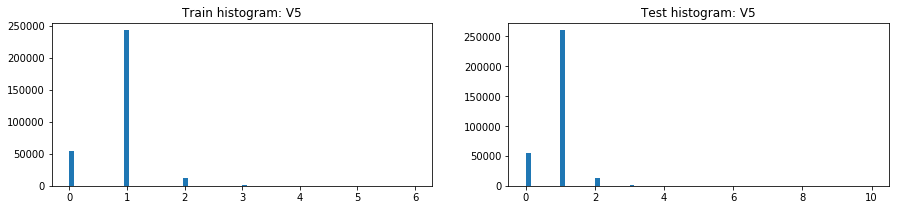

,V5,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,0.876991,1.001146,0.874506,0.884697,0.879930,0.886080
2,std,0.475902,0.665395,0.471002,0.483297,0.488099,0.481887
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,6.000000,6.000000,10.000000,10.000000,9.000000
8,unique values,8.000000,8.000000,8.000000,12.000000,11.000000,10.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V5,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,242883,0.018383,4465,259837
2,0.0,54276,0.017448,947,55494
3,2.0,12610,0.042902,541,13196
4,3.0,1200,0.063333,76,1137
5,4.0,193,0.264249,51,291
6,5.0,55,0.400000,22,111
7,6.0,36,0.111111,4,31


,V5,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,242883,0.018383,4465,259837
2,0.0,54276,0.017448,947,55494
3,2.0,12610,0.042902,541,13196
4,3.0,1200,0.063333,76,1137
5,4.0,193,0.264249,51,291
6,5.0,55,0.400000,22,111
7,6.0,36,0.111111,4,31


,Column,Correlation with V5
0,V5,1.000000
1,V4,0.915164
2,V83,0.658500
3,V82,0.634876
4,V62,0.588161
5,V20,0.583701
168,V69,-0.061584
169,V90,-0.063151
170,D1,-0.078982
171,D2,-0.082351


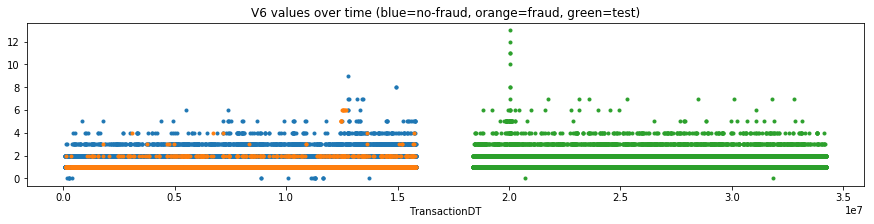

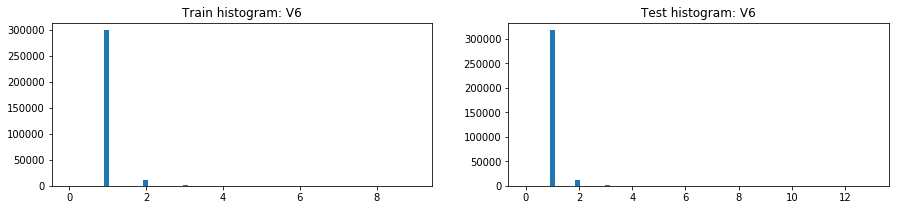

,V6,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,1.045686,1.063544,1.045329,1.045940,1.049776,1.044827
2,std,0.239385,0.310700,0.237727,0.244112,0.272326,0.235285
3,min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,9.000000,6.000000,9.000000,13.000000,13.000000,7.000000
8,unique values,11.000000,7.000000,11.000000,14.000000,14.000000,9.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V6,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,298627,0.019349,5778,316806.0
1,-999.0,279287,0.052122,14557,176518.0
2,2.0,11319,0.026416,299,12027.0
3,3.0,1044,0.013410,14,1023.0
4,4.0,180,0.027778,5,235.0
5,5.0,46,0.086957,4,48.0
6,0.0,18,0.000000,0,2.0
7,6.0,11,0.545455,6,16.0
8,7.0,5,0.000000,0,9.0
9,8.0,2,0.000000,0,2.0


,V6,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,298627,0.019349,5778,316806
2,2.0,11319,0.026416,299,12027
3,3.0,1044,0.013410,14,1023
4,6.0,11,0.545455,6,16
5,4.0,180,0.027778,5,235
6,5.0,46,0.086957,4,48
7,0.0,18,0.000000,0,2
8,7.0,5,0.000000,0,9
9,8.0,2,0.000000,0,2


,Column,Correlation with V6
0,V6,1.000000
1,V7,0.796027
2,V8,0.675501
3,V2,0.621459
4,V9,0.561332
5,V3,0.472570
168,D15,-0.020571
169,D1,-0.023724
170,D2,-0.028983
171,D5,-0.042234


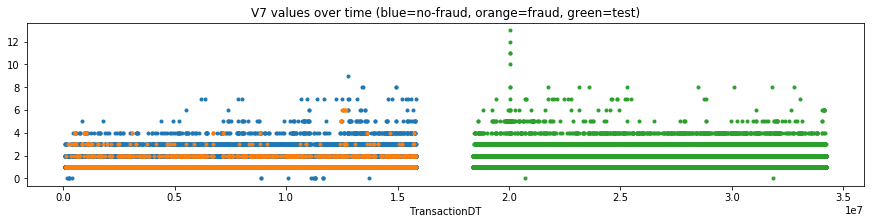

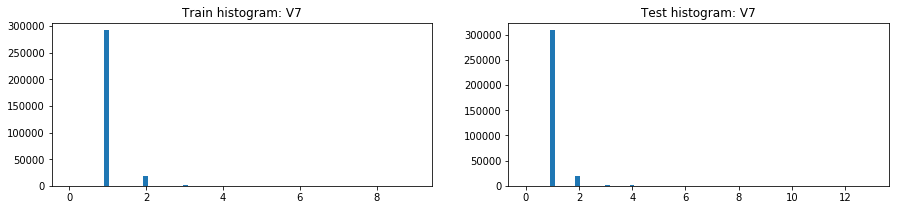

,V7,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,1.072870,1.123485,1.071857,1.079207,1.081690,1.078487
2,std,0.304779,0.413311,0.302124,0.330086,0.354006,0.322814
3,min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,9.000000,6.000000,9.000000,13.000000,13.000000,8.000000
8,unique values,11.000000,7.000000,11.000000,14.000000,14.000000,10.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V7,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,291485,0.018807,5482,308215.0
1,-999.0,279287,0.052122,14557,176518.0
2,2.0,17464,0.030520,533,18901.0
3,3.0,1823,0.037301,68,2243.0
4,4.0,337,0.038576,13,613.0
5,5.0,83,0.048193,4,136.0
6,7.0,20,0.000000,0,22.0
7,0.0,18,0.000000,0,2.0
8,6.0,18,0.333333,6,26.0
9,8.0,4,0.000000,0,10.0


,V7,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,291485,0.018807,5482,308215
2,2.0,17464,0.030520,533,18901
3,3.0,1823,0.037301,68,2243
4,4.0,337,0.038576,13,613
5,6.0,18,0.333333,6,26
6,5.0,83,0.048193,4,136
7,7.0,20,0.000000,0,22
8,0.0,18,0.000000,0,2
9,8.0,4,0.000000,0,10


,Column,Correlation with V7
0,V7,1.000000
1,V6,0.796027
2,V9,0.594988
3,V3,0.546875
4,V8,0.538586
5,V2,0.496921
168,D1,-0.032126
169,V48,-0.032210
170,D2,-0.057308
171,D5,-0.060725


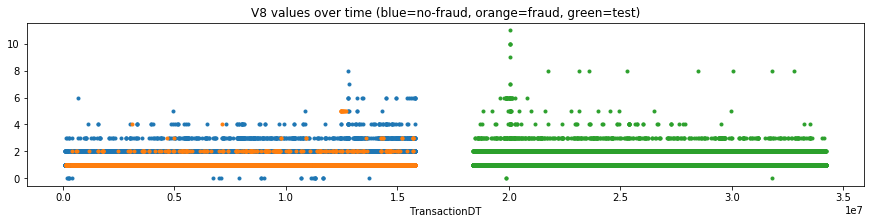

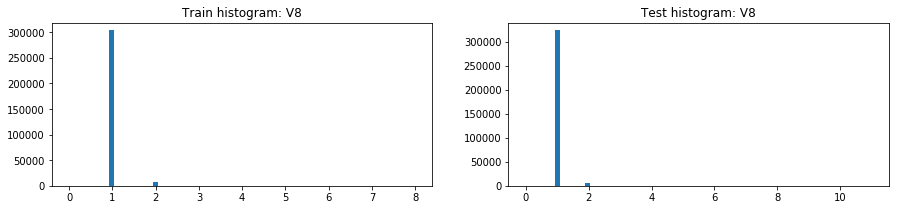

,V8,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,1.027704,1.048804,1.027282,1.022779,1.028829,1.021024
2,std,0.186069,0.271332,0.183936,0.174533,0.221694,0.158205
3,min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,8.000000,5.000000,8.000000,11.000000,11.000000,8.000000
8,unique values,10.000000,6.000000,10.000000,13.000000,13.000000,8.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V8,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,303466,0.019307,5859,323436
1,-999.0,279287,0.052122,14557,176518
2,2.0,7076,0.030808,218,6206
3,3.0,553,0.030741,17,408
4,4.0,95,0.021053,2,58
5,0.0,24,0.000000,0,3
6,6.0,19,0.000000,0,27
7,5.0,18,0.555556,10,20
8,7.0,1,0.000000,0,2
9,8.0,1,0.000000,0,8


,V8,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,303466,0.019307,5859,323436
2,2.0,7076,0.030808,218,6206
3,3.0,553,0.030741,17,408
4,5.0,18,0.555556,10,20
5,4.0,95,0.021053,2,58
6,0.0,24,0.000000,0,3
7,6.0,19,0.000000,0,27
8,7.0,1,0.000000,0,2
9,8.0,1,0.000000,0,8


,Column,Correlation with V8
0,V8,1.000000
1,V9,0.835342
2,V2,0.732730
3,V6,0.675501
4,V3,0.556536
5,V7,0.538586
168,D10,-0.019761
169,D1,-0.022786
170,D15,-0.024336
171,D2,-0.038912


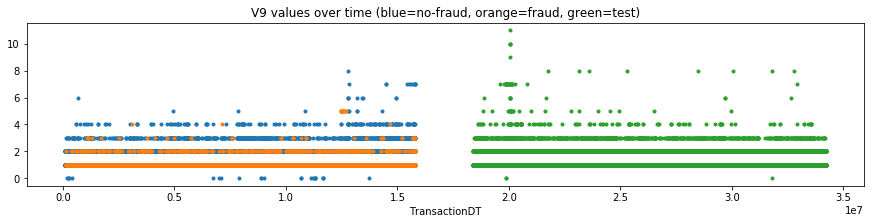

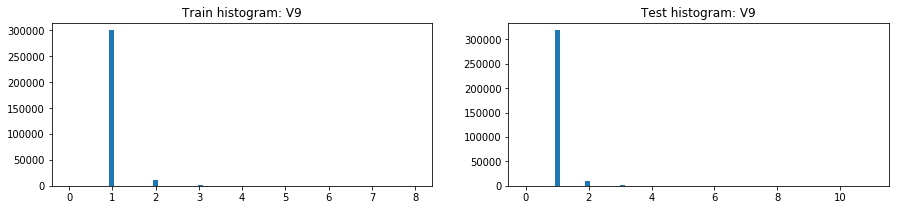

,V9,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,1.041529,1.102195,1.040315,1.039876,1.045008,1.038388
2,std,0.226339,0.356576,0.222790,0.226182,0.271224,0.211306
3,min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,8.000000,5.000000,8.000000,11.000000,11.000000,8.000000
8,unique values,10.000000,6.000000,10.000000,13.000000,13.000000,10.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V9,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,299625,0.018547,5557,318347
1,-999.0,279287,0.052122,14557,176518
2,2.0,10544,0.047136,497,10859
3,3.0,848,0.045991,39,765
4,4.0,172,0.017442,3,126
5,0.0,24,0.000000,0,3
6,5.0,19,0.526316,10,25
7,7.0,11,0.000000,0,26
8,6.0,9,0.000000,0,9
9,8.0,1,0.000000,0,8


,V9,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,1.0,299625,0.018547,5557,318347
2,2.0,10544,0.047136,497,10859
3,3.0,848,0.045991,39,765
4,5.0,19,0.526316,10,25
5,4.0,172,0.017442,3,126
6,0.0,24,0.000000,0,3
7,7.0,11,0.000000,0,26
8,6.0,9,0.000000,0,9
9,8.0,1,0.000000,0,8


,Column,Correlation with V9
0,V9,1.000000
1,V8,0.835342
2,V3,0.653087
3,V2,0.618591
4,V7,0.594988
5,V6,0.561332
168,D5,-0.031726
169,D3,-0.032873
170,D15,-0.033050
171,D2,-0.060890


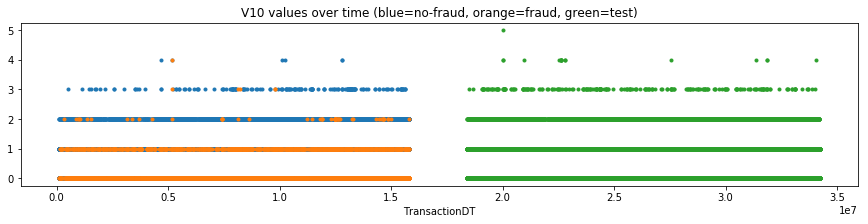

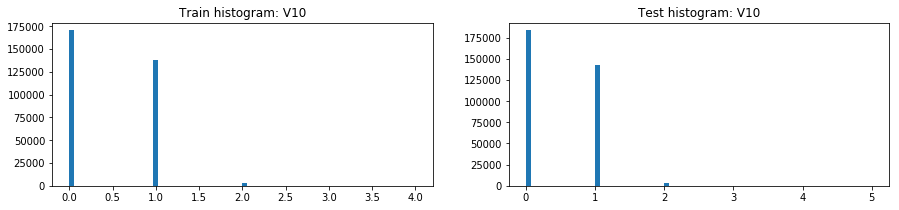

,V10,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,0.463915,0.188667,0.469423,0.456621,0.458010,0.456217
2,std,0.521522,0.421117,0.521856,0.523406,0.525272,0.522864
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000
8,unique values,6.000000,6.000000,6.000000,7.000000,7.000000,6.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V10,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,279287,0.052122,14557,176518
1,0.0,170281,0.029481,5020,183374
2,1.0,137743,0.007456,1027,143115
3,2.0,3042,0.017423,53,3421
4,3.0,180,0.027778,5,246
5,4.0,7,0.142857,1,16


,V10,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,0.0,170281,0.029481,5020,183374
2,1.0,137743,0.007456,1027,143115
3,2.0,3042,0.017423,53,3421
4,3.0,180,0.027778,5,246
5,4.0,7,0.142857,1,16


,Column,Correlation with V10
0,V10,1.000000
1,V11,0.968670
2,V90,0.907758
3,V48,0.893391
4,V69,0.883022
5,V29,0.879585
168,V283,-0.139100
169,V287,-0.145584
170,V97,-0.147457
171,V280,-0.156717


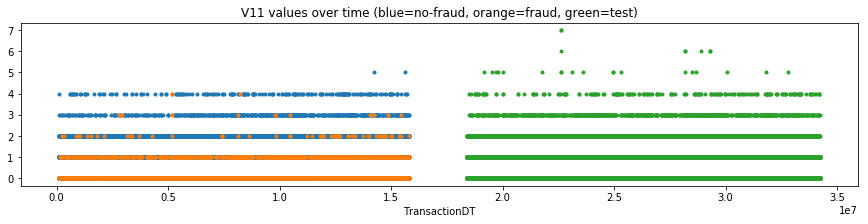

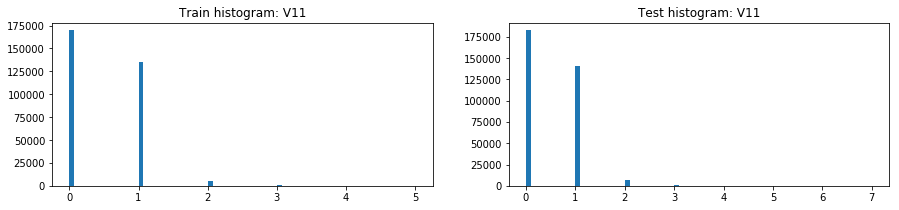

,V11,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,311253.000000,6106.000000,305147.000000,330173.000000,74232.000000,255942.000000
1,mean,0.478987,0.198002,0.484609,0.473873,0.473677,0.473928
2,std,0.552431,0.447692,0.552870,0.558754,0.556013,0.559548
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,4.000000,5.000000,7.000000,5.000000,7.000000
8,unique values,7.000000,6.000000,7.000000,9.000000,7.000000,9.000000
9,NaNs,279287.000000,14557.000000,264730.000000,176518.000000,27107.000000,149411.000000


,V11,Count in train (desc),Mean target,Sum target,Count in test
0,-999.0,279287,0.052122,14557,176518
1,0.0,169633,0.029511,5006,182449
2,1.0,135148,0.007451,1007,140332
3,2.0,5672,0.013928,79,6301
4,3.0,608,0.019737,12,875
5,4.0,190,0.010526,2,189
6,5.0,2,0.000000,0,19


,V11,Count in train,Mean target,Sum target (desc),Count in test
0,-999.0,279287,0.052122,14557,176518
1,0.0,169633,0.029511,5006,182449
2,1.0,135148,0.007451,1007,140332
3,2.0,5672,0.013928,79,6301
4,3.0,608,0.019737,12,875
5,4.0,190,0.010526,2,189
6,5.0,2,0.000000,0,19


,Column,Correlation with V11
0,V11,1.000000
1,V10,0.968670
2,V90,0.887701
3,V91,0.884841
4,V48,0.870965
5,V49,0.865761
168,V283,-0.127174
169,V97,-0.132162
170,V74,-0.132237
171,V280,-0.141385


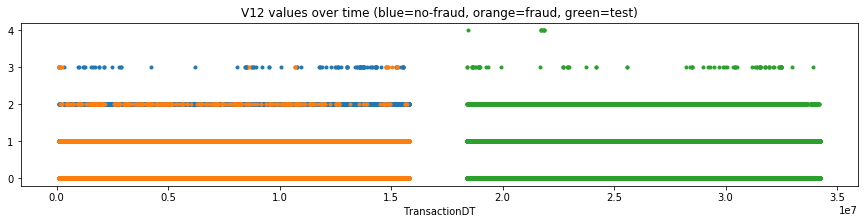

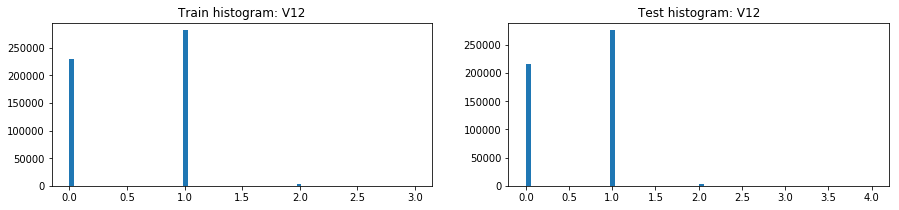

,V12,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.559711,0.413984,0.564623,0.569816,0.664277,0.547655
2,std,0.510533,0.548667,0.508471,0.508138,0.489000,0.509998
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000
8,unique values,5.000000,5.000000,5.000000,6.000000,6.000000,6.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V12,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,281003,0.021420,6019,275401
1,0.0,230049,0.044786,10303,215678
2,-999.0,76073,0.051096,3887,12589
3,2.0,3295,0.132322,436,2931
4,3.0,120,0.150000,18,84


,V12,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,230049,0.044786,10303,215678
1,1.0,281003,0.021420,6019,275401
2,-999.0,76073,0.051096,3887,12589
3,2.0,3295,0.132322,436,2931
4,3.0,120,0.150000,18,84


,Column,Correlation with V12
0,V12,1.000000
1,V13,0.925848
2,V75,0.708756
3,V76,0.671624
4,V35,0.659987
5,V53,0.635155
208,V32,-0.423963
209,V42,-0.433017
210,V31,-0.433737
211,V92,-0.435111


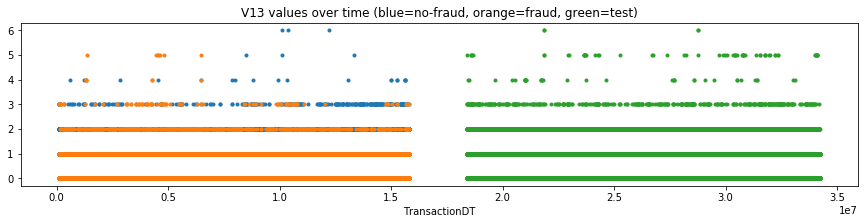

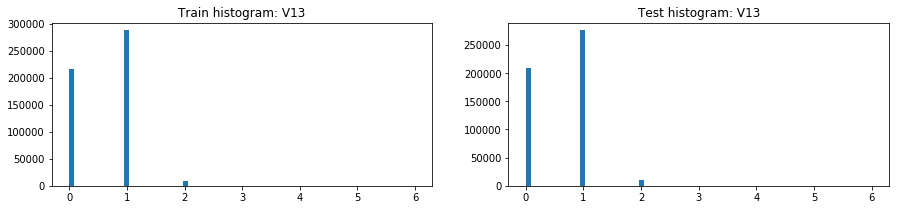

,V13,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.599166,0.466679,0.603632,0.600435,0.701014,0.576839
2,std,0.532185,0.619955,0.528395,0.536276,0.513543,0.538759
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000
8,unique values,8.000000,7.000000,8.000000,8.000000,7.000000,8.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V13,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,287644,0.020890,6009,275677
1,0.0,216752,0.045780,9923,208273
2,-999.0,76073,0.051096,3887,12589
3,2.0,9661,0.075872,733,9623
4,3.0,371,0.261456,97,430
5,4.0,26,0.269231,7,36
6,5.0,10,0.700000,7,59
7,6.0,3,0.000000,0,4


,V13,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,216752,0.045780,9923,208273
1,1.0,287644,0.020890,6009,275677
2,-999.0,76073,0.051096,3887,12589
3,2.0,9661,0.075872,733,9623
4,3.0,371,0.261456,97,430
5,4.0,26,0.269231,7,36
6,5.0,10,0.700000,7,59
7,6.0,3,0.000000,0,4


,Column,Correlation with V13
0,V13,1.000000
1,V12,0.925848
2,V76,0.719616
3,V75,0.670498
4,V36,0.669024
5,V54,0.643723
208,V32,-0.435384
209,V42,-0.444288
210,V31,-0.445421
211,V92,-0.447115


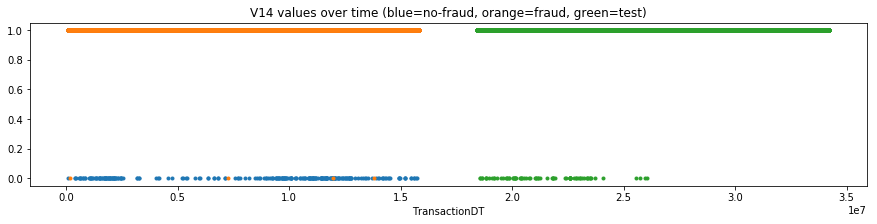

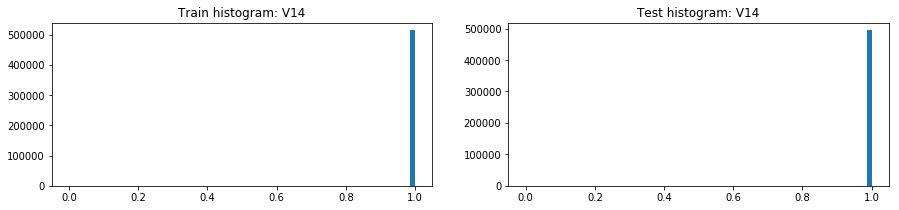

,V14,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.999500,0.999762,0.999492,0.999846,0.999553,0.999915
2,std,0.022345,0.015440,0.022541,0.012401,0.021146,0.009217
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,unique values,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V14,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,514210,0.032617,16772,494026
1,-999.0,76073,0.051096,3887,12589
2,0.0,257,0.015564,4,76


,V14,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,514210,0.032617,16772,494026
1,-999.0,76073,0.051096,3887,12589
2,0.0,257,0.015564,4,76


,Column,Correlation with V14
0,V14,1.000000
1,V41,0.880084
2,V65,0.844338
3,V88,0.834647
4,V25,0.117988
5,V46,0.115513
361,V155,-0.066411
362,V148,-0.066795
363,V154,-0.067373
364,V153,-0.068208


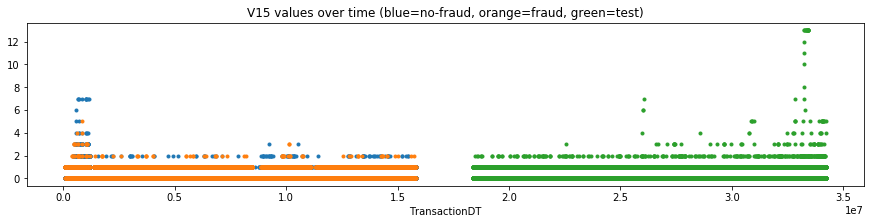

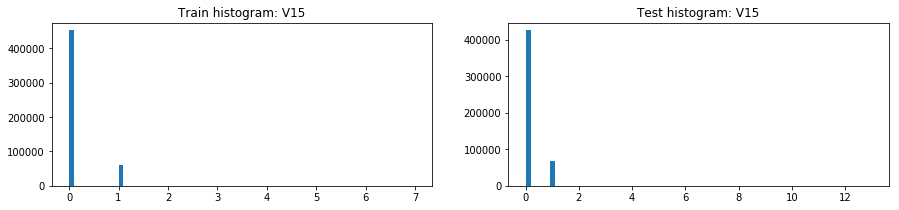

,V15,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.122342,0.444564,0.111481,0.140963,0.104853,0.149433
2,std,0.332422,0.514612,0.318881,0.361034,0.307926,0.371890
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,7.000000,5.000000,7.000000,13.000000,2.000000,13.000000
8,unique values,9.000000,7.000000,9.000000,14.000000,4.000000,14.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V15,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,452075,0.020886,9442,425298
1,-999.0,76073,0.051096,3887,12589
2,1.0,61974,0.116678,7231,68326
3,2.0,346,0.248555,86,365
4,3.0,48,0.291667,14,53
5,4.0,10,0.200000,2,15
6,7.0,10,0.000000,0,3
7,5.0,3,0.333333,1,20
8,6.0,1,0.000000,0,3


,V15,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,452075,0.020886,9442,425298
1,1.0,61974,0.116678,7231,68326
2,-999.0,76073,0.051096,3887,12589
3,2.0,346,0.248555,86,365
4,3.0,48,0.291667,14,53
5,4.0,10,0.200000,2,15
6,5.0,3,0.333333,1,20
7,7.0,10,0.000000,0,3
8,6.0,1,0.000000,0,3


,Column,Correlation with V15
0,V15,1.000000
1,V16,0.986727
2,V57,0.958967
3,V33,0.958773
4,V94,0.953582
5,V50,0.946630
315,V53,-0.418216
316,V54,-0.429701
317,V35,-0.440371
318,V36,-0.450111


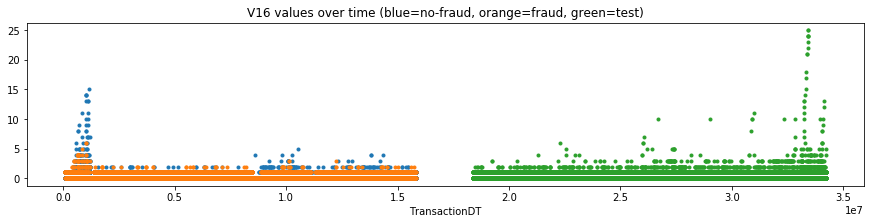

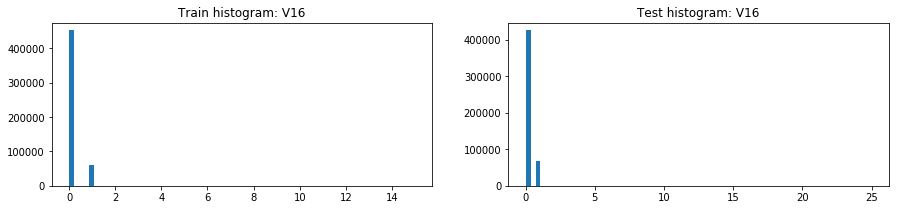

,V16,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.123460,0.448975,0.112487,0.142317,0.104991,0.151072
2,std,0.342841,0.530912,0.329104,0.379262,0.308725,0.393472
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,15.000000,6.000000,15.000000,25.000000,4.000000,25.000000
8,unique values,16.000000,8.000000,16.000000,24.000000,6.000000,24.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V16,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,452052,0.020887,9442,425270
1,-999.0,76073,0.051096,3887,12589
2,1.0,61749,0.116569,7198,68099
3,2.0,481,0.199584,96,476
4,3.0,101,0.227723,23,156
5,4.0,42,0.333333,14,37
6,5.0,12,0.083333,1,20
7,6.0,7,0.285714,2,7
8,7.0,5,0.000000,0,3
9,8.0,4,0.000000,0,4


,V16,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,452052,0.020887,9442,425270
1,1.0,61749,0.116569,7198,68099
2,-999.0,76073,0.051096,3887,12589
3,2.0,481,0.199584,96,476
4,3.0,101,0.227723,23,156
5,4.0,42,0.333333,14,37
6,6.0,7,0.285714,2,7
7,5.0,12,0.083333,1,20
8,7.0,5,0.000000,0,3
9,8.0,4,0.000000,0,4


,Column,Correlation with V16
0,V16,1.000000
1,V15,0.986727
2,V33,0.943636
3,V57,0.938881
4,V94,0.933000
5,V34,0.931086
315,V53,-0.409196
316,V54,-0.420433
317,V35,-0.430572
318,V36,-0.440095


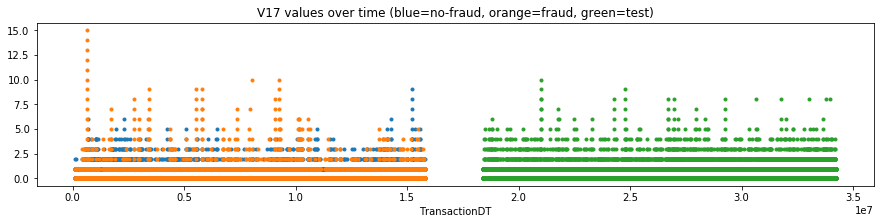

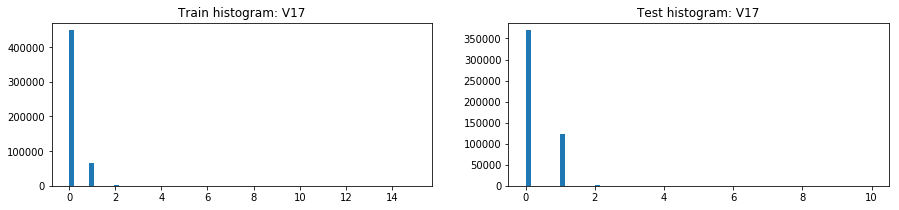

,V17,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.134040,0.496662,0.121817,0.259778,0.121107,0.292307
2,std,0.364456,0.738461,0.338147,0.461083,0.357741,0.476318
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,15.000000,15.000000,9.000000,10.000000,10.000000,9.000000
8,unique values,17.000000,17.000000,11.000000,12.000000,12.000000,11.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V17,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,447823,0.021086,9443,369022.0
1,-999.0,76073,0.051096,3887,12589.0
2,1.0,65244,0.105634,6892,122807.0
3,2.0,927,0.237325,220,1676.0
4,3.0,274,0.346715,95,365.0
5,4.0,104,0.480769,50,143.0
6,5.0,40,0.700000,28,46.0
7,6.0,21,0.809524,17,19.0
8,7.0,12,0.916667,11,9.0
9,8.0,8,0.875000,7,12.0


,V17,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,447823,0.021086,9443,369022
1,1.0,65244,0.105634,6892,122807
2,-999.0,76073,0.051096,3887,12589
3,2.0,927,0.237325,220,1676
4,3.0,274,0.346715,95,365
5,4.0,104,0.480769,50,143
6,5.0,40,0.700000,28,46
7,6.0,21,0.809524,17,19
8,7.0,12,0.916667,11,9
9,8.0,8,0.875000,7,12


,Column,Correlation with V17
0,V17,1.000000
1,V18,0.991474
2,V21,0.951809
3,V22,0.917938
4,V84,0.909163
5,V63,0.906180
362,V12,-0.403208
363,V35,-0.409374
364,V54,-0.412949
365,V13,-0.414069


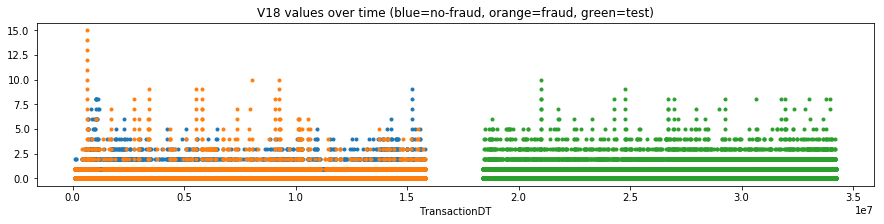

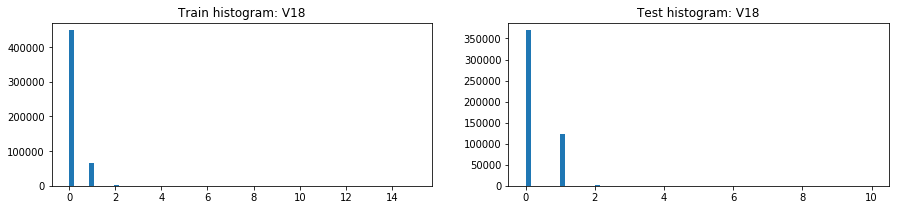

,V18,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.135363,0.505007,0.122904,0.261657,0.121959,0.294426
2,std,0.371763,0.755766,0.344751,0.467456,0.362981,0.482925
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,15.000000,15.000000,9.000000,10.000000,10.000000,9.000000
8,unique values,17.000000,17.000000,11.000000,12.000000,12.000000,11.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V18,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,447792,0.021083,9441,368966.0
1,-999.0,76073,0.051096,3887,12589.0
2,1.0,64889,0.105087,6819,122201.0
3,2.0,1155,0.208658,241,2216.0
4,3.0,388,0.373711,145,443.0
5,4.0,120,0.425000,51,160.0
6,5.0,48,0.604167,29,64.0
7,6.0,32,0.593750,19,21.0
8,7.0,16,0.687500,11,15.0
9,8.0,13,0.538462,7,13.0


,V18,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,447792,0.021083,9441,368966
1,1.0,64889,0.105087,6819,122201
2,-999.0,76073,0.051096,3887,12589
3,2.0,1155,0.208658,241,2216
4,3.0,388,0.373711,145,443
5,4.0,120,0.425000,51,160
6,5.0,48,0.604167,29,64
7,6.0,32,0.593750,19,21
8,7.0,16,0.687500,11,15
9,8.0,13,0.538462,7,13


,Column,Correlation with V18
0,V18,1.000000
1,V17,0.991474
2,V21,0.944754
3,V22,0.927913
4,V84,0.899788
5,V63,0.898337
362,V12,-0.399186
363,V35,-0.405973
364,V54,-0.409579
365,V13,-0.409940


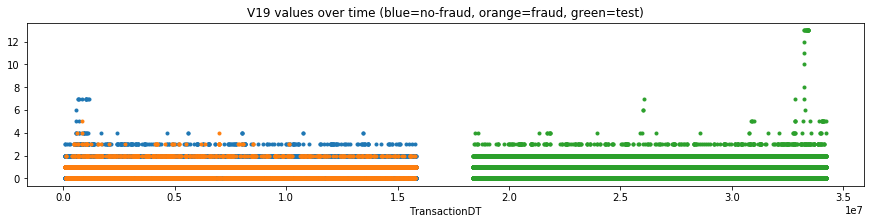

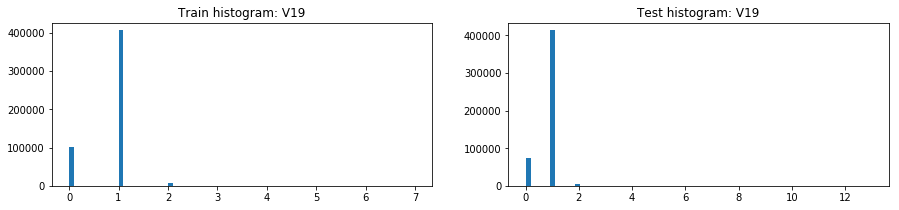

,V19,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.00000
1,mean,0.816371,0.887995,0.813957,0.861490,0.832037,0.86840
2,std,0.425512,0.429226,0.425176,0.392307,0.408003,0.38821
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
7,max,7.000000,5.000000,7.000000,13.000000,4.000000,13.00000
8,unique values,9.000000,7.000000,9.000000,14.000000,6.000000,14.00000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.00000


,V19,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,405665,0.033705,13673,412869
1,0.0,101871,0.024757,2522,75188
2,-999.0,76073,0.051096,3887,12589
3,2.0,6540,0.080122,524,5611
4,3.0,348,0.152299,53,358
5,4.0,29,0.103448,3,31
6,7.0,10,0.000000,0,3
7,5.0,3,0.333333,1,20
8,6.0,1,0.000000,0,3


,V19,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,405665,0.033705,13673,412869
1,-999.0,76073,0.051096,3887,12589
2,0.0,101871,0.024757,2522,75188
3,2.0,6540,0.080122,524,5611
4,3.0,348,0.152299,53,358
5,4.0,29,0.103448,3,31
6,5.0,3,0.333333,1,20
7,7.0,10,0.000000,0,3
8,6.0,1,0.000000,0,3


,Column,Correlation with V19
0,V19,1.000000
1,V20,0.905334
2,V82,0.722277
3,V61,0.682139
4,V83,0.644119
5,V62,0.615758
375,V183,-0.419397
376,V329,-0.431263
377,V330,-0.438646
378,V327,-0.517675


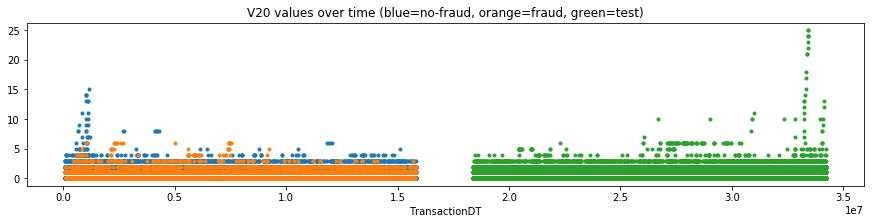

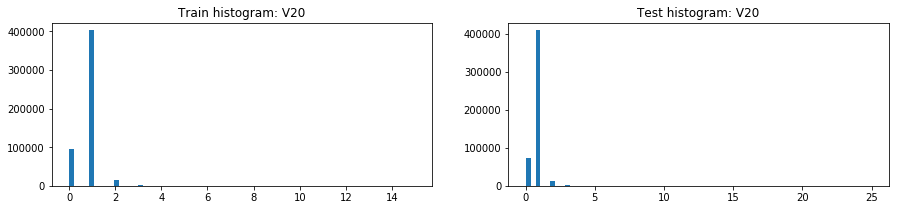

,V20,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.00000,494102.000000,93884.000000,400219.000000
1,mean,0.847843,0.948796,0.84444,0.885503,0.857398,0.892097
2,std,0.459451,0.525761,0.45666,0.436220,0.435610,0.436101
3,min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
7,max,15.000000,6.000000,15.00000,25.000000,5.000000,25.000000
8,unique values,16.000000,8.000000,16.00000,24.000000,7.000000,24.000000
9,NaNs,76073.000000,3887.000000,72186.00000,12589.000000,7455.000000,5134.000000


,V20,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,401929,0.033501,13465,407937
1,0.0,96318,0.023402,2254,72522
2,-999.0,76073,0.051096,3887,12589
3,2.0,14902,0.055831,832,12171
4,3.0,1070,0.148598,159,1199
5,4.0,161,0.229814,37,111
6,5.0,30,0.366667,11,51
7,6.0,27,0.666667,18,74
8,8.0,11,0.000000,0,4
9,7.0,5,0.000000,0,3


,V20,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,401929,0.033501,13465,407937
1,-999.0,76073,0.051096,3887,12589
2,0.0,96318,0.023402,2254,72522
3,2.0,14902,0.055831,832,12171
4,3.0,1070,0.148598,159,1199
5,4.0,161,0.229814,37,111
6,6.0,27,0.666667,18,74
7,5.0,30,0.366667,11,51
8,8.0,11,0.000000,0,4
9,7.0,5,0.000000,0,3


,Column,Correlation with V20
0,V20,1.000000
1,V19,0.905334
2,V83,0.674453
3,V82,0.661167
4,V62,0.633815
5,V61,0.632256
375,V328,-0.413837
376,V329,-0.427671
377,V330,-0.435053
378,V327,-0.512131


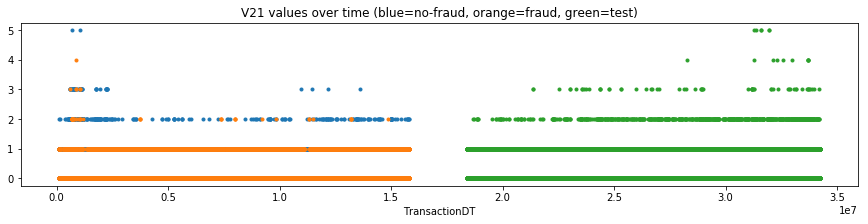

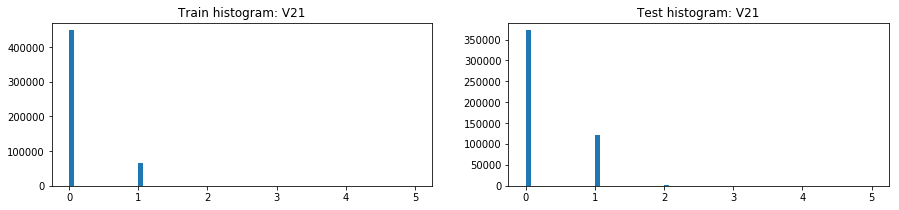

,V21,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.129684,0.436218,0.119351,0.249799,0.114652,0.281501
2,std,0.339060,0.502972,0.327163,0.438383,0.320138,0.455994
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
7,max,5.000000,4.000000,5.000000,5.000000,3.000000,5.000000
8,unique values,7.000000,6.000000,6.000000,7.000000,5.000000,7.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V21,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,448220,0.021215,9509,371730
1,-999.0,76073,0.051096,3887,12589
2,1.0,65837,0.109710,7223,121417
3,2.0,354,0.107345,38,878
4,3.0,53,0.094340,5,61
5,5.0,2,0.000000,0,6
6,4.0,1,1.000000,1,10


,V21,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,448220,0.021215,9509,371730
1,1.0,65837,0.109710,7223,121417
2,-999.0,76073,0.051096,3887,12589
3,2.0,354,0.107345,38,878
4,3.0,53,0.094340,5,61
5,4.0,1,1.000000,1,10
6,5.0,2,0.000000,0,6


,Column,Correlation with V21
0,V21,1.000000
1,V22,0.964627
2,V84,0.955048
3,V17,0.951809
4,V63,0.946929
5,V18,0.944754
362,V12,-0.419325
363,V35,-0.428535
364,V54,-0.429660
365,V13,-0.430620


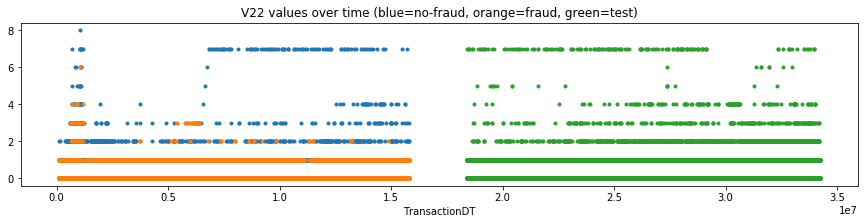

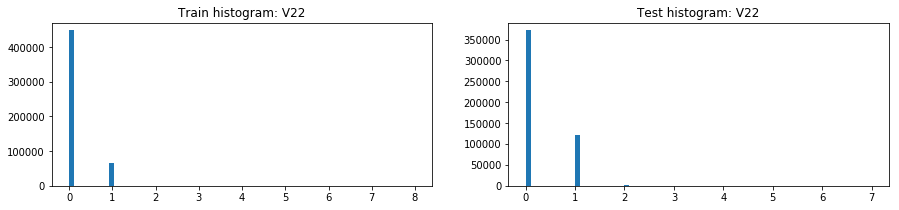

,V22,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.132292,0.443193,0.121813,0.254431,0.117752,0.286493
2,std,0.359415,0.525582,0.347641,0.464469,0.350313,0.481809
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
7,max,8.000000,6.000000,8.000000,7.000000,7.000000,7.000000
8,unique values,10.000000,7.000000,10.000000,9.000000,8.000000,9.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V22,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,448185,0.021212,9507,371688.0
1,-999.0,76073,0.051096,3887,12589.0
2,1.0,65334,0.109698,7167,120501.0
3,2.0,604,0.081126,49,1334.0
4,3.0,169,0.272189,46,249.0
5,7.0,94,0.000000,0,149.0
6,4.0,63,0.079365,5,157.0
7,5.0,9,0.000000,0,16.0
8,6.0,8,0.250000,2,8.0
9,8.0,1,0.000000,0,NaN


,V22,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,448185,0.021212,9507,371688.0
1,1.0,65334,0.109698,7167,120501.0
2,-999.0,76073,0.051096,3887,12589.0
3,2.0,604,0.081126,49,1334.0
4,3.0,169,0.272189,46,249.0
5,4.0,63,0.079365,5,157.0
6,6.0,8,0.250000,2,8.0
7,7.0,94,0.000000,0,149.0
8,5.0,9,0.000000,0,16.0
9,8.0,1,0.000000,0,NaN


,Column,Correlation with V22
0,V22,1.000000
1,V21,0.964627
2,V42,0.934389
3,V18,0.927913
4,V63,0.920913
5,V17,0.917938
362,V12,-0.403534
363,V54,-0.414303
364,V13,-0.414404
365,V35,-0.424245


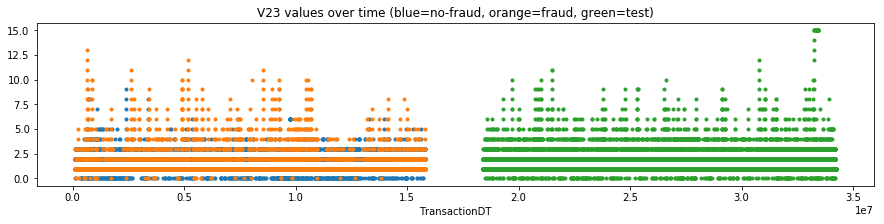

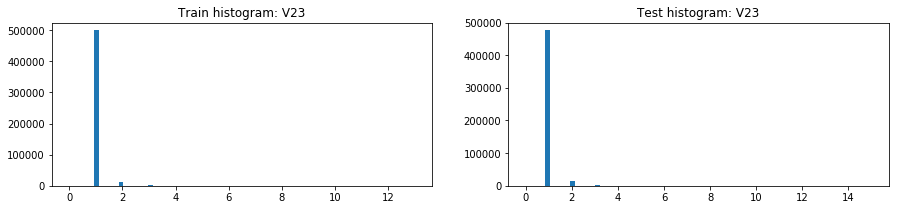

,V23,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,1.034791,1.236350,1.027997,1.045493,1.046323,1.045298
2,std,0.247681,0.860107,0.192518,0.289516,0.294012,0.288451
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,13.000000,13.000000,9.000000,15.000000,11.000000,15.000000
8,unique values,15.000000,15.000000,11.000000,17.000000,13.000000,17.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V23,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,498764,0.029483,14705,475616
1,-999.0,76073,0.051096,3887,12589
2,2.0,13197,0.087747,1158,15463
3,3.0,1244,0.313505,390,1622
4,0.0,588,0.085034,50,367
5,4.0,337,0.599407,202,615
6,5.0,144,0.777778,112,186
7,6.0,83,0.734940,61,94
8,7.0,39,0.897436,35,61
9,8.0,32,0.812500,26,29


,V23,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,498764,0.029483,14705,475616
1,-999.0,76073,0.051096,3887,12589
2,2.0,13197,0.087747,1158,15463
3,3.0,1244,0.313505,390,1622
4,4.0,337,0.599407,202,615
5,5.0,144,0.777778,112,186
6,6.0,83,0.734940,61,94
7,0.0,588,0.085034,50,367
8,7.0,39,0.897436,35,61
9,8.0,32,0.812500,26,29


,Column,Correlation with V23
0,V23,1.000000
1,V24,0.824955
2,V123,0.612617
3,V125,0.500739
4,V86,0.452366
5,V257,0.400885
375,D8,-0.073936
376,V292,-0.080453
377,addr2,-0.080754
378,V291,-0.083794


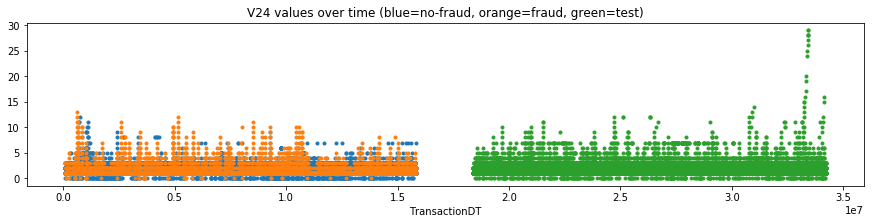

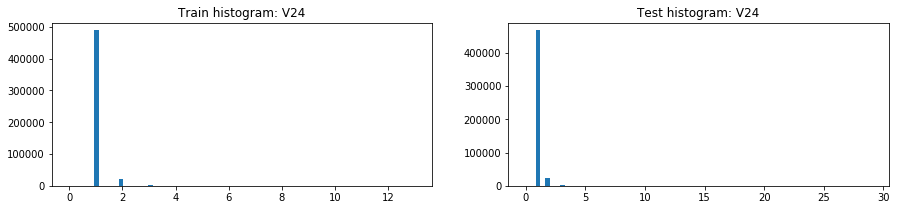

,V24,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,1.058097,1.264127,1.051152,1.069415,1.070683,1.069117
2,std,0.305485,0.889503,0.261379,0.371149,0.350795,0.375764
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,13.000000,13.000000,12.000000,29.000000,11.000000,29.000000
8,unique values,15.000000,15.000000,14.000000,27.000000,13.000000,27.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V24,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,488478,0.029428,14375,466502
1,-999.0,76073,0.051096,3887,12589
2,2.0,22289,0.063664,1419,23104
3,3.0,2241,0.196787,441,2803
4,0.0,578,0.083045,48,364
5,4.0,431,0.496520,214,642
6,5.0,195,0.558974,109,246
7,6.0,98,0.653061,64,110
8,7.0,64,0.593750,38,218
9,8.0,40,0.650000,26,32


,V24,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,488478,0.029428,14375,466502
1,-999.0,76073,0.051096,3887,12589
2,2.0,22289,0.063664,1419,23104
3,3.0,2241,0.196787,441,2803
4,4.0,431,0.496520,214,642
5,5.0,195,0.558974,109,246
6,6.0,98,0.653061,64,110
7,0.0,578,0.083045,48,364
8,7.0,64,0.593750,38,218
9,8.0,40,0.650000,26,32


,Column,Correlation with V24
0,V24,1.000000
1,V23,0.824955
2,V123,0.532372
3,V125,0.486519
4,V87,0.426118
5,V124,0.405436
375,D5,-0.065159
376,V292,-0.065559
377,V291,-0.068306
378,D7,-0.081289


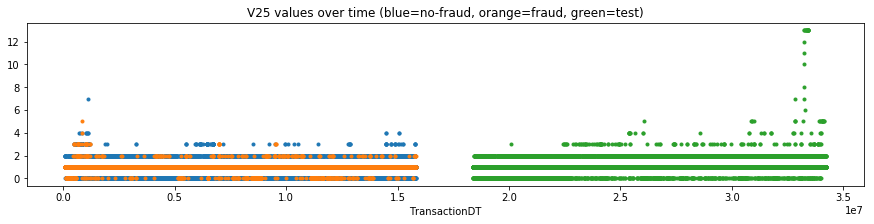

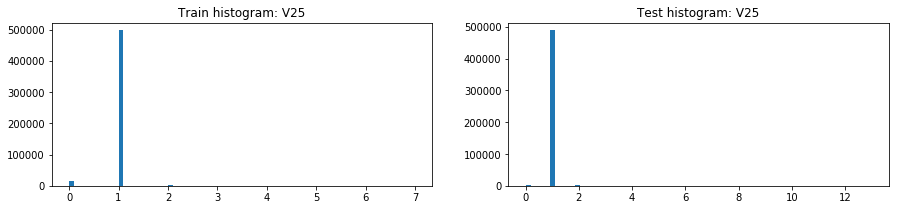

,V25,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.977660,0.981521,0.977530,1.004693,0.996283,1.006666
2,std,0.185245,0.235744,0.183299,0.133895,0.127897,0.135187
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,7.000000,5.000000,7.000000,13.000000,3.000000,13.000000
8,unique values,8.000000,7.000000,7.000000,14.000000,5.000000,14.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V25,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,497241,0.032091,15957,488731
1,-999.0,76073,0.051096,3887,12589
2,0.0,14465,0.040304,583,1754
3,2.0,2569,0.078630,202,3420
4,3.0,177,0.180791,32,127
5,4.0,13,0.076923,1,27
6,5.0,1,1.000000,1,21
7,7.0,1,0.000000,0,2


,V25,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,497241,0.032091,15957,488731
1,-999.0,76073,0.051096,3887,12589
2,0.0,14465,0.040304,583,1754
3,2.0,2569,0.078630,202,3420
4,3.0,177,0.180791,32,127
5,4.0,13,0.076923,1,27
6,5.0,1,1.000000,1,21
7,7.0,1,0.000000,0,2


,Column,Correlation with V25
0,V25,1.000000
1,V26,0.840105
2,V66,0.556169
3,V67,0.466775
4,V19,0.329342
5,V20,0.295004
375,V90,-0.030490
376,D7,-0.035907
377,D14,-0.036052
378,addr2,-0.042292


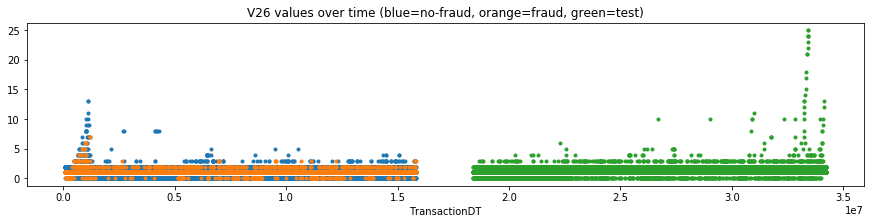

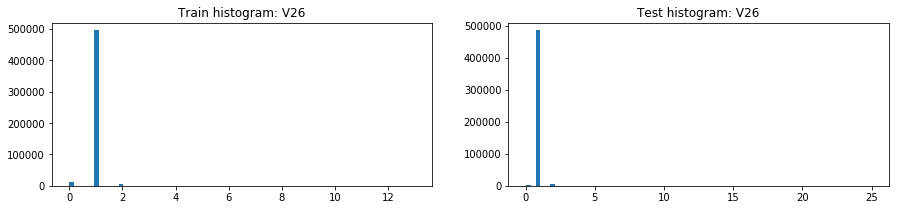

,V26,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.988040,1.006199,0.987428,1.012959,1.004058,1.015047
2,std,0.209302,0.289442,0.206031,0.189354,0.148397,0.197679
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,13.000000,7.000000,13.000000,25.000000,4.000000,25.000000
8,unique values,14.000000,9.000000,14.000000,24.000000,6.000000,24.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V26,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,495119,0.031802,15746,485604
1,-999.0,76073,0.051096,3887,12589
2,0.0,13068,0.038950,509,1543
3,2.0,5906,0.077210,456,6476
4,3.0,271,0.191882,52,367
5,4.0,50,0.120000,6,48
6,5.0,17,0.117647,2,18
7,8.0,13,0.000000,0,4
8,6.0,8,0.375000,3,7
9,7.0,7,0.285714,2,5


,V26,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,495119,0.031802,15746,485604
1,-999.0,76073,0.051096,3887,12589
2,0.0,13068,0.038950,509,1543
3,2.0,5906,0.077210,456,6476
4,3.0,271,0.191882,52,367
5,4.0,50,0.120000,6,48
6,6.0,8,0.375000,3,7
7,5.0,17,0.117647,2,18
8,7.0,7,0.285714,2,5
9,8.0,13,0.000000,0,4


,Column,Correlation with V26
0,V26,1.000000
1,V25,0.840105
2,V67,0.477727
3,V66,0.469765
4,V20,0.340948
5,V19,0.277750
375,V48,-0.036054
376,V90,-0.036811
377,V11,-0.037558
378,V10,-0.040268


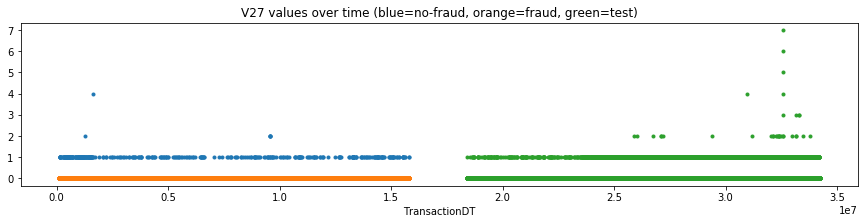

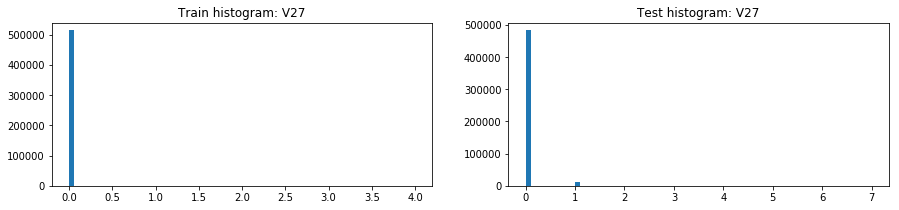

,V27,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.0000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.000776,0.0000,0.000802,0.022649,0.001204,0.027680
2,std,0.028596,0.0000,0.029073,0.150069,0.034672,0.165495
3,min,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
7,max,4.000000,0.0000,4.000000,7.000000,1.000000,7.000000
8,unique values,5.000000,2.0000,5.000000,9.000000,3.000000,9.000000
9,NaNs,76073.000000,3887.0000,72186.000000,12589.000000,7455.000000,5134.000000


,V27,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,514076,0.032633,16776,482965
1,-999.0,76073,0.051096,3887,12589
2,1.0,385,0.000000,0,11103
3,2.0,5,0.000000,0,25
4,4.0,1,0.000000,0,2


,V27,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,514076,0.032633,16776,482965
1,-999.0,76073,0.051096,3887,12589
2,1.0,385,0.000000,0,11103
3,2.0,5,0.000000,0,25
4,4.0,1,0.000000,0,2


,Column,Correlation with V27
0,V27,1.000000
1,V28,0.973049
2,V89,0.935332
3,V68,0.889336
4,C3,0.548193
5,V277,0.146077
360,V329,-0.076322
361,V328,-0.078278
362,V330,-0.078566
363,V327,-0.093800


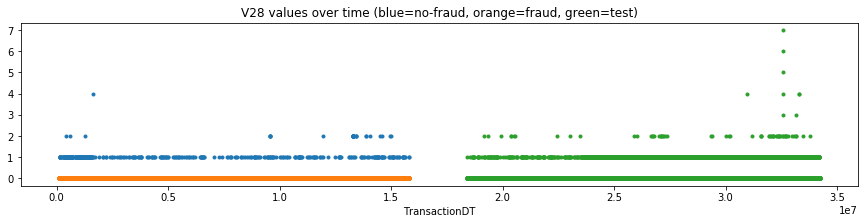

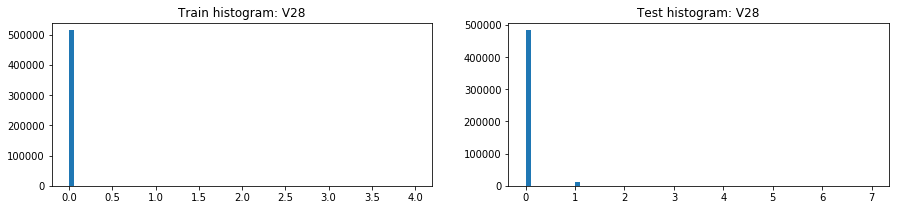

,V28,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.0000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.000830,0.0000,0.000858,0.022738,0.001289,0.027770
2,std,0.031133,0.0000,0.031653,0.150903,0.037899,0.166263
3,min,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
7,max,4.000000,0.0000,4.000000,7.000000,2.000000,7.000000
8,unique values,5.000000,2.0000,5.000000,9.000000,4.000000,9.000000
9,NaNs,76073.000000,3887.0000,72186.000000,12589.000000,7455.000000,5134.000000


,V28,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,514073,0.032633,16776,482958
1,-999.0,76073,0.051096,3887,12589
2,1.0,363,0.000000,0,11075
3,2.0,30,0.000000,0,60
4,4.0,1,0.000000,0,4


,V28,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,514073,0.032633,16776,482958
1,-999.0,76073,0.051096,3887,12589
2,1.0,363,0.000000,0,11075
3,2.0,30,0.000000,0,60
4,4.0,1,0.000000,0,4


,Column,Correlation with V28
0,V28,1.000000
1,V27,0.973049
2,V89,0.968086
3,V68,0.914602
4,C3,0.593655
5,V267,0.195550
360,V329,-0.074457
361,V328,-0.076349
362,V330,-0.076881
363,V327,-0.090587


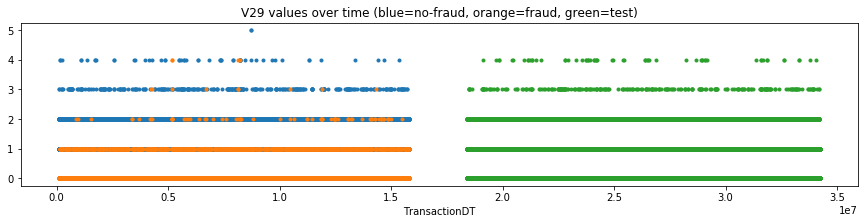

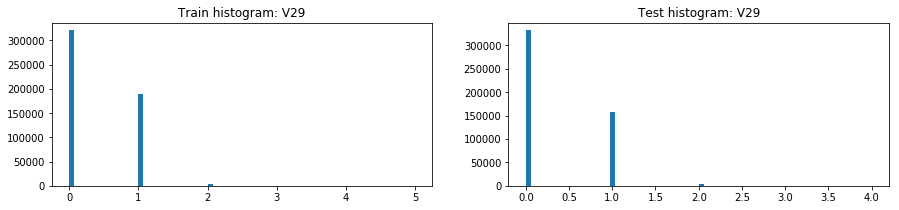

,V29,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.387840,0.087864,0.397952,0.337185,0.402518,0.321861
2,std,0.510652,0.307336,0.513065,0.493252,0.511875,0.487516
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000
8,unique values,7.000000,6.000000,7.000000,6.000000,6.000000,6.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V29,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,320407,0.048067,15401,331940.0
1,1.0,189060,0.006839,1293,158112.0
2,-999.0,76073,0.051096,3887,12589.0
3,2.0,4590,0.015033,69,3717.0
4,3.0,351,0.025641,9,274.0
5,4.0,57,0.070175,4,59.0
6,5.0,2,0.000000,0,NaN


,V29,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,320407,0.048067,15401,331940.0
1,-999.0,76073,0.051096,3887,12589.0
2,1.0,189060,0.006839,1293,158112.0
3,2.0,4590,0.015033,69,3717.0
4,3.0,351,0.025641,9,274.0
5,4.0,57,0.070175,4,59.0
6,5.0,2,0.000000,0,NaN


,Column,Correlation with V29
0,V29,1.000000
1,V30,0.957952
2,V90,0.932192
3,V48,0.915067
4,V69,0.914609
5,V91,0.897254
208,V31,-0.300479
209,V94,-0.303423
210,V52,-0.306100
211,V51,-0.310809


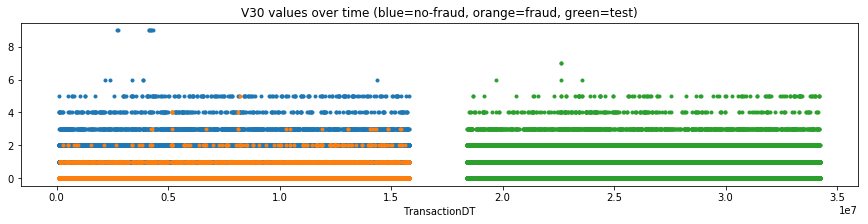

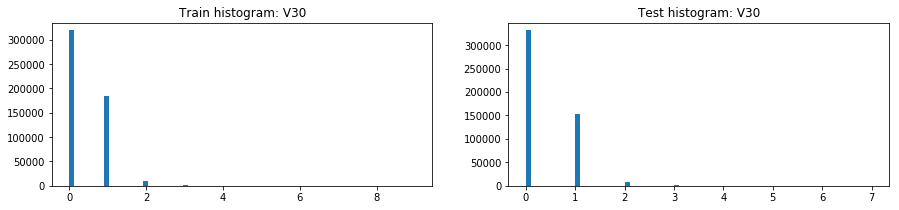

,V30,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.406436,0.095196,0.416927,0.352083,0.420253,0.336093
2,std,0.554311,0.334857,0.557192,0.530969,0.549402,0.525273
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,9.000000,5.000000,9.000000,7.000000,6.000000,7.000000
8,unique values,9.000000,7.000000,9.000000,9.000000,8.000000,9.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V30,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,319017,0.048157,15363,331104.0
1,1.0,184133,0.006827,1257,153788.0
2,-999.0,76073,0.051096,3887,12589.0
3,2.0,9685,0.013733,133,7899.0
4,3.0,1160,0.016379,19,979.0
5,4.0,279,0.010753,3,225.0
6,5.0,180,0.005556,1,102.0
7,9.0,7,0.000000,0,NaN
8,6.0,6,0.000000,0,3.0


,V30,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,319017,0.048157,15363,331104.0
1,-999.0,76073,0.051096,3887,12589.0
2,1.0,184133,0.006827,1257,153788.0
3,2.0,9685,0.013733,133,7899.0
4,3.0,1160,0.016379,19,979.0
5,4.0,279,0.010753,3,225.0
6,5.0,180,0.005556,1,102.0
7,9.0,7,0.000000,0,NaN
8,6.0,6,0.000000,0,3.0


,Column,Correlation with V30
0,V30,1.000000
1,V29,0.957952
2,V91,0.916219
3,V90,0.901783
4,V70,0.894898
5,V49,0.893633
208,V31,-0.290085
209,V94,-0.292786
210,V52,-0.296323
211,V51,-0.300878


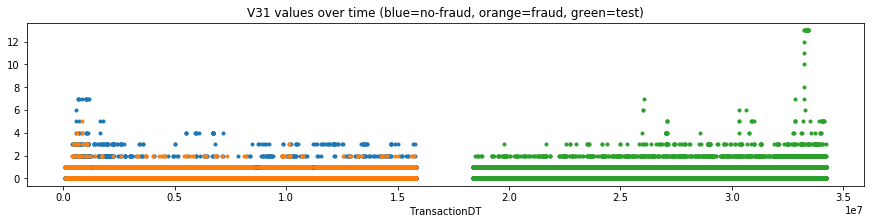

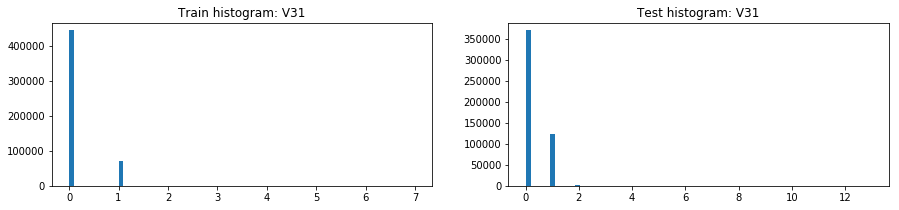

,V31,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.140761,0.456962,0.130103,0.255544,0.120873,0.287135
2,std,0.355793,0.516374,0.344070,0.452590,0.328844,0.471455
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,7.000000,5.000000,7.000000,13.000000,3.000000,13.000000
8,unique values,9.000000,7.000000,9.000000,14.000000,5.000000,14.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V31,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,443045,0.020853,9239,369773
1,-999.0,76073,0.051096,3887,12589
2,1.0,70729,0.105035,7429,122946
3,2.0,477,0.190776,91,1120
4,3.0,167,0.083832,14,176
5,4.0,33,0.060606,2,36
6,7.0,10,0.000000,0,3
7,5.0,5,0.200000,1,24
8,6.0,1,0.000000,0,5


,V31,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,443045,0.020853,9239,369773
1,1.0,70729,0.105035,7429,122946
2,-999.0,76073,0.051096,3887,12589
3,2.0,477,0.190776,91,1120
4,3.0,167,0.083832,14,176
5,4.0,33,0.060606,2,36
6,5.0,5,0.200000,1,24
7,7.0,10,0.000000,0,3
8,6.0,1,0.000000,0,5


,Column,Correlation with V31
0,V31,1.000000
1,V32,0.986201
2,V50,0.981457
3,V92,0.965936
4,V71,0.958732
5,V93,0.928171
362,V159,-0.487232
363,V160,-0.501588
364,V150,-0.502933
365,V151,-0.538982


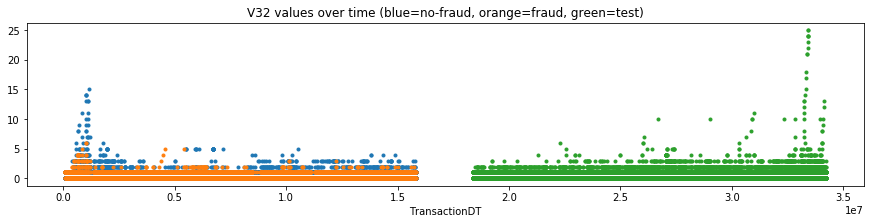

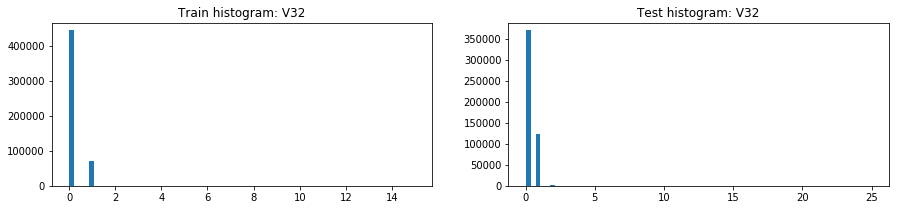

,V32,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.142417,0.463758,0.131586,0.258289,0.121512,0.290374
2,std,0.368278,0.538916,0.356108,0.470983,0.331641,0.492587
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,15.000000,6.000000,15.000000,25.000000,4.000000,25.000000
8,unique values,16.000000,8.000000,16.000000,24.000000,6.000000,24.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V32,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,443018,0.020855,9239,369709
1,-999.0,76073,0.051096,3887,12589
2,1.0,70307,0.104755,7365,122196
3,2.0,790,0.162025,128,1723
4,3.0,226,0.106195,24,324
5,4.0,51,0.294118,15,78
6,5.0,44,0.068182,3,26
7,6.0,8,0.250000,2,8
8,7.0,5,0.000000,0,4
9,8.0,4,0.000000,0,4


,V32,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,443018,0.020855,9239,369709
1,1.0,70307,0.104755,7365,122196
2,-999.0,76073,0.051096,3887,12589
3,2.0,790,0.162025,128,1723
4,3.0,226,0.106195,24,324
5,4.0,51,0.294118,15,78
6,5.0,44,0.068182,3,26
7,6.0,8,0.250000,2,8
8,7.0,5,0.000000,0,4
9,8.0,4,0.000000,0,4


,Column,Correlation with V32
0,V32,1.000000
1,V31,0.986201
2,V50,0.961004
3,V92,0.945899
4,V71,0.938717
5,V16,0.912332
362,V150,-0.447032
363,V36,-0.452201
364,addr2,-0.457248
365,V151,-0.479138


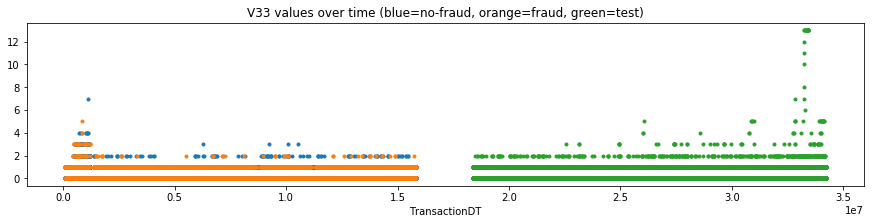

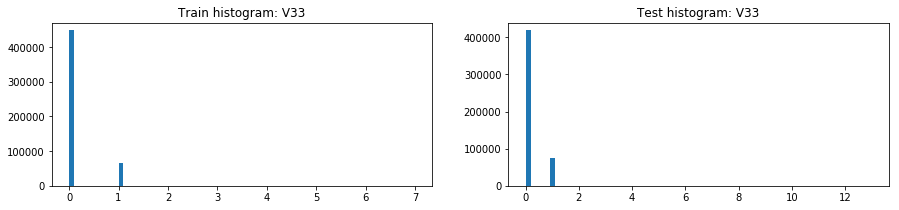

,V33,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.130693,0.471388,0.119209,0.154984,0.119903,0.163213
2,std,0.340900,0.518410,0.327150,0.374251,0.326616,0.384108
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,7.000000,5.000000,7.000000,13.000000,2.000000,13.000000
8,unique values,8.000000,7.000000,7.000000,14.000000,4.000000,14.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V33,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,447769,0.020100,9000,418368
1,-999.0,76073,0.051096,3887,12589
2,1.0,66267,0.115774,7672,75243
3,2.0,338,0.233728,79,383
4,3.0,82,0.280488,23,52
5,4.0,9,0.111111,1,13
6,5.0,1,1.000000,1,21
7,7.0,1,0.000000,0,2


,V33,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,447769,0.020100,9000,418368
1,1.0,66267,0.115774,7672,75243
2,-999.0,76073,0.051096,3887,12589
3,2.0,338,0.233728,79,383
4,3.0,82,0.280488,23,52
5,4.0,9,0.111111,1,13
6,5.0,1,1.000000,1,21
7,7.0,1,0.000000,0,2


,Column,Correlation with V33
0,V33,1.000000
1,V94,0.975796
2,V34,0.959243
3,V15,0.958773
4,V16,0.943636
5,V51,0.940497
328,V53,-0.387275
329,V54,-0.398097
330,V35,-0.411890
331,V36,-0.420924


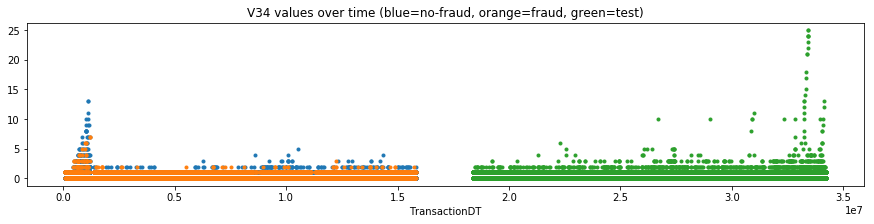

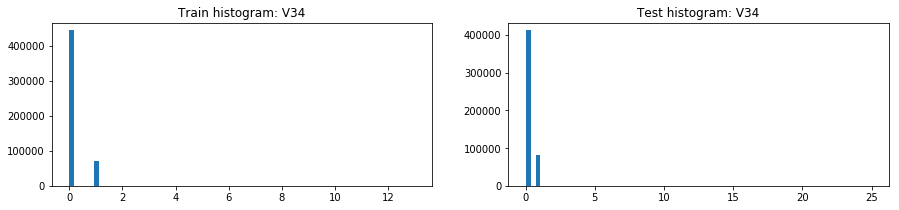

,V34,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,514467.000000,16776.000000,497691.000000,494102.000000,93884.000000,400219.000000
1,mean,0.139154,0.490284,0.127318,0.170068,0.134709,0.178362
2,std,0.357549,0.538387,0.343634,0.403681,0.343777,0.416053
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,13.000000,7.000000,13.000000,25.000000,4.000000,25.000000
8,unique values,14.000000,9.000000,14.000000,24.000000,6.000000,24.000000
9,NaNs,76073.000000,3887.000000,72186.000000,12589.000000,7455.000000,5134.000000


,V34,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,443989,0.019730,8760,411616
1,-999.0,76073,0.051096,3887,12589
2,1.0,69776,0.112976,7883,81672
3,2.0,496,0.169355,84,566
4,3.0,129,0.279070,36,153
5,4.0,34,0.176471,6,36
6,5.0,14,0.142857,2,17
7,6.0,8,0.375000,3,6
8,7.0,7,0.285714,2,2
9,8.0,6,0.000000,0,4


,V34,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,443989,0.019730,8760,411616
1,1.0,69776,0.112976,7883,81672
2,-999.0,76073,0.051096,3887,12589
3,2.0,496,0.169355,84,566
4,3.0,129,0.279070,36,153
5,4.0,34,0.176471,6,36
6,6.0,8,0.375000,3,6
7,5.0,14,0.142857,2,17
8,7.0,7,0.285714,2,2
9,8.0,6,0.000000,0,4


,Column,Correlation with V34
0,V34,1.000000
1,V33,0.959243
2,V94,0.933831
3,V16,0.931086
4,V15,0.922002
5,V51,0.904782
328,V53,-0.363768
329,V54,-0.366323
330,V35,-0.388892
331,V36,-0.391636


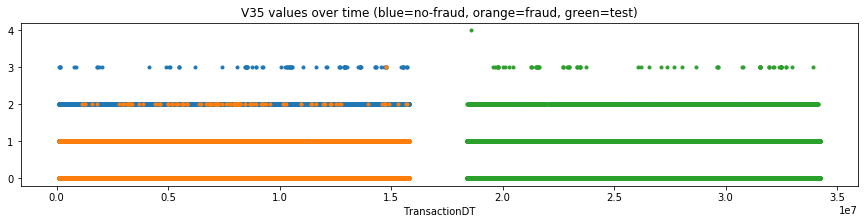

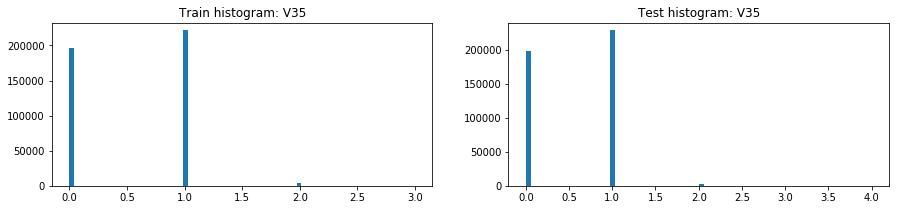

,V35,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.542594,0.332258,0.550122,0.544134,0.647987,0.520297
2,std,0.516010,0.490180,0.515322,0.511129,0.494321,0.511946
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,3.000000,3.000000,3.000000,4.000000,4.000000,3.000000
8,unique values,5.000000,5.000000,5.000000,6.000000,6.000000,5.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V35,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,221387,0.020679,4578,228457
1,0.0,196551,0.050160,9859,198704
2,-999.0,168969,0.036078,6096,76854
3,2.0,3544,0.036117,128,2597
4,3.0,89,0.022472,2,78


,V35,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,196551,0.050160,9859,198704
1,-999.0,168969,0.036078,6096,76854
2,1.0,221387,0.020679,4578,228457
3,2.0,3544,0.036117,128,2597
4,3.0,89,0.022472,2,78


,Column,Correlation with V35
0,V35,1.000000
1,V36,0.931576
2,V75,0.743539
3,V76,0.704597
4,V12,0.659987
5,V13,0.633326
208,V32,-0.442416
209,V71,-0.444477
210,V92,-0.452122
211,V31,-0.452792


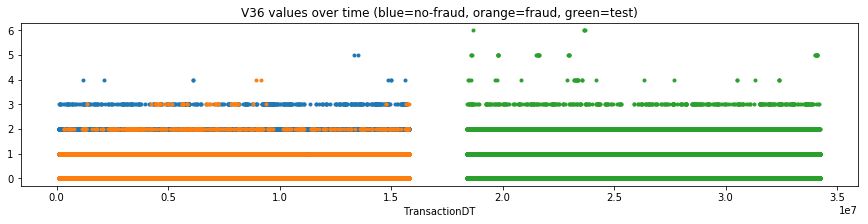

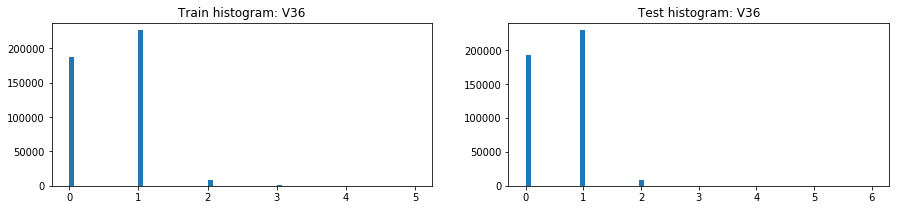

,V36,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.579198,0.380106,0.586323,0.572833,0.684860,0.547119
2,std,0.539039,0.560396,0.536893,0.538038,0.520035,0.538810
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,4.000000,5.000000,6.000000,6.000000,6.000000
8,unique values,7.000000,6.000000,7.000000,8.000000,8.000000,8.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V36,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,226024,0.020179,4561,228956
1,0.0,186733,0.051116,9545,192534
2,-999.0,168969,0.036078,6096,76854
3,2.0,8307,0.049236,409,7863
4,3.0,495,0.101010,50,427
5,4.0,10,0.200000,2,27
6,5.0,2,0.000000,0,26


,V36,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,186733,0.051116,9545,192534
1,-999.0,168969,0.036078,6096,76854
2,1.0,226024,0.020179,4561,228956
3,2.0,8307,0.049236,409,7863
4,3.0,495,0.101010,50,427
5,4.0,10,0.200000,2,27
6,5.0,2,0.000000,0,26


,Column,Correlation with V36
0,V36,1.000000
1,V35,0.931576
2,V76,0.746569
3,V75,0.703356
4,V13,0.669024
5,V54,0.640361
208,V32,-0.452201
209,V71,-0.454318
210,V92,-0.462045
211,V31,-0.462807


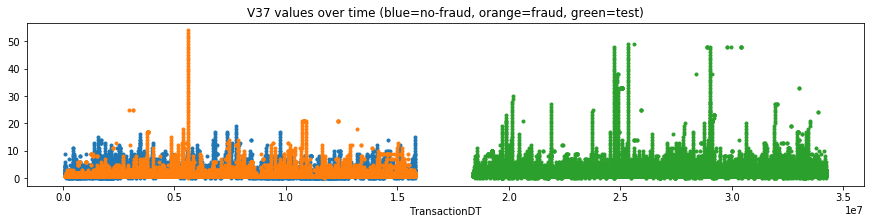

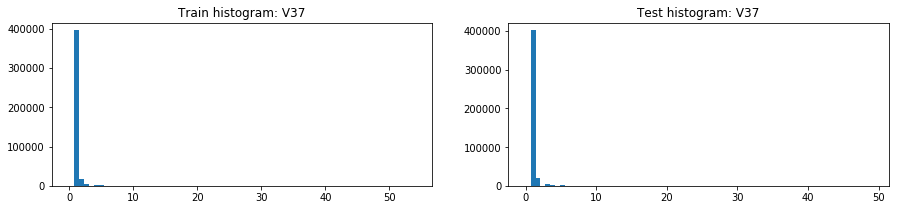

,V37,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,1.108065,1.753964,1.084948,1.137973,1.115630,1.143102
2,std,0.690571,2.629251,0.480715,1.002657,0.728676,1.055493
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
7,max,54.000000,54.000000,19.000000,49.000000,30.000000,49.000000
8,unique values,56.000000,56.000000,21.000000,51.000000,32.000000,51.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V37,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,395228,0.027382,10822,401275.0
1,-999.0,168969,0.036078,6096,76854.0
2,2.0,18453,0.105999,1956,19231.0
3,3.0,3801,0.195738,744,4231.0
4,4.0,1474,0.195387,288,1778.0
5,5.0,796,0.199749,159,902.0
6,6.0,420,0.304762,128,555.0
7,7.0,327,0.296636,97,362.0
8,0.0,325,0.006154,2,191.0
9,8.0,193,0.347150,67,255.0


,V37,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,395228,0.027382,10822,401275
1,-999.0,168969,0.036078,6096,76854
2,2.0,18453,0.105999,1956,19231
3,3.0,3801,0.195738,744,4231
4,4.0,1474,0.195387,288,1778
5,5.0,796,0.199749,159,902
6,6.0,420,0.304762,128,555
7,7.0,327,0.296636,97,362
8,9.0,168,0.452381,76,151
9,8.0,193,0.347150,67,255


,Column,Correlation with V37
0,V37,1.000000
1,V38,0.868884
2,V77,0.688616
3,V228,0.687371
4,V44,0.647236
5,V230,0.598265
375,V53,-0.113655
376,V54,-0.116795
377,V12,-0.117251
378,V13,-0.119762


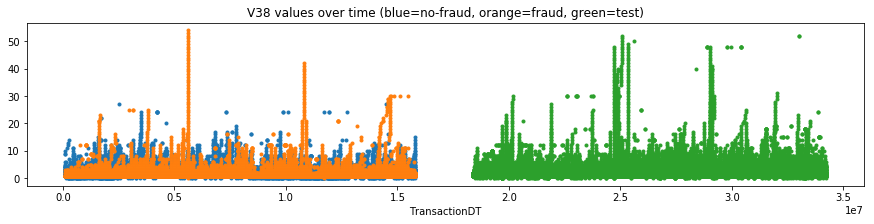

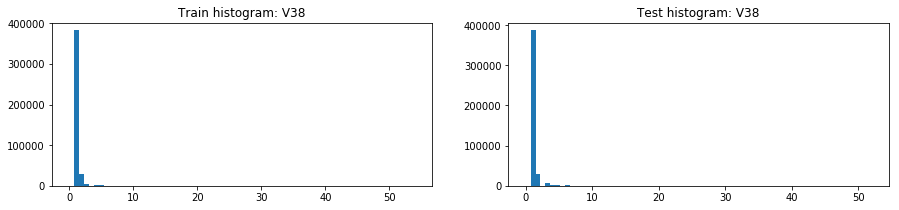

,V38,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.00000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,1.16240,2.065902,1.130063,1.209175,1.177091,1.216539
2,std,0.85892,3.202819,0.605612,1.183571,0.850781,1.247379
3,min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.00000,2.000000,1.000000,1.000000,1.000000,1.000000
7,max,54.00000,54.000000,27.000000,52.000000,30.000000,52.000000
8,unique values,56.00000,56.000000,27.000000,54.000000,32.000000,54.000000
9,NaNs,168969.00000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V38,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,382093,0.025520,9751,386613.0
1,-999.0,168969,0.036078,6096,76854.0
2,2.0,28073,0.081965,2301,28514.0
3,3.0,5616,0.174858,982,6793.0
4,4.0,2208,0.205616,454,2794.0
5,5.0,1129,0.217892,246,1516.0
6,6.0,615,0.284553,175,854.0
7,7.0,426,0.342723,146,555.0
8,0.0,325,0.006154,2,187.0
9,8.0,263,0.296578,78,398.0


,V38,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,382093,0.025520,9751,386613
1,-999.0,168969,0.036078,6096,76854
2,2.0,28073,0.081965,2301,28514
3,3.0,5616,0.174858,982,6793
4,4.0,2208,0.205616,454,2794
5,5.0,1129,0.217892,246,1516
6,6.0,615,0.284553,175,854
7,7.0,426,0.342723,146,555
8,8.0,263,0.296578,78,398
9,10.0,144,0.451389,65,358


,Column,Correlation with V38
0,V38,1.000000
1,V37,0.868884
2,V45,0.641233
3,V77,0.636275
4,V78,0.633121
5,V228,0.625274
375,V53,-0.120757
376,D2,-0.121584
377,V12,-0.121793
378,V13,-0.122292


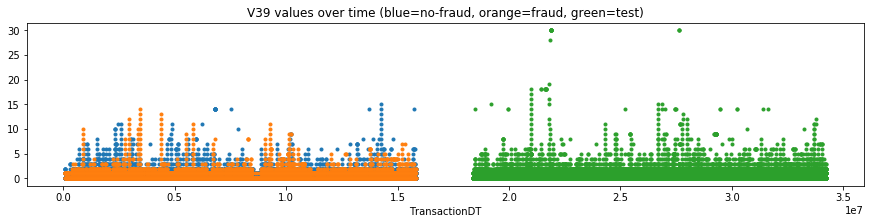

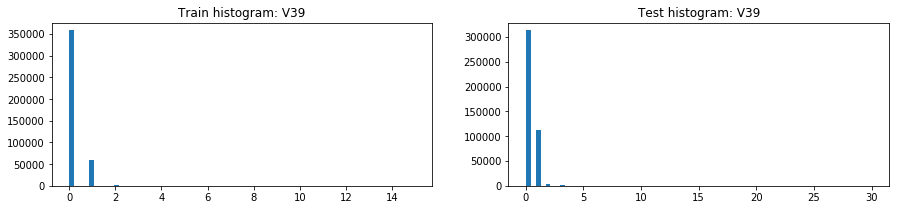

,V39,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.00000,80247.000000,349591.000000
1,mean,0.166076,0.651267,0.148711,0.29293,0.144766,0.326939
2,std,0.451956,0.947924,0.413146,0.57212,0.514928,0.579135
3,min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.00000,0.000000,1.000000
7,max,15.000000,14.000000,15.000000,30.00000,19.000000,30.000000
8,unique values,17.000000,16.000000,17.000000,23.00000,21.000000,19.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.00000,21092.000000,55762.000000


,V39,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,357994,0.020366,7291,313015
1,-999.0,168969,0.036078,6096,76854
2,1.0,59921,0.101751,6097,111693
3,2.0,2497,0.294754,736,3720
4,3.0,566,0.409894,232,679
5,4.0,253,0.347826,88,277
6,5.0,108,0.351852,38,176
7,6.0,82,0.329268,27,75
8,7.0,48,0.291667,14,44
9,8.0,37,0.405405,15,35


,V39,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,357994,0.020366,7291,313015
1,1.0,59921,0.101751,6097,111693
2,-999.0,168969,0.036078,6096,76854
3,2.0,2497,0.294754,736,3720
4,3.0,566,0.409894,232,679
5,4.0,253,0.347826,88,277
6,5.0,108,0.351852,38,176
7,6.0,82,0.329268,27,75
8,8.0,37,0.405405,15,35
9,7.0,48,0.291667,14,44


,Column,Correlation with V39
0,V39,1.000000
1,V40,0.943888
2,V80,0.902400
3,V59,0.896473
4,V42,0.876143
5,V81,0.867285
362,V12,-0.389792
363,V36,-0.394839
364,V13,-0.399938
365,V53,-0.401318


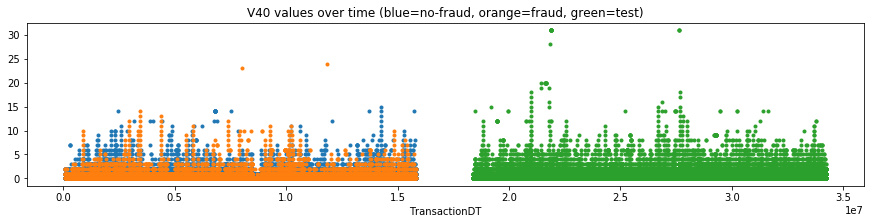

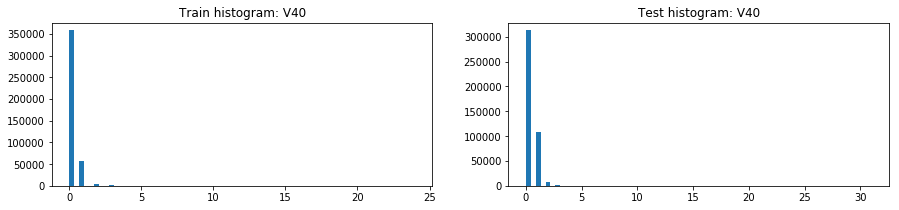

,V40,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.177145,0.745109,0.156817,0.311323,0.163221,0.345318
2,std,0.505786,1.154619,0.453107,0.638946,0.607201,0.641204
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,24.000000,24.000000,15.000000,31.000000,20.000000,31.000000
8,unique values,19.000000,18.000000,17.000000,24.000000,22.000000,22.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V40,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,357837,0.020303,7265,312763.0
1,-999.0,168969,0.036078,6096,76854.0
2,1.0,57473,0.095941,5514,107469.0
3,2.0,4230,0.241135,1020,6757.0
4,3.0,1046,0.398662,417,1415.0
5,4.0,400,0.357500,143,591.0
6,5.0,209,0.272727,57,320.0
7,6.0,145,0.420690,61,183.0
8,7.0,78,0.294872,23,88.0
9,8.0,50,0.440000,22,84.0


,V40,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,357837,0.020303,7265,312763
1,-999.0,168969,0.036078,6096,76854
2,1.0,57473,0.095941,5514,107469
3,2.0,4230,0.241135,1020,6757
4,3.0,1046,0.398662,417,1415
5,4.0,400,0.357500,143,591
6,6.0,145,0.420690,61,183
7,5.0,209,0.272727,57,320
8,7.0,78,0.294872,23,88
9,8.0,50,0.440000,22,84


,Column,Correlation with V40
0,V40,1.000000
1,V39,0.943888
2,V81,0.876484
3,V60,0.866431
4,V80,0.862709
5,V43,0.853337
362,V36,-0.376330
363,V13,-0.380729
364,V53,-0.382665
365,addr2,-0.386945


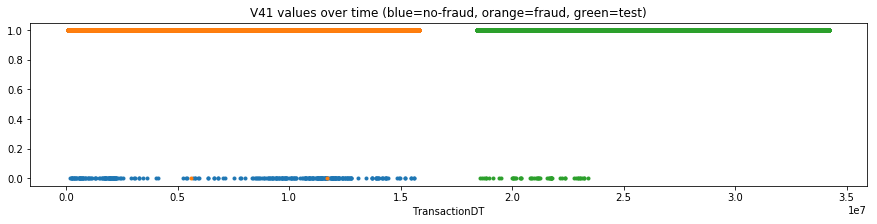

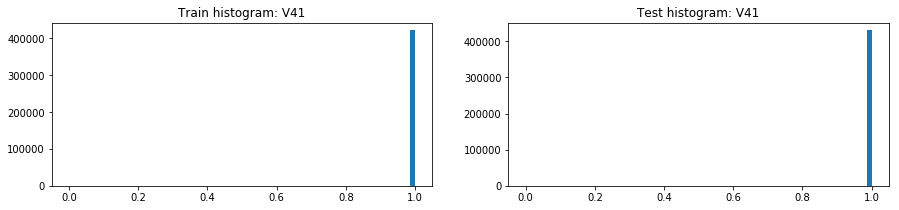

,V41,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.999269,0.999863,0.999248,0.999881,0.999539,0.999960
2,std,0.027020,0.011717,0.027409,0.010892,0.021468,0.006328
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,unique values,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V41,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,421263,0.034575,14565,429786
1,-999.0,168969,0.036078,6096,76854
2,0.0,308,0.006494,2,51


,V41,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,421263,0.034575,14565,429786
1,-999.0,168969,0.036078,6096,76854
2,0.0,308,0.006494,2,51


,Column,Correlation with V41
0,V41,1.000000
1,V88,0.942586
2,V65,0.891086
3,V14,0.880084
4,V1,0.462228
5,V46,0.165801
375,V302,-0.048362
376,D5,-0.051020
377,D6,-0.051160
378,D8,-0.065795


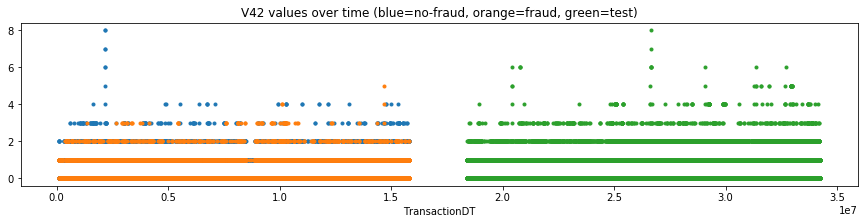

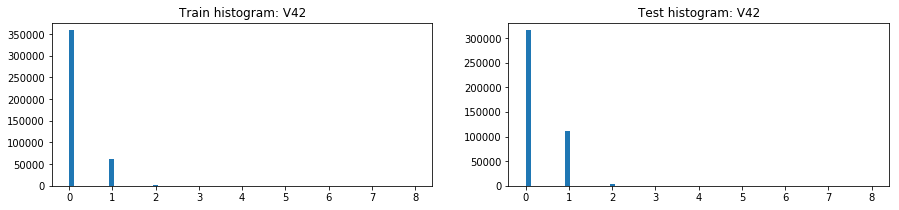

,V42,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.156118,0.539507,0.142397,0.276451,0.129538,0.310174
2,std,0.382896,0.596745,0.365600,0.474845,0.360598,0.491219
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,8.000000,5.000000,8.000000,8.000000,6.000000,8.000000
8,unique values,10.000000,7.000000,10.000000,10.000000,8.000000,10.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V42,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,358439,0.020648,7401,315401
1,-999.0,168969,0.036078,6096,76854
2,1.0,60801,0.107860,6558,110831
3,2.0,2037,0.259205,528,3027
4,3.0,256,0.296875,76,427
5,4.0,30,0.100000,3,108
6,5.0,2,0.500000,1,30
7,6.0,2,0.000000,0,11
8,7.0,2,0.000000,0,1
9,8.0,2,0.000000,0,1


,V42,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,358439,0.020648,7401,315401
1,1.0,60801,0.107860,6558,110831
2,-999.0,168969,0.036078,6096,76854
3,2.0,2037,0.259205,528,3027
4,3.0,256,0.296875,76,427
5,4.0,30,0.100000,3,108
6,5.0,2,0.500000,1,30
7,6.0,2,0.000000,0,11
8,7.0,2,0.000000,0,1
9,8.0,2,0.000000,0,1


,Column,Correlation with V42
0,V42,1.000000
1,V84,0.957588
2,V63,0.953351
3,V43,0.952002
4,V21,0.944027
5,V22,0.934389
362,V12,-0.433017
363,V36,-0.438108
364,V13,-0.444288
365,V53,-0.446543


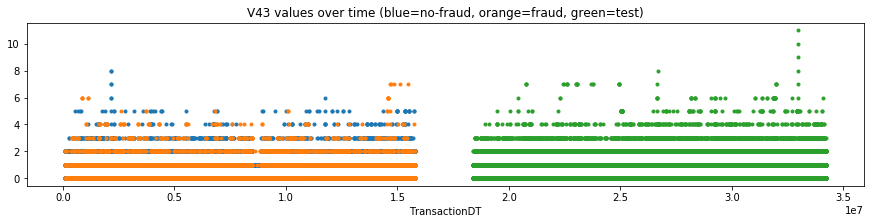

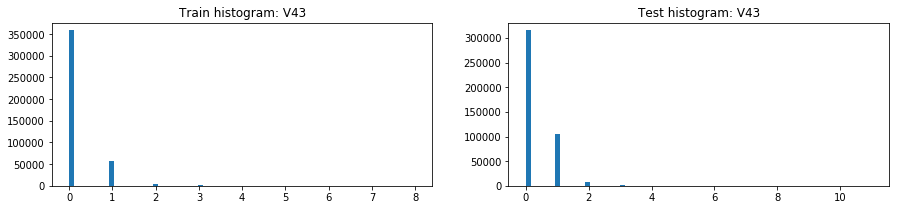

,V43,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.168942,0.623121,0.152686,0.298071,0.146024,0.332972
2,std,0.433359,0.769766,0.407024,0.539790,0.427083,0.556653
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,8.000000,7.000000,8.000000,11.000000,7.000000,11.000000
8,unique values,10.000000,9.000000,10.000000,13.000000,9.000000,13.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V43,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,358261,0.020577,7372,315056
1,-999.0,168969,0.036078,6096,76854
2,1.0,56929,0.102408,5830,104444
3,2.0,5234,0.188193,985,8167
4,3.0,885,0.324294,287,1632
5,4.0,174,0.396552,69,359
6,5.0,66,0.136364,9,104
7,6.0,13,0.769231,10,44
8,7.0,7,0.714286,5,26
9,8.0,2,0.000000,0,2


,V43,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,358261,0.020577,7372,315056
1,-999.0,168969,0.036078,6096,76854
2,1.0,56929,0.102408,5830,104444
3,2.0,5234,0.188193,985,8167
4,3.0,885,0.324294,287,1632
5,4.0,174,0.396552,69,359
6,6.0,13,0.769231,10,44
7,5.0,66,0.136364,9,104
8,7.0,7,0.714286,5,26
9,8.0,2,0.000000,0,2


,Column,Correlation with V43
0,V43,1.000000
1,V42,0.952002
2,V64,0.920388
3,V85,0.915452
4,V84,0.915055
5,V63,0.910219
362,V12,-0.414433
363,V36,-0.418888
364,V13,-0.425221
365,V53,-0.427198


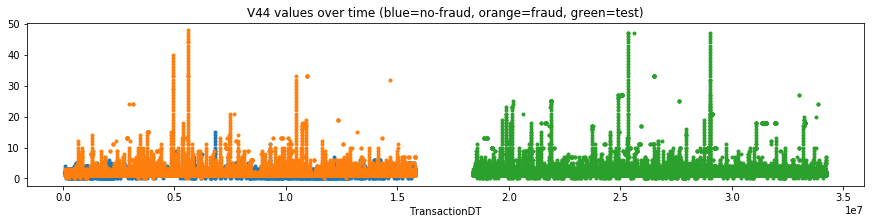

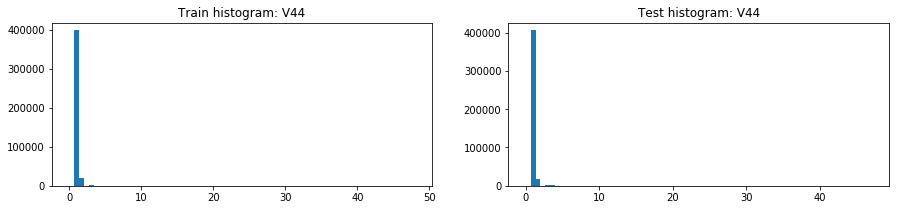

,V44,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,1.083891,1.963548,1.052407,1.103372,1.109711,1.101916
2,std,0.639143,3.011257,0.264426,0.843529,0.753380,0.862887
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
7,max,48.000000,48.000000,15.000000,47.000000,25.000000,47.000000
8,unique values,50.000000,50.000000,17.000000,49.000000,27.000000,49.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V44,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,397653,0.026015,10345,405518.0
1,-999.0,168969,0.036078,6096,76854.0
2,2.0,19434,0.101832,1979,18884.0
3,3.0,2242,0.330062,740,2588.0
4,4.0,615,0.686179,422,868.0
5,0.0,441,0.077098,34,202.0
6,5.0,319,0.764890,244,341.0
7,6.0,208,0.812500,169,219.0
8,7.0,138,0.949275,131,167.0
9,9.0,102,0.960784,98,109.0


,V44,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,397653,0.026015,10345,405518
1,-999.0,168969,0.036078,6096,76854
2,2.0,19434,0.101832,1979,18884
3,3.0,2242,0.330062,740,2588
4,4.0,615,0.686179,422,868
5,5.0,319,0.764890,244,341
6,6.0,208,0.812500,169,219
7,7.0,138,0.949275,131,167
8,9.0,102,0.960784,98,109
9,8.0,83,0.927711,77,98


,Column,Correlation with V44
0,V44,1.000000
1,V45,0.905101
2,V257,0.766933
3,V200,0.692804
4,V199,0.688442
5,V246,0.682124
375,V13,-0.065195
376,V53,-0.068840
377,V54,-0.071493
378,D8,-0.081858


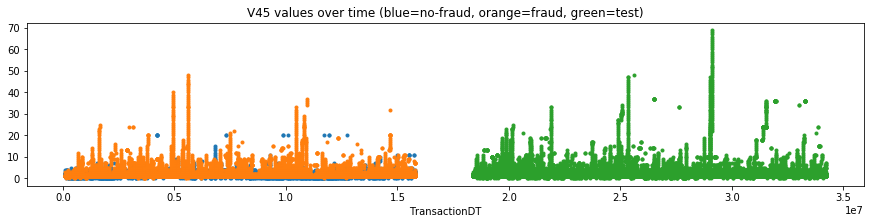

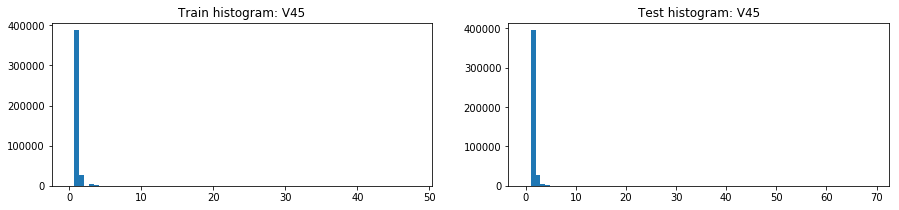

,V45,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,1.120779,2.207936,1.081869,1.146530,1.156056,1.144343
2,std,0.729774,3.290828,0.346760,1.075638,0.858947,1.119463
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
7,max,48.000000,48.000000,20.000000,69.000000,25.000000,69.000000
8,unique values,50.000000,50.000000,18.000000,71.000000,27.000000,71.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V45,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,387027,0.024838,9613,394651
1,-999.0,168969,0.036078,6096,76854
2,2.0,28125,0.077013,2166,27474
3,3.0,3472,0.230703,801,3956
4,4.0,906,0.620309,562,1230
5,5.0,438,0.732877,321,520
6,0.0,412,0.060680,25,195
7,6.0,253,0.814229,206,365
8,7.0,214,0.920561,197,202
9,9.0,143,0.958042,137,117


,V45,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,387027,0.024838,9613,394651
1,-999.0,168969,0.036078,6096,76854
2,2.0,28125,0.077013,2166,27474
3,3.0,3472,0.230703,801,3956
4,4.0,906,0.620309,562,1230
5,5.0,438,0.732877,321,520
6,6.0,253,0.814229,206,365
7,7.0,214,0.920561,197,202
8,9.0,143,0.958042,137,117
9,8.0,132,0.924242,122,134


,Column,Correlation with V45
0,V45,1.000000
1,V44,0.905101
2,V257,0.741696
3,V201,0.670059
4,V246,0.669157
5,V199,0.665572
375,V12,-0.066598
376,V54,-0.069164
377,V53,-0.069561
378,D8,-0.089789


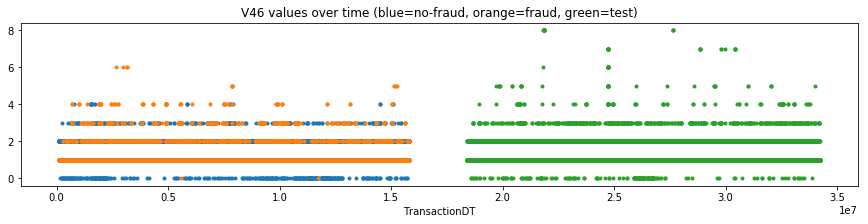

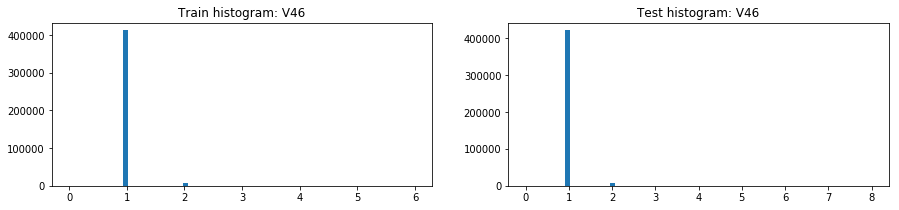

,V46,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,1.022286,1.133315,1.018312,1.022211,1.020910,1.022509
2,std,0.166719,0.447973,0.145434,0.175910,0.166885,0.177915
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,6.000000,4.000000,8.000000,6.000000,8.000000
8,unique values,8.000000,8.000000,6.000000,10.000000,8.000000,10.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V46,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,412247,0.031801,13110,421088
1,-999.0,168969,0.036078,6096,76854
2,2.0,8340,0.128897,1075,7784
3,3.0,521,0.550864,287,620
4,0.0,348,0.005747,2,171
5,4.0,103,0.786408,81,94
6,5.0,8,1.000000,8,36
7,6.0,4,1.000000,4,10


,V46,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,412247,0.031801,13110,421088
1,-999.0,168969,0.036078,6096,76854
2,2.0,8340,0.128897,1075,7784
3,3.0,521,0.550864,287,620
4,4.0,103,0.786408,81,94
5,5.0,8,1.000000,8,36
6,6.0,4,1.000000,4,10
7,0.0,348,0.005747,2,171


,Column,Correlation with V46
0,V46,1.000000
1,V47,0.755280
2,V44,0.391058
3,V37,0.390613
4,V45,0.360067
5,V38,0.339737
375,V12,-0.040291
376,V29,-0.040457
377,V75,-0.042548
378,D8,-0.062397


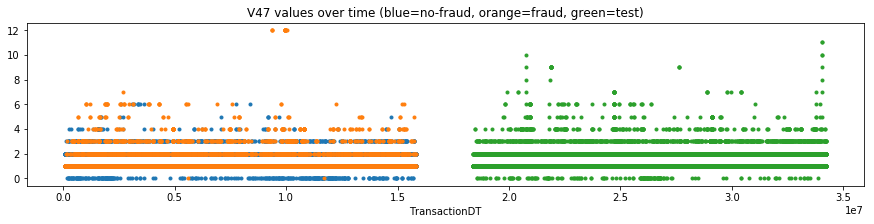

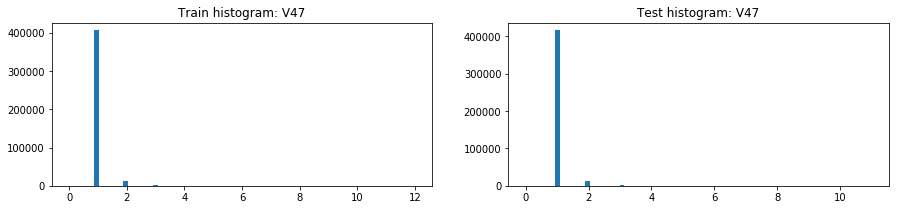

,V47,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,1.038515,1.239651,1.031317,1.037877,1.036899,1.038102
2,std,0.231862,0.707659,0.190426,0.235685,0.234845,0.235877
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,12.000000,12.000000,6.000000,11.000000,10.000000,11.000000
8,unique values,10.000000,10.000000,8.000000,13.000000,12.000000,13.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V47,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,406519,0.030095,12234,415540.0
1,-999.0,168969,0.036078,6096,76854.0
2,2.0,13389,0.121592,1628,12651.0
3,3.0,1018,0.470530,479,1014.0
4,0.0,347,0.005764,2,169.0
5,4.0,189,0.714286,135,284.0
6,6.0,49,0.795918,39,55.0
7,5.0,44,0.772727,34,75.0
8,12.0,15,1.000000,15,NaN
9,7.0,1,1.000000,1,26.0


,V47,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,406519,0.030095,12234,415540.0
1,-999.0,168969,0.036078,6096,76854.0
2,2.0,13389,0.121592,1628,12651.0
3,3.0,1018,0.470530,479,1014.0
4,4.0,189,0.714286,135,284.0
5,6.0,49,0.795918,39,55.0
6,5.0,44,0.772727,34,75.0
7,12.0,15,1.000000,15,NaN
8,0.0,347,0.005764,2,169.0
9,7.0,1,1.000000,1,26.0


,Column,Correlation with V47
0,V47,1.000000
1,V46,0.755280
2,V38,0.411788
3,V45,0.398933
4,V52,0.365167
5,V44,0.309776
375,V69,-0.058025
376,V90,-0.059388
377,V29,-0.059653
378,D8,-0.072240


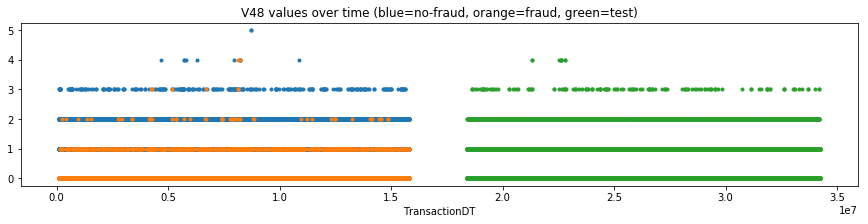

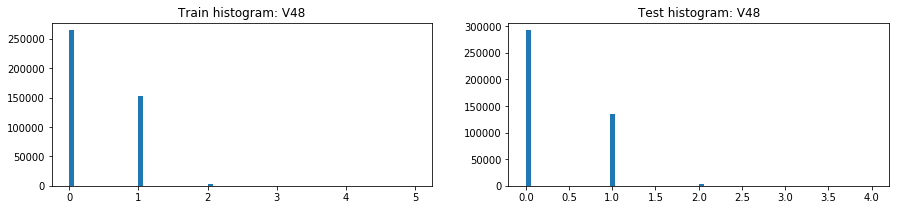

,V48,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.383174,0.072149,0.394306,0.327571,0.404003,0.310028
2,std,0.508189,0.280881,0.510969,0.485626,0.509856,0.478172
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000
8,unique values,7.000000,6.000000,7.000000,6.000000,6.000000,6.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V48,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,264325,0.051418,13591,292210.0
1,-999.0,168969,0.036078,6096,76854.0
2,1.0,153267,0.005944,911,134613.0
3,2.0,3685,0.015468,57,2862.0
4,3.0,280,0.021429,6,143.0
5,4.0,12,0.166667,2,9.0
6,5.0,2,0.000000,0,NaN


,V48,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,264325,0.051418,13591,292210.0
1,-999.0,168969,0.036078,6096,76854.0
2,1.0,153267,0.005944,911,134613.0
3,2.0,3685,0.015468,57,2862.0
4,3.0,280,0.021429,6,143.0
5,4.0,12,0.166667,2,9.0
6,5.0,2,0.000000,0,NaN


,Column,Correlation with V48
0,V48,1.000000
1,V49,0.967744
2,V90,0.944901
3,V29,0.915067
4,V69,0.912198
5,V91,0.909608
208,V92,-0.323832
209,V33,-0.326608
210,V34,-0.328893
211,V94,-0.331298


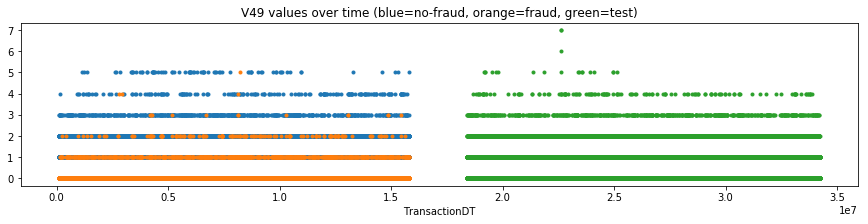

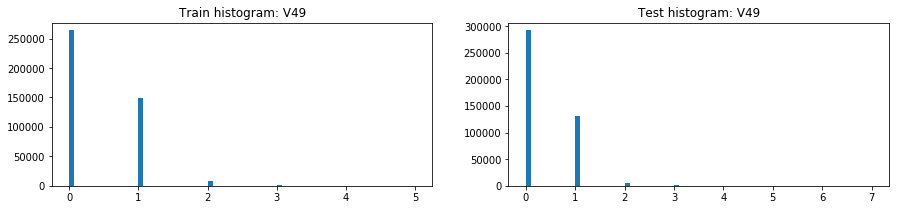

,V49,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.397724,0.079563,0.409111,0.339706,0.419168,0.321467
2,std,0.542654,0.317332,0.545579,0.516249,0.543378,0.508068
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,5.000000,5.000000,7.000000,5.000000,7.000000
8,unique values,7.000000,7.000000,7.000000,9.000000,7.000000,9.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V49,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,263761,0.051486,13580,291701
1,-999.0,168969,0.036078,6096,76854
2,1.0,149250,0.005608,837,131223
3,2.0,7604,0.017491,133,6131
4,3.0,691,0.018813,13,621
5,4.0,187,0.016043,3,140
6,5.0,78,0.012821,1,18


,V49,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,263761,0.051486,13580,291701
1,-999.0,168969,0.036078,6096,76854
2,1.0,149250,0.005608,837,131223
3,2.0,7604,0.017491,133,6131
4,3.0,691,0.018813,13,621
5,4.0,187,0.016043,3,140
6,5.0,78,0.012821,1,18


,Column,Correlation with V49
0,V49,1.000000
1,V48,0.967744
2,V91,0.925746
3,V90,0.917756
4,V30,0.893633
5,V70,0.891002
208,V92,-0.314762
209,V33,-0.317404
210,V34,-0.319635
211,V94,-0.321990


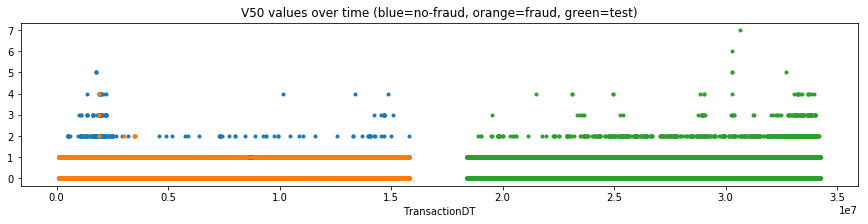

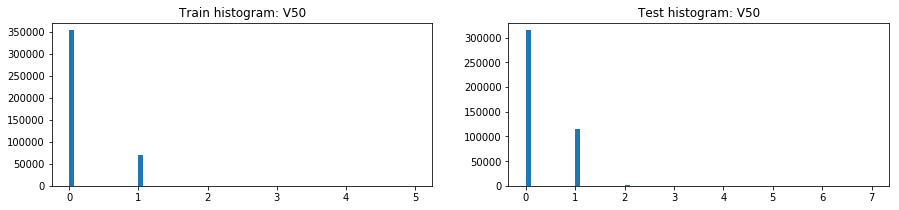

,V50,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.164746,0.520492,0.152013,0.271961,0.128329,0.304931
2,std,0.373995,0.501791,0.362182,0.452709,0.335722,0.469356
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,5.000000,4.000000,5.000000,7.000000,4.000000,7.000000
8,unique values,7.000000,6.000000,7.000000,9.000000,6.000000,9.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V50,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,352482,0.019851,6997,314211
1,-999.0,168969,0.036078,6096,76854
2,1.0,68817,0.109871,7561,114527
3,2.0,202,0.034653,7,959
4,3.0,52,0.019231,1,114
5,4.0,15,0.066667,1,21
6,5.0,3,0.000000,0,3


,V50,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,68817,0.109871,7561,114527
1,0.0,352482,0.019851,6997,314211
2,-999.0,168969,0.036078,6096,76854
3,2.0,202,0.034653,7,959
4,3.0,52,0.019231,1,114
5,4.0,15,0.066667,1,21
6,5.0,3,0.000000,0,3


,Column,Correlation with V50
0,V50,1.000000
1,V31,0.981457
2,V92,0.970760
3,V71,0.964355
4,V32,0.961004
5,V15,0.946630
362,V160,-0.528673
363,V145,-0.533730
364,V150,-0.539547
365,V151,-0.573047


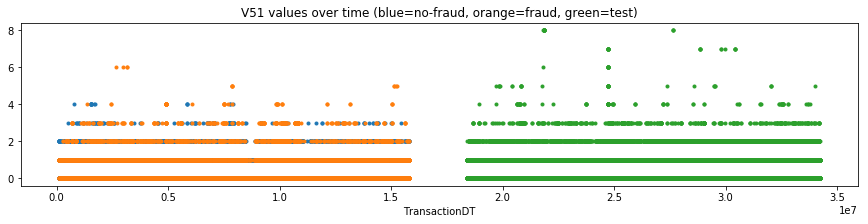

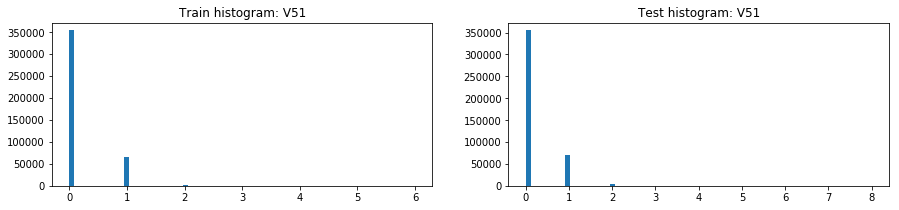

,V51,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.170579,0.647079,0.153524,0.185977,0.146884,0.194951
2,std,0.403899,0.724260,0.376541,0.425913,0.388564,0.433536
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,6.000000,6.000000,4.000000,8.000000,6.000000,8.000000
8,unique values,8.000000,8.000000,6.000000,10.000000,8.000000,10.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V51,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,353522,0.019170,6777,354721
1,-999.0,168969,0.036078,6096,76854
2,1.0,64775,0.101552,6578,71266
3,2.0,2780,0.311151,865,3205
4,3.0,416,0.687500,286,485
5,4.0,66,0.742424,49,83
6,5.0,8,1.000000,8,33
7,6.0,4,1.000000,4,10


,V51,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,353522,0.019170,6777,354721
1,1.0,64775,0.101552,6578,71266
2,-999.0,168969,0.036078,6096,76854
3,2.0,2780,0.311151,865,3205
4,3.0,416,0.687500,286,485
5,4.0,66,0.742424,49,83
6,5.0,8,1.000000,8,33
7,6.0,4,1.000000,4,10


,Column,Correlation with V51
0,V51,1.000000
1,V52,0.952022
2,V94,0.950989
3,V33,0.940497
4,V73,0.935877
5,V15,0.923125
328,V12,-0.417592
329,V13,-0.428012
330,V53,-0.435189
331,V54,-0.445213


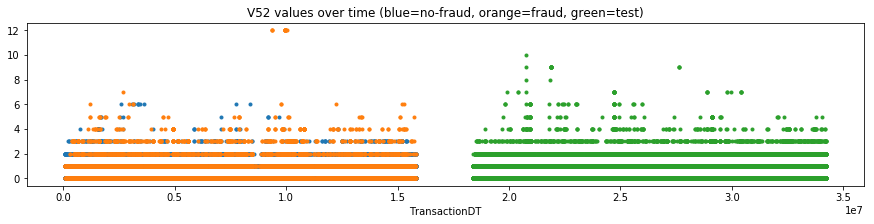

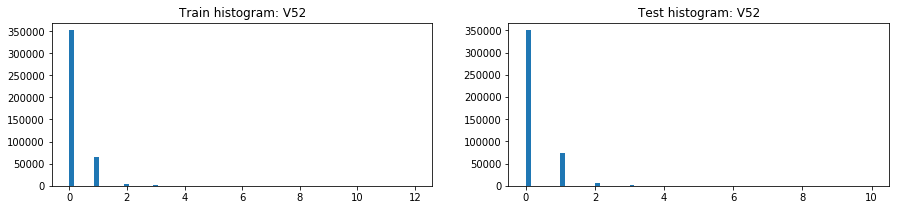

,V52,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,421571.000000,14567.000000,407004.000000,429837.000000,80247.000000,349591.000000
1,mean,0.182695,0.738381,0.162807,0.205466,0.165489,0.214642
2,std,0.439002,0.924367,0.396980,0.464834,0.431574,0.471660
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,12.000000,12.000000,6.000000,10.000000,10.000000,9.000000
8,unique values,10.000000,10.000000,8.000000,12.000000,12.000000,11.000000
9,NaNs,168969.000000,6096.000000,162873.000000,76854.000000,21092.000000,55762.000000


,V52,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,351237,0.018933,6650,349816.0
1,-999.0,168969,0.036078,6096,76854.0
2,1.0,65030,0.093572,6085,73528.0
3,2.0,4362,0.272811,1190,5357.0
4,3.0,705,0.638298,450,774.0
5,4.0,161,0.838509,135,214.0
6,5.0,41,0.780488,32,65.0
7,6.0,19,0.473684,9,42.0
8,12.0,15,1.000000,15,NaN
9,7.0,1,1.000000,1,24.0


,V52,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,351237,0.018933,6650,349816.0
1,-999.0,168969,0.036078,6096,76854.0
2,1.0,65030,0.093572,6085,73528.0
3,2.0,4362,0.272811,1190,5357.0
4,3.0,705,0.638298,450,774.0
5,4.0,161,0.838509,135,214.0
6,5.0,41,0.780488,32,65.0
7,12.0,15,1.000000,15,NaN
8,6.0,19,0.473684,9,42.0
9,7.0,1,1.000000,1,24.0


,Column,Correlation with V52
0,V52,1.000000
1,V51,0.952022
2,V94,0.905186
3,V74,0.899592
4,V33,0.895447
5,V73,0.895137
328,V12,-0.394465
329,V13,-0.399195
330,V53,-0.412856
331,V54,-0.416929


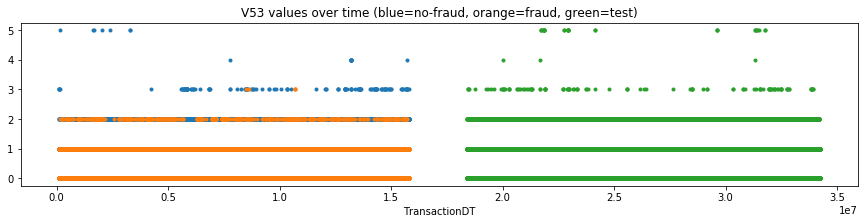

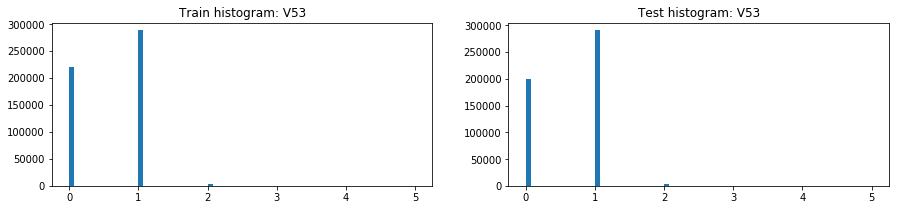

,V53,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.577586,0.443048,0.581956,0.604609,0.706132,0.580902
2,std,0.511571,0.565967,0.509111,0.507702,0.481786,0.510668
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000
8,unique values,7.000000,5.000000,7.000000,7.000000,7.000000,7.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V53,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,288055,0.020774,5984,290128
1,0.0,221227,0.043331,9586,199557
2,-999.0,77096,0.058486,4509,12899
3,2.0,4006,0.144533,579,3961
4,3.0,140,0.035714,5,113
5,4.0,9,0.000000,0,3
6,5.0,7,0.000000,0,30


,V53,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,221227,0.043331,9586,199557
1,1.0,288055,0.020774,5984,290128
2,-999.0,77096,0.058486,4509,12899
3,2.0,4006,0.144533,579,3961
4,3.0,140,0.035714,5,113
5,4.0,9,0.000000,0,3
6,5.0,7,0.000000,0,30


,Column,Correlation with V53
0,V53,1.000000
1,V54,0.920436
2,V75,0.658947
3,V12,0.635155
4,V35,0.630985
5,V76,0.621525
208,V51,-0.435189
209,V71,-0.435866
210,V92,-0.445846
211,V42,-0.446543


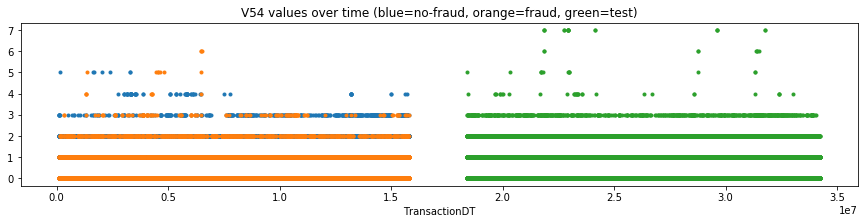

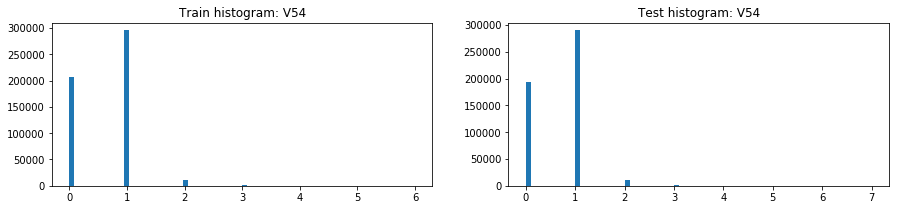

,V54,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.619982,0.510152,0.623550,0.634457,0.745555,0.608515
2,std,0.534635,0.654092,0.529922,0.535635,0.509076,0.538358
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,6.000000,5.000000,7.000000,5.000000,7.000000
8,unique values,8.000000,8.000000,7.000000,9.000000,7.000000,9.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V54,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,295235,0.020245,5977,289597
1,0.0,207068,0.044097,9131,192825
2,-999.0,77096,0.058486,4509,12899
3,2.0,10445,0.086644,905,10571
4,3.0,603,0.203980,123,728
5,4.0,76,0.105263,8,32
6,5.0,14,0.500000,7,13
7,6.0,3,1.000000,3,8


,V54,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,207068,0.044097,9131,192825
1,1.0,295235,0.020245,5977,289597
2,-999.0,77096,0.058486,4509,12899
3,2.0,10445,0.086644,905,10571
4,3.0,603,0.203980,123,728
5,4.0,76,0.105263,8,32
6,5.0,14,0.500000,7,13
7,6.0,3,1.000000,3,8


,Column,Correlation with V54
0,V54,1.000000
1,V53,0.920436
2,V76,0.668517
3,V13,0.643723
4,V36,0.640361
5,V75,0.622828
208,V31,-0.446002
209,V71,-0.447676
210,V42,-0.457589
211,V92,-0.458229


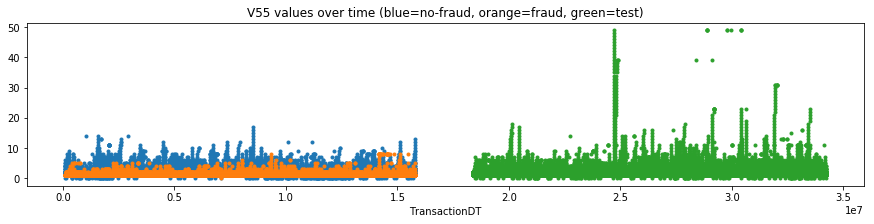

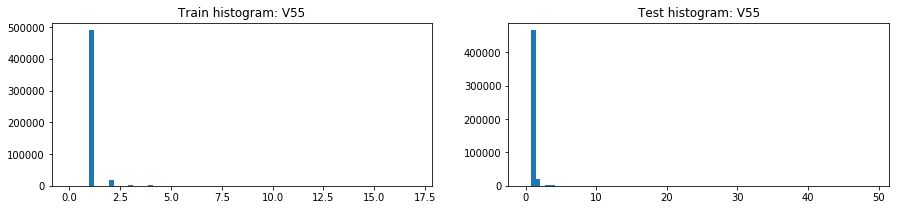

,V55,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,1.067670,1.176489,1.064136,1.092654,1.077144,1.096276
2,std,0.391364,0.584570,0.382941,0.666877,0.425291,0.711522
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,17.000000,8.000000,17.000000,49.000000,18.000000,49.000000
8,unique values,19.000000,10.000000,19.000000,51.000000,20.000000,51.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V55,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,489239,0.028828,14104,465610
1,-999.0,77096,0.058486,4509,12899
2,2.0,18464,0.087684,1619,21137
3,3.0,3100,0.082903,257,3706
4,4.0,1233,0.067315,83,1436
5,5.0,530,0.088679,47,654
6,6.0,300,0.026667,8,383
7,0.0,180,0.005556,1,139
8,7.0,144,0.020833,3,185
9,8.0,124,0.258065,32,116


,V55,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,489239,0.028828,14104,465610
1,-999.0,77096,0.058486,4509,12899
2,2.0,18464,0.087684,1619,21137
3,3.0,3100,0.082903,257,3706
4,4.0,1233,0.067315,83,1436
5,5.0,530,0.088679,47,654
6,8.0,124,0.258065,32,116
7,6.0,300,0.026667,8,383
8,7.0,144,0.020833,3,185
9,0.0,180,0.005556,1,139


,Column,Correlation with V55
0,V55,1.000000
1,V56,0.691925
2,V290,0.611955
3,V292,0.530908
4,V281,0.528348
5,V77,0.522321
375,V29,-0.096872
376,V49,-0.096944
377,V48,-0.099616
378,D2,-0.127195


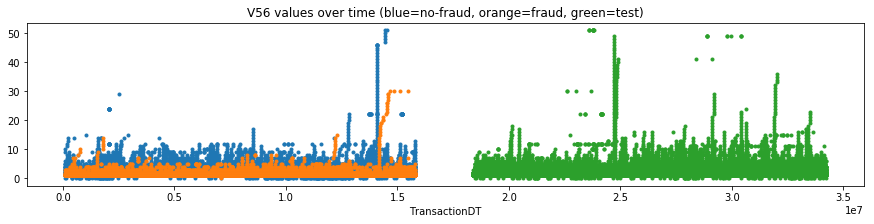

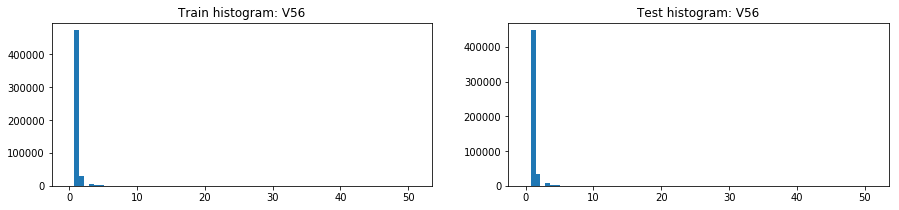

,V56,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,1.120979,1.346044,1.113668,1.155991,1.135385,1.160802
2,std,0.661129,1.198795,0.634752,0.831025,0.553395,0.883305
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,51.000000,30.000000,51.000000,51.000000,18.000000,51.000000
8,unique values,53.000000,32.000000,53.000000,52.000000,20.000000,52.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V56,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,472700,0.027373,12939,447151.0
1,-999.0,77096,0.058486,4509,12899.0
2,2.0,30886,0.070582,2180,33758.0
3,3.0,5610,0.097504,547,7192.0
4,4.0,1881,0.155768,293,2536.0
5,5.0,952,0.101891,97,1194.0
6,6.0,355,0.067606,24,549.0
7,7.0,246,0.073171,18,337.0
8,0.0,180,0.005556,1,136.0
9,8.0,169,0.059172,10,210.0


,V56,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,472700,0.027373,12939,447151
1,-999.0,77096,0.058486,4509,12899
2,2.0,30886,0.070582,2180,33758
3,3.0,5610,0.097504,547,7192
4,4.0,1881,0.155768,293,2536
5,5.0,952,0.101891,97,1194
6,6.0,355,0.067606,24,549
7,7.0,246,0.073171,18,337
8,8.0,169,0.059172,10,210
9,30.0,5,0.800000,4,7


,Column,Correlation with V56
0,V56,1.000000
1,V292,0.737437
2,V55,0.691925
3,V290,0.663716
4,V291,0.657934
5,V78,0.587449
375,V90,-0.097625
376,V29,-0.098005
377,V48,-0.098320
378,D7,-0.133099


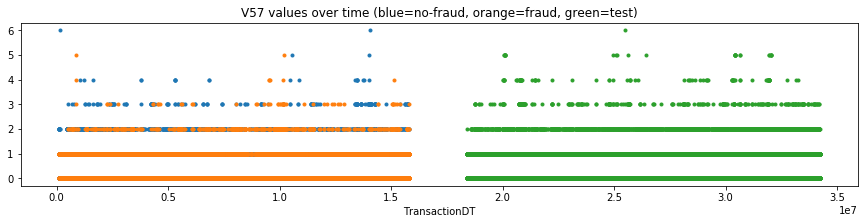

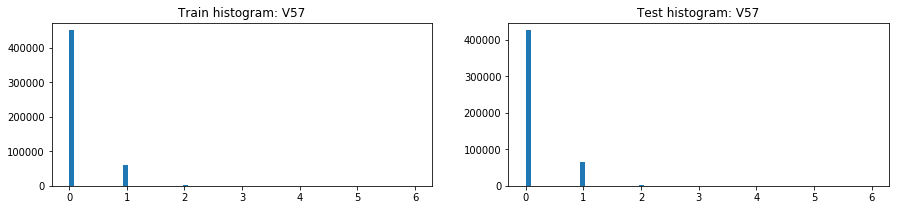

,V57,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.128312,0.455429,0.117686,0.145733,0.109603,0.154170
2,std,0.349094,0.575313,0.333895,0.375931,0.339790,0.383391
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000
8,unique values,8.000000,7.000000,8.000000,8.000000,7.000000,8.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V57,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,449807,0.020867,9386,425265
1,-999.0,77096,0.058486,4509,12899
2,1.0,61670,0.101313,6248,65642
3,2.0,1731,0.266320,461,2475
4,3.0,203,0.251232,51,299
5,4.0,27,0.222222,6,83
6,5.0,4,0.500000,2,27
7,6.0,2,0.000000,0,1


,V57,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,449807,0.020867,9386,425265
1,1.0,61670,0.101313,6248,65642
2,-999.0,77096,0.058486,4509,12899
3,2.0,1731,0.266320,461,2475
4,3.0,203,0.251232,51,299
5,4.0,27,0.222222,6,83
6,5.0,4,0.500000,2,27
7,6.0,2,0.000000,0,1


,Column,Correlation with V57
0,V57,1.000000
1,V58,0.962971
2,V15,0.958967
3,V71,0.943166
4,V73,0.940898
5,V50,0.938989
315,V53,-0.414989
316,V54,-0.426233
317,V35,-0.435636
318,V36,-0.445281


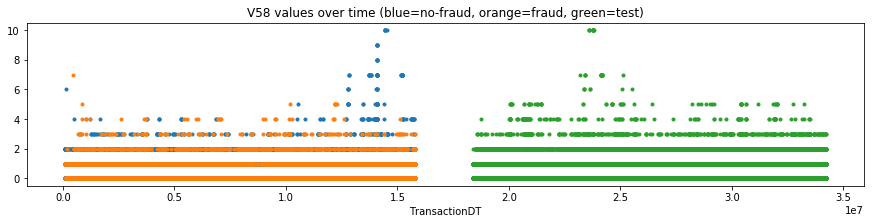

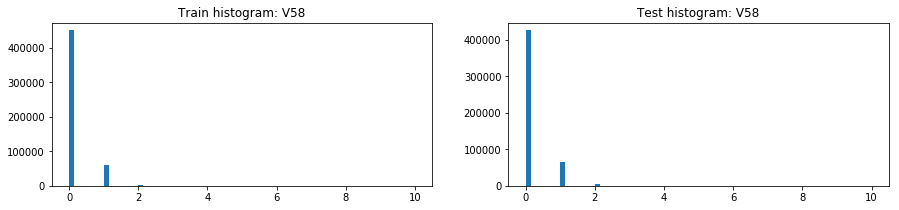

,V58,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.132453,0.490529,0.120821,0.150683,0.114299,0.159178
2,std,0.372907,0.650019,0.354333,0.400369,0.364030,0.407921
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,10.000000,7.000000,10.000000,10.000000,5.000000,10.000000
8,unique values,12.000000,8.000000,12.000000,10.000000,7.000000,10.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V58,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,449600,0.020812,9357,425256.0
1,-999.0,77096,0.058486,4509,12899.0
2,1.0,60662,0.096848,5875,63921.0
3,2.0,2675,0.285981,765,3789.0
4,3.0,300,0.400000,120,596.0
5,4.0,105,0.266667,28,129.0
6,7.0,45,0.022222,1,18.0
7,5.0,31,0.258065,8,65.0
8,6.0,10,0.000000,0,7.0
9,10.0,6,0.000000,0,11.0


,V58,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,449600,0.020812,9357,425256
1,1.0,60662,0.096848,5875,63921
2,-999.0,77096,0.058486,4509,12899
3,2.0,2675,0.285981,765,3789
4,3.0,300,0.400000,120,596
5,4.0,105,0.266667,28,129
6,5.0,31,0.258065,8,65
7,7.0,45,0.022222,1,18
8,6.0,10,0.000000,0,7
9,10.0,6,0.000000,0,11


,Column,Correlation with V58
0,V58,1.000000
1,V57,0.962971
2,V79,0.947932
3,V72,0.943713
4,V15,0.926226
5,V71,0.908084
315,V53,-0.401025
316,V54,-0.411891
317,V35,-0.420375
318,V36,-0.429683


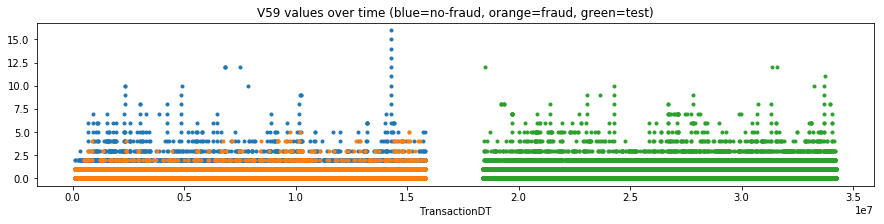

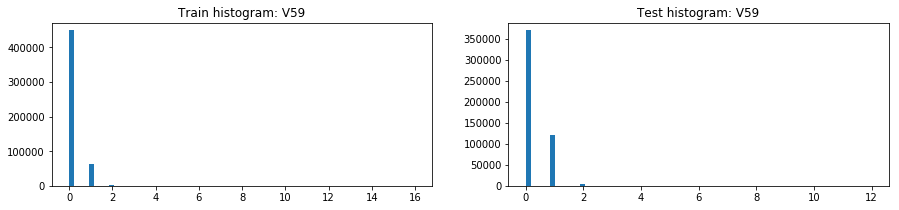

,V59,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.134433,0.452334,0.124107,0.266398,0.123735,0.299708
2,std,0.379291,0.600346,0.365292,0.486771,0.387794,0.501294
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,16.000000,5.000000,16.000000,12.000000,12.000000,12.000000
8,unique values,18.000000,7.000000,18.000000,14.000000,11.000000,14.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V59,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,448636,0.021298,9555,369048.0
1,-999.0,77096,0.058486,4509,12899.0
2,1.0,61876,0.097760,6049,119715.0
3,2.0,2264,0.190813,432,4054.0
4,3.0,388,0.211340,82,605.0
5,4.0,148,0.216216,32,171.0
6,5.0,62,0.064516,4,91.0
7,6.0,29,0.000000,0,43.0
8,7.0,13,0.000000,0,36.0
9,8.0,7,0.000000,0,17.0


,V59,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,448636,0.021298,9555,369048.0
1,1.0,61876,0.097760,6049,119715.0
2,-999.0,77096,0.058486,4509,12899.0
3,2.0,2264,0.190813,432,4054.0
4,3.0,388,0.211340,82,605.0
5,4.0,148,0.216216,32,171.0
6,5.0,62,0.064516,4,91.0
7,12.0,5,0.000000,0,3.0
8,15.0,1,0.000000,0,NaN
9,14.0,1,0.000000,0,NaN


,Column,Correlation with V59
0,V59,1.000000
1,V60,0.953204
2,V63,0.934990
3,V302,0.925841
4,V21,0.905885
5,V80,0.901617
362,V13,-0.393512
363,V53,-0.400171
364,V35,-0.400450
365,V36,-0.409316


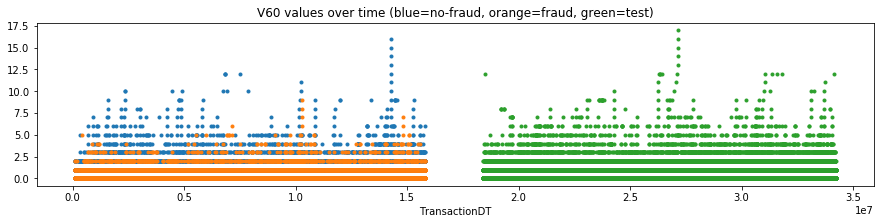

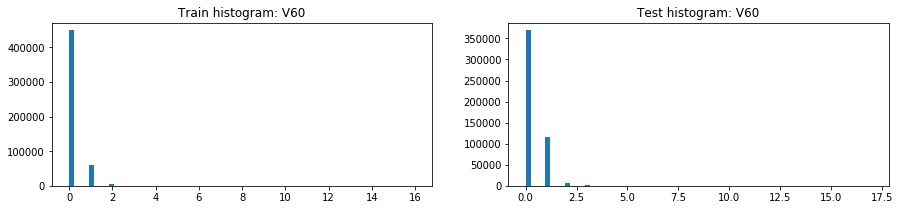

,V60,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.142537,0.492819,0.131159,0.280408,0.134690,0.314432
2,std,0.418230,0.688078,0.401378,0.539676,0.438684,0.555163
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,16.000000,9.000000,16.000000,17.000000,12.000000,17.000000
8,unique values,18.000000,11.000000,18.000000,19.000000,11.000000,19.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V60,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,448369,0.021177,9495,368830
1,-999.0,77096,0.058486,4509,12899
2,1.0,59589,0.095370,5683,115570
3,2.0,4065,0.187946,764,7218
4,3.0,854,0.159251,136,1291
5,4.0,296,0.175676,52,432
6,5.0,137,0.124088,17,197
7,6.0,52,0.057692,3,122
8,7.0,24,0.083333,2,51
9,9.0,21,0.047619,1,27


,V60,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,448369,0.021177,9495,368830
1,1.0,59589,0.095370,5683,115570
2,-999.0,77096,0.058486,4509,12899
3,2.0,4065,0.187946,764,7218
4,3.0,854,0.159251,136,1291
5,4.0,296,0.175676,52,432
6,5.0,137,0.124088,17,197
7,6.0,52,0.057692,3,122
8,7.0,24,0.083333,2,51
9,8.0,17,0.058824,1,26


,Column,Correlation with V60
0,V60,1.000000
1,V59,0.953204
2,V302,0.914733
3,V304,0.906584
4,V64,0.901516
5,V63,0.892258
362,V13,-0.377977
363,V35,-0.384247
364,V53,-0.384792
365,V36,-0.392754


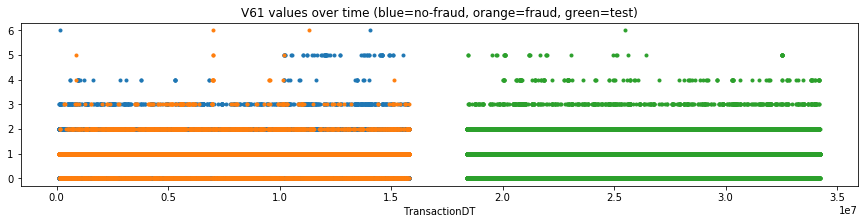

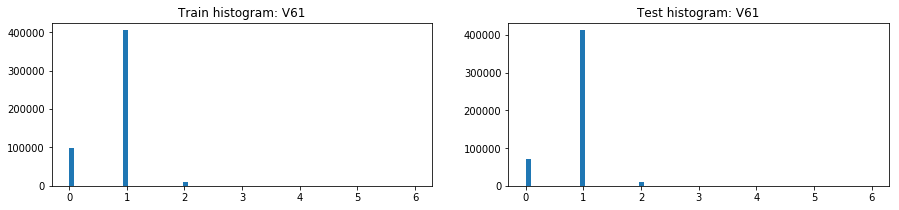

,V61,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.829785,0.949486,0.825896,0.879980,0.855596,0.885674
2,std,0.436617,0.503119,0.433733,0.397378,0.427601,0.389764
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,6.000000,6.000000,6.000000,5.000000,6.000000
8,unique values,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V61,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,404182,0.031288,12646,412011
1,0.0,98827,0.022808,2254,70995
2,-999.0,77096,0.058486,4509,12899
3,2.0,9620,0.113825,1095,10041
4,3.0,702,0.202279,142,583
5,5.0,60,0.066667,4,35
6,4.0,49,0.224490,11,126
7,6.0,4,0.500000,2,1


,V61,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,404182,0.031288,12646,412011
1,-999.0,77096,0.058486,4509,12899
2,0.0,98827,0.022808,2254,70995
3,2.0,9620,0.113825,1095,10041
4,3.0,702,0.202279,142,583
5,4.0,49,0.224490,11,126
6,5.0,60,0.066667,4,35
7,6.0,4,0.500000,2,1


,Column,Correlation with V61
0,V61,1.000000
1,V62,0.890257
2,V82,0.697912
3,V19,0.682139
4,V20,0.632256
5,V83,0.629035
375,V328,-0.485598
376,V329,-0.485859
377,V330,-0.499854
378,V327,-0.546545


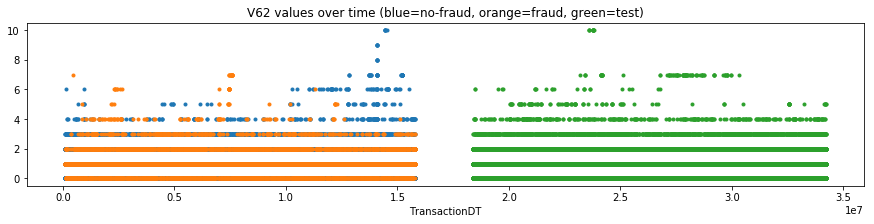

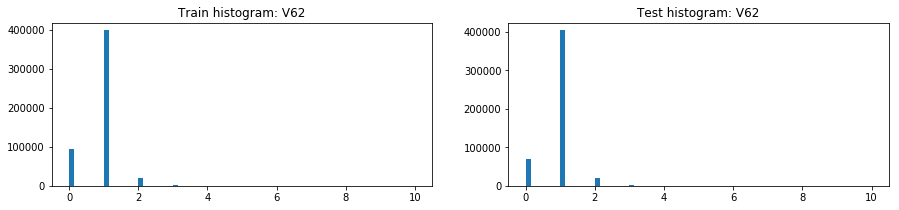

,V62,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.867563,1.061904,0.861250,0.912862,0.892762,0.917556
2,std,0.483803,0.685393,0.474493,0.452732,0.477507,0.446619
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,10.000000,7.000000,10.000000,10.000000,6.000000,10.000000
8,unique values,12.000000,9.000000,12.000000,10.000000,8.000000,10.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V62,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,398513,0.029971,11944,403691.0
1,0.0,93177,0.021711,2023,68371.0
2,-999.0,77096,0.058486,4509,12899.0
3,2.0,19368,0.083695,1621,19204.0
4,3.0,1860,0.222581,414,1918.0
5,4.0,287,0.324042,93,378.0
6,6.0,82,0.256098,21,24.0
7,5.0,78,0.243590,19,110.0
8,7.0,63,0.301587,19,85.0
9,10.0,6,0.000000,0,11.0


,V62,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,398513,0.029971,11944,403691
1,-999.0,77096,0.058486,4509,12899
2,0.0,93177,0.021711,2023,68371
3,2.0,19368,0.083695,1621,19204
4,3.0,1860,0.222581,414,1918
5,4.0,287,0.324042,93,378
6,6.0,82,0.256098,21,24
7,5.0,78,0.243590,19,110
8,7.0,63,0.301587,19,85
9,10.0,6,0.000000,0,11


,Column,Correlation with V62
0,V62,1.000000
1,V61,0.890257
2,V83,0.683948
3,V20,0.633815
4,V82,0.629571
5,V19,0.615758
375,V328,-0.480924
376,V329,-0.480941
377,V330,-0.494861
378,V327,-0.539304


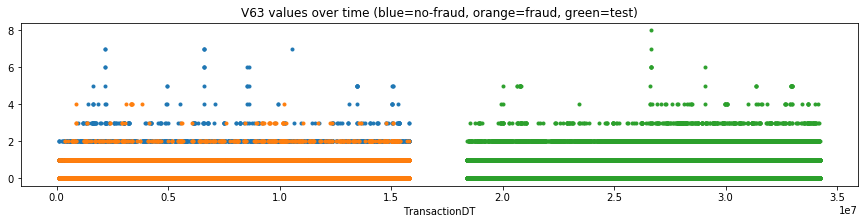

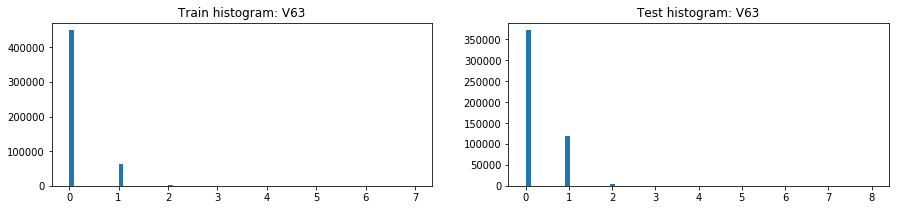

,V63,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.130743,0.433020,0.120923,0.256800,0.116963,0.289452
2,std,0.355262,0.557809,0.342257,0.460787,0.344637,0.478055
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
7,max,7.000000,4.000000,7.000000,8.000000,5.000000,8.000000
8,unique values,9.000000,6.000000,9.000000,10.000000,7.000000,10.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V63,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,448961,0.021425,9619,371489
1,-999.0,77096,0.058486,4509,12899
2,1.0,62231,0.098600,6136,118419
3,2.0,1969,0.176232,347,3388
4,3.0,221,0.194570,43,415
5,4.0,32,0.281250,9,49
6,5.0,17,0.000000,0,25
7,6.0,7,0.000000,0,5
8,7.0,6,0.000000,0,1


,V63,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,448961,0.021425,9619,371489
1,1.0,62231,0.098600,6136,118419
2,-999.0,77096,0.058486,4509,12899
3,2.0,1969,0.176232,347,3388
4,3.0,221,0.194570,43,415
5,4.0,32,0.281250,9,49
6,5.0,17,0.000000,0,25
7,6.0,7,0.000000,0,5
8,7.0,6,0.000000,0,1


,Column,Correlation with V63
0,V63,1.000000
1,V84,0.955156
2,V42,0.953351
3,V21,0.946929
4,V64,0.944450
5,V59,0.934990
362,V13,-0.408630
363,V53,-0.415508
364,V35,-0.417907
365,V54,-0.426767


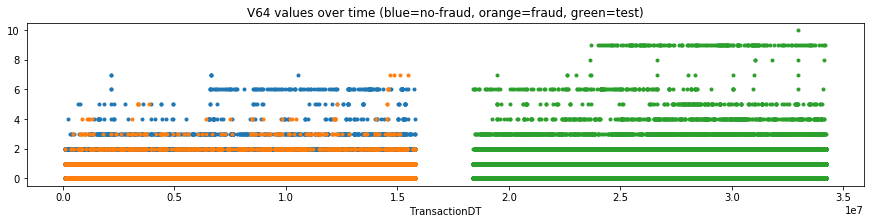

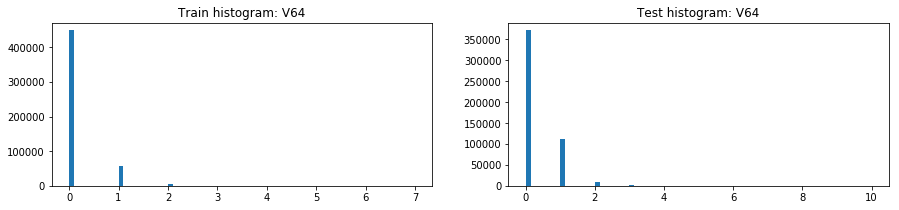

,V64,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.141825,0.480686,0.130817,0.279527,0.132069,0.313957
2,std,0.406157,0.664032,0.390062,0.554101,0.417240,0.576026
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
7,max,7.000000,7.000000,7.000000,10.000000,7.000000,10.000000
8,unique values,9.000000,9.000000,9.000000,12.000000,9.000000,12.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V64,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,448662,0.021301,9557,371179
1,-999.0,77096,0.058486,4509,12899
2,1.0,58547,0.097187,5690,112063
3,2.0,5145,0.139359,717,8094
4,3.0,757,0.195509,148,1467
5,6.0,144,0.027778,4,149
6,4.0,118,0.211864,25,460
7,5.0,61,0.147541,9,187
8,7.0,10,0.400000,4,12


,V64,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,448662,0.021301,9557,371179
1,1.0,58547,0.097187,5690,112063
2,-999.0,77096,0.058486,4509,12899
3,2.0,5145,0.139359,717,8094
4,3.0,757,0.195509,148,1467
5,4.0,118,0.211864,25,460
6,5.0,61,0.147541,9,187
7,6.0,144,0.027778,4,149
8,7.0,10,0.400000,4,12


,Column,Correlation with V64
0,V64,1.000000
1,V63,0.944450
2,V43,0.920388
3,V85,0.916422
4,V42,0.912230
5,V84,0.902824
362,V13,-0.387476
363,V53,-0.394248
364,V35,-0.400360
365,V54,-0.404930


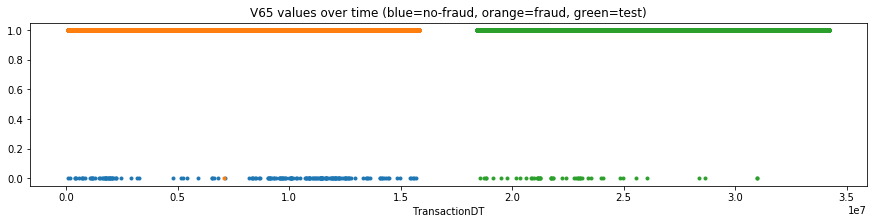

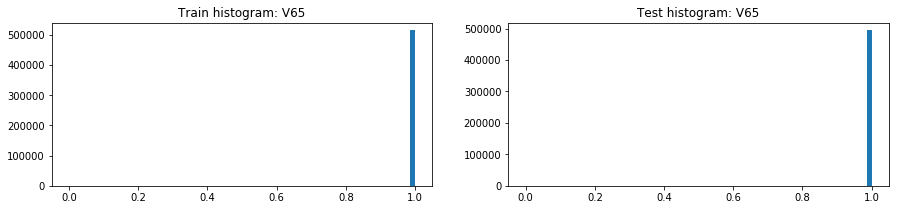

,V65,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.999663,0.999938,0.999654,0.999907,0.999754,0.999943
2,std,0.018353,0.007868,0.018595,0.009651,0.015684,0.007580
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,unique values,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V65,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,513271,0.031471,16153,493746
1,-999.0,77096,0.058486,4509,12899
2,0.0,173,0.005780,1,46


,V65,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,513271,0.031471,16153,493746
1,-999.0,77096,0.058486,4509,12899
2,0.0,173,0.005780,1,46


,Column,Correlation with V65
0,V65,1.000000
1,V41,0.891086
2,V14,0.844338
3,V88,0.794566
4,V326,0.102486
5,V46,0.101337
361,V155,-0.068624
362,V148,-0.068719
363,V154,-0.068750
364,V153,-0.069100


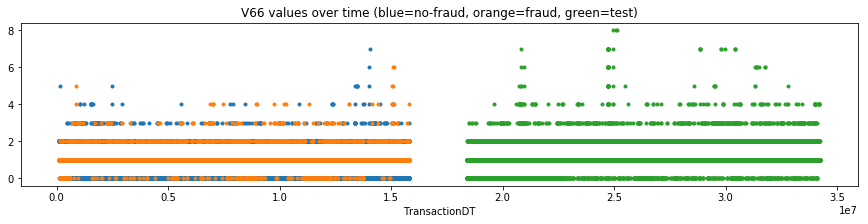

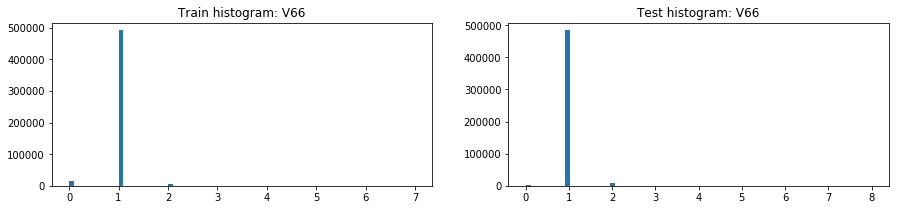

,V66,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.00000,93474.000000,400319.000000
1,mean,0.981038,1.026185,0.979571,1.01544,1.007039,1.017401
2,std,0.216235,0.363635,0.209554,0.17070,0.181799,0.167942
3,min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
7,max,7.000000,6.000000,7.000000,8.00000,7.000000,8.000000
8,unique values,9.000000,8.000000,9.000000,10.00000,9.000000,10.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.00000,7865.000000,5034.000000


,V66,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,490779,0.029563,14509,483557
1,-999.0,77096,0.058486,4509,12899
2,0.0,16418,0.041479,681,1828
3,2.0,5897,0.145159,856,7692
4,3.0,285,0.291228,83,523
5,4.0,50,0.400000,20,124
6,5.0,11,0.272727,3,25
7,6.0,3,0.666667,2,19
8,7.0,1,0.000000,0,21


,V66,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,490779,0.029563,14509,483557
1,-999.0,77096,0.058486,4509,12899
2,2.0,5897,0.145159,856,7692
3,0.0,16418,0.041479,681,1828
4,3.0,285,0.291228,83,523
5,4.0,50,0.400000,20,124
6,5.0,11,0.272727,3,25
7,6.0,3,0.666667,2,19
8,7.0,1,0.000000,0,21


,Column,Correlation with V66
0,V66,1.000000
1,V67,0.828164
2,V25,0.556169
3,V26,0.469765
4,V61,0.362676
5,V62,0.309893
375,V90,-0.050056
376,V49,-0.051580
377,V48,-0.052023
378,D8,-0.065071


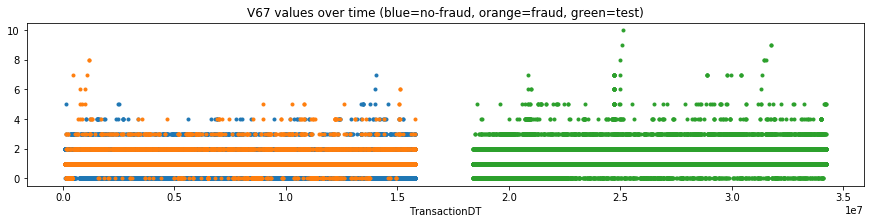

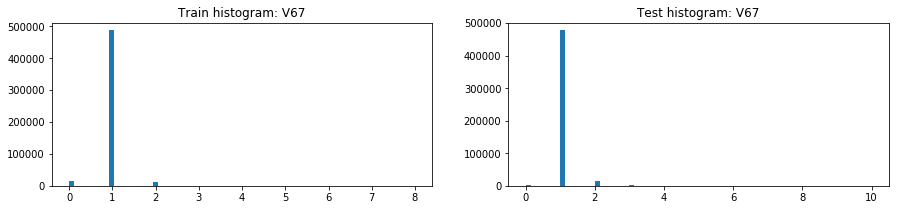

,V67,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.998121,1.102080,0.994744,1.031714,1.025376,1.033194
2,std,0.245912,0.484941,0.233315,0.220386,0.231832,0.217600
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,8.000000,8.000000,7.000000,10.000000,7.000000,10.000000
8,unique values,10.000000,10.000000,9.000000,12.000000,9.000000,12.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V67,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,486457,0.028220,13728,476992
1,-999.0,77096,0.058486,4509,12899
2,0.0,14565,0.040783,594,1567
3,2.0,11435,0.133013,1521,13732
4,3.0,844,0.287915,243,1215
5,4.0,112,0.446429,50,166
6,5.0,21,0.476190,10,76
7,6.0,5,0.800000,4,14
8,7.0,3,0.666667,2,22
9,8.0,2,1.000000,2,4


,V67,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,486457,0.028220,13728,476992
1,-999.0,77096,0.058486,4509,12899
2,2.0,11435,0.133013,1521,13732
3,0.0,14565,0.040783,594,1567
4,3.0,844,0.287915,243,1215
5,4.0,112,0.446429,50,166
6,5.0,21,0.476190,10,76
7,6.0,5,0.800000,4,14
8,7.0,3,0.666667,2,22
9,8.0,2,1.000000,2,4


,Column,Correlation with V67
0,V67,1.000000
1,V66,0.828164
2,V26,0.477727
3,V25,0.466775
4,V62,0.348448
5,V61,0.305829
375,V49,-0.075007
376,D8,-0.075841
377,V90,-0.078583
378,V48,-0.078884


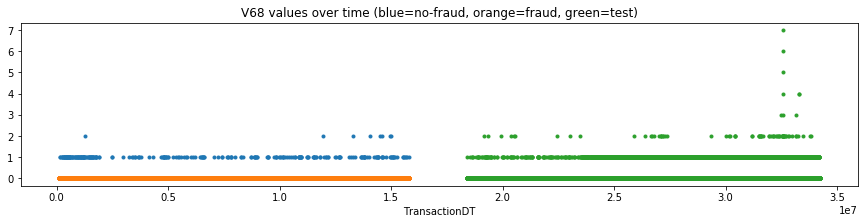

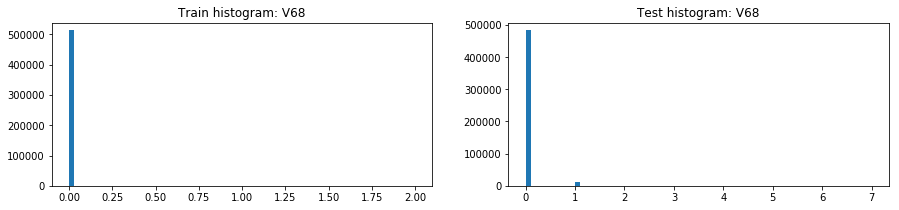

,V68,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.0000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.000534,0.0000,0.000551,0.023170,0.000974,0.028352
2,std,0.023760,0.0000,0.024142,0.152382,0.033181,0.168057
3,min,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
7,max,2.000000,0.0000,2.000000,7.000000,2.000000,7.000000
8,unique values,4.000000,2.0000,4.000000,9.000000,4.000000,9.000000
9,NaNs,77096.000000,4509.0000,72587.000000,12899.000000,7865.000000,5034.000000


,V68,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,513178,0.031478,16154,482453
1,-999.0,77096,0.058486,4509,12899
2,1.0,258,0.000000,0,11258
3,2.0,8,0.000000,0,72


,V68,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,513178,0.031478,16154,482453
1,-999.0,77096,0.058486,4509,12899
2,1.0,258,0.000000,0,11258
3,2.0,8,0.000000,0,72


,Column,Correlation with V68
0,V68,1.000000
1,V28,0.914602
2,V89,0.913305
3,V27,0.889336
4,C3,0.554881
5,V267,0.182594
361,V329,-0.096100
362,V328,-0.097364
363,V330,-0.099198
364,V327,-0.116910


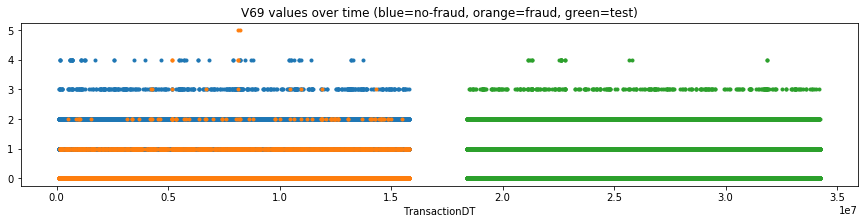

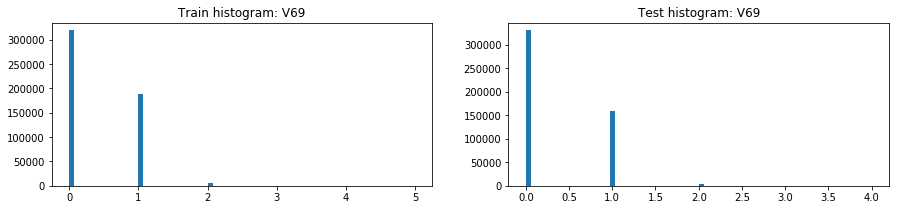

,V69,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.390200,0.092299,0.399877,0.339386,0.407226,0.323547
2,std,0.513696,0.321093,0.515878,0.494510,0.514653,0.488333
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000
8,unique values,7.000000,7.000000,6.000000,6.000000,6.000000,6.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V69,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,319136,0.046331,14786,330879.0
1,1.0,188826,0.006715,1268,158570.0
2,-999.0,77096,0.058486,4509,12899.0
3,2.0,4989,0.017037,85,4031.0
4,3.0,432,0.020833,9,294.0
5,4.0,59,0.067797,4,18.0
6,5.0,2,1.000000,2,NaN


,V69,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,319136,0.046331,14786,330879.0
1,-999.0,77096,0.058486,4509,12899.0
2,1.0,188826,0.006715,1268,158570.0
3,2.0,4989,0.017037,85,4031.0
4,3.0,432,0.020833,9,294.0
5,4.0,59,0.067797,4,18.0
6,5.0,2,1.000000,2,NaN


,Column,Correlation with V69
0,V69,1.000000
1,V70,0.962134
2,V90,0.925255
3,V29,0.914609
4,V48,0.912198
5,V91,0.891153
208,V92,-0.296978
209,V94,-0.305878
210,V52,-0.309717
211,V51,-0.313297


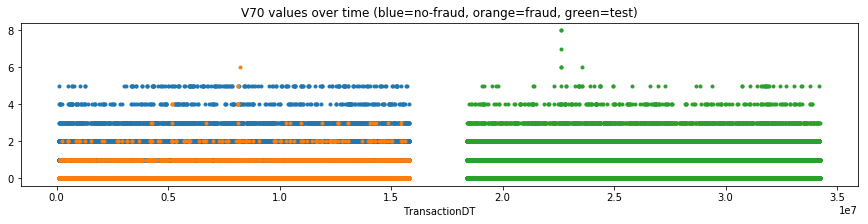

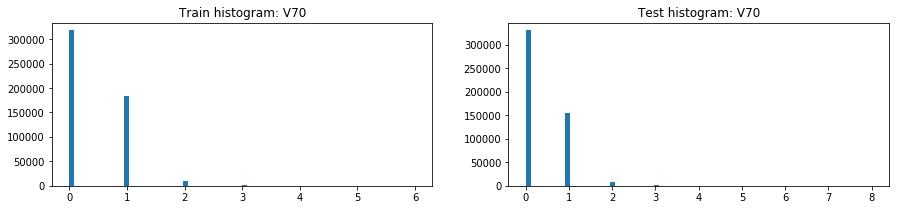

,V70,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.407924,0.097499,0.418008,0.353799,0.423701,0.337478
2,std,0.554499,0.344715,0.557105,0.530724,0.549443,0.524920
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,6.000000,5.000000,8.000000,5.000000,8.000000
8,unique values,8.000000,8.000000,7.000000,10.000000,7.000000,10.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V70,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,317801,0.046507,14780,330132
1,1.0,184177,0.006559,1208,154228
2,-999.0,77096,0.058486,4509,12899
3,2.0,9739,0.014375,140,8172
4,3.0,1296,0.015432,20,982
5,4.0,253,0.015810,4,216
6,5.0,177,0.005650,1,56
7,6.0,1,1.000000,1,3


,V70,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,317801,0.046507,14780,330132
1,-999.0,77096,0.058486,4509,12899
2,1.0,184177,0.006559,1208,154228
3,2.0,9739,0.014375,140,8172
4,3.0,1296,0.015432,20,982
5,4.0,253,0.015810,4,216
6,5.0,177,0.005650,1,56
7,6.0,1,1.000000,1,3


,Column,Correlation with V70
0,V70,1.000000
1,V69,0.962134
2,V91,0.907717
3,V90,0.896647
4,V30,0.894898
5,V49,0.891002
208,V92,-0.287514
209,V94,-0.296098
210,V52,-0.300571
211,V51,-0.304120


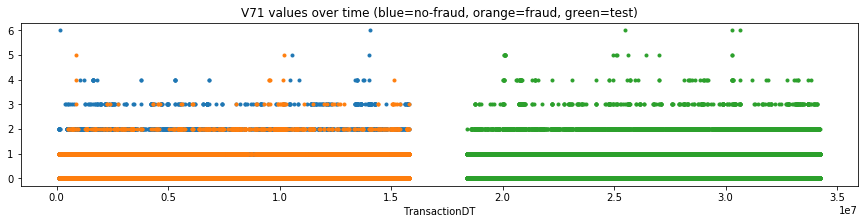

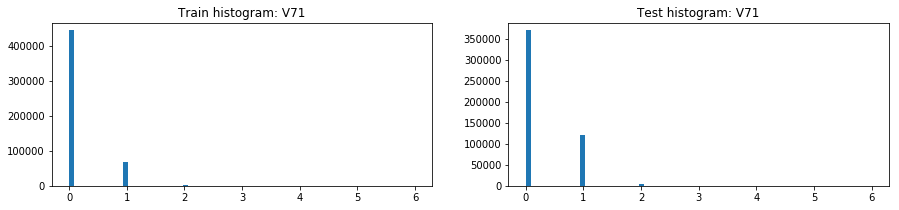

,V71,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.140639,0.457658,0.130340,0.258738,0.122408,0.290571
2,std,0.364303,0.575374,0.350576,0.459744,0.354751,0.475373
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000
8,unique values,8.000000,7.000000,8.000000,8.000000,7.000000,8.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V71,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,443821,0.021065,9349,370174
1,-999.0,77096,0.058486,4509,12899
2,1.0,67435,0.093216,6286,120022
3,2.0,1837,0.250408,460,3161
4,3.0,311,0.163987,51,342
5,4.0,34,0.176471,6,75
6,5.0,4,0.500000,2,15
7,6.0,2,0.000000,0,3


,V71,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,443821,0.021065,9349,370174
1,1.0,67435,0.093216,6286,120022
2,-999.0,77096,0.058486,4509,12899
3,2.0,1837,0.250408,460,3161
4,3.0,311,0.163987,51,342
5,4.0,34,0.176471,6,75
6,5.0,4,0.500000,2,15
7,6.0,2,0.000000,0,3


,Column,Correlation with V71
0,V71,1.000000
1,V50,0.964355
2,V72,0.963819
3,V92,0.960691
4,V31,0.958732
5,V57,0.943166
362,V160,-0.472643
363,V150,-0.472907
364,addr2,-0.499160
365,V151,-0.504865


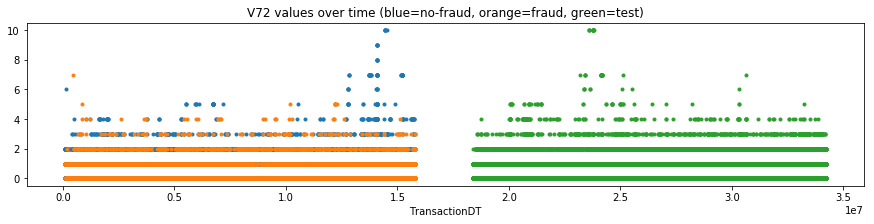

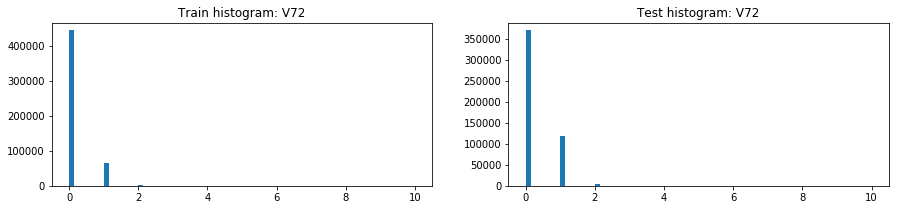

,V72,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.145124,0.492695,0.133833,0.264749,0.127490,0.296798
2,std,0.389212,0.649762,0.372346,0.481518,0.379355,0.496960
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,10.000000,7.000000,10.000000,10.000000,5.000000,10.000000
8,unique values,12.000000,8.000000,12.000000,10.000000,7.000000,10.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V72,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,443611,0.021009,9320,370131.0
1,-999.0,77096,0.058486,4509,12899.0
2,1.0,66364,0.089100,5913,117888.0
3,2.0,2802,0.273019,765,4879.0
4,3.0,413,0.288136,119,676.0
5,4.0,129,0.217054,28,134.0
6,5.0,54,0.148148,8,46.0
7,7.0,45,0.022222,1,19.0
8,6.0,10,0.000000,0,8.0
9,10.0,6,0.000000,0,11.0


,V72,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,443611,0.021009,9320,370131
1,1.0,66364,0.089100,5913,117888
2,-999.0,77096,0.058486,4509,12899
3,2.0,2802,0.273019,765,4879
4,3.0,413,0.288136,119,676
5,4.0,129,0.217054,28,134
6,5.0,54,0.148148,8,46
7,7.0,45,0.022222,1,19
8,6.0,10,0.000000,0,8
9,10.0,6,0.000000,0,11


,Column,Correlation with V72
0,V72,1.000000
1,V71,0.963819
2,V93,0.945832
3,V58,0.943713
4,V50,0.931573
5,V92,0.931000
362,V35,-0.428671
363,V54,-0.432390
364,V36,-0.438162
365,V152,-0.453811


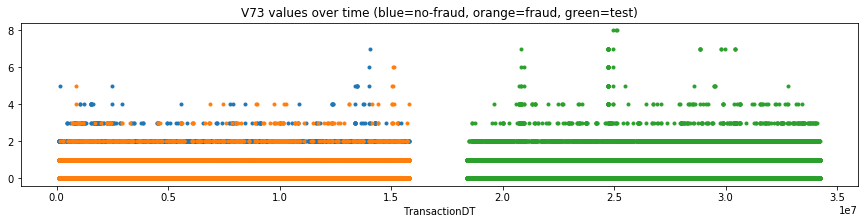

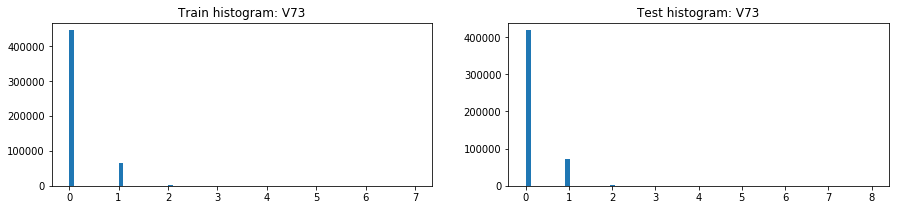

,V73,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.139982,0.494119,0.128478,0.162216,0.126656,0.170519
2,std,0.367098,0.605386,0.350753,0.397462,0.359843,0.405296
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,7.000000,6.000000,7.000000,8.000000,7.000000,8.000000
8,unique values,9.000000,8.000000,9.000000,10.000000,9.000000,10.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V73,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,444786,0.020124,8951,417899
1,-999.0,77096,0.058486,4509,12899
2,1.0,65814,0.099508,6549,72433
3,2.0,2551,0.218346,557,2991
4,3.0,235,0.323404,76,312
5,4.0,43,0.372093,16,98
6,5.0,11,0.272727,3,23
7,6.0,3,0.666667,2,12
8,7.0,1,0.000000,0,21


,V73,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,444786,0.020124,8951,417899
1,1.0,65814,0.099508,6549,72433
2,-999.0,77096,0.058486,4509,12899
3,2.0,2551,0.218346,557,2991
4,3.0,235,0.323404,76,312
5,4.0,43,0.372093,16,98
6,5.0,11,0.272727,3,23
7,6.0,3,0.666667,2,12
8,7.0,1,0.000000,0,21


,Column,Correlation with V73
0,V73,1.000000
1,V74,0.955264
2,V94,0.946165
3,V57,0.940898
4,V51,0.935877
5,V33,0.935625
328,V13,-0.378424
329,V54,-0.383893
330,V35,-0.401804
331,V36,-0.410823


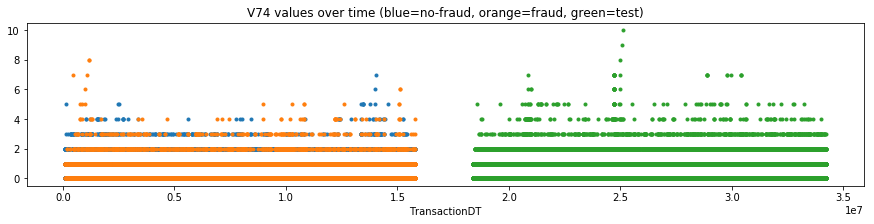

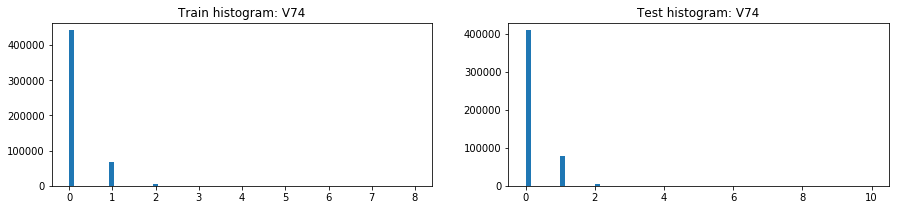

,V74,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,513444.000000,16154.000000,497290.000000,493792.000000,93474.000000,400319.000000
1,mean,0.152147,0.557818,0.138969,0.186044,0.149699,0.194530
2,std,0.393274,0.698917,0.371890,0.434991,0.402062,0.441897
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,8.000000,8.000000,7.000000,10.000000,7.000000,10.000000
8,unique values,10.000000,10.000000,9.000000,12.000000,9.000000,12.000000
9,NaNs,77096.000000,4509.000000,72587.000000,12899.000000,7865.000000,5034.000000


,V74,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,440878,0.019547,8618,409188
1,-999.0,77096,0.058486,4509,12899
2,1.0,67816,0.094373,6400,78706
3,2.0,4109,0.215381,885,4955
4,3.0,525,0.367619,193,693
5,4.0,86,0.476744,41,145
6,5.0,21,0.476190,10,68
7,6.0,4,0.750000,3,13
8,7.0,3,0.666667,2,21
9,8.0,2,1.000000,2,1


,V74,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,440878,0.019547,8618,409188
1,1.0,67816,0.094373,6400,78706
2,-999.0,77096,0.058486,4509,12899
3,2.0,4109,0.215381,885,4955
4,3.0,525,0.367619,193,693
5,4.0,86,0.476744,41,145
6,5.0,21,0.476190,10,68
7,6.0,4,0.750000,3,13
8,7.0,3,0.666667,2,21
9,8.0,2,1.000000,2,1


,Column,Correlation with V74
0,V74,1.000000
1,V73,0.955264
2,V94,0.910061
3,V51,0.905765
4,V33,0.900393
5,V57,0.900184
328,V54,-0.352602
329,V53,-0.354115
330,V35,-0.384744
331,V36,-0.387544


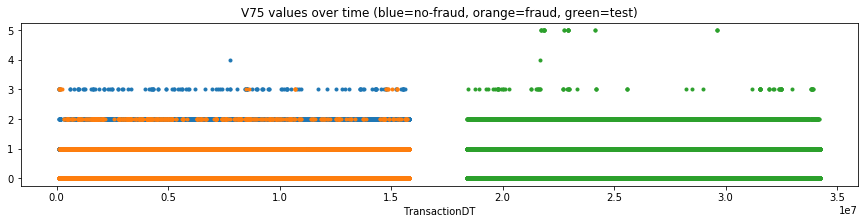

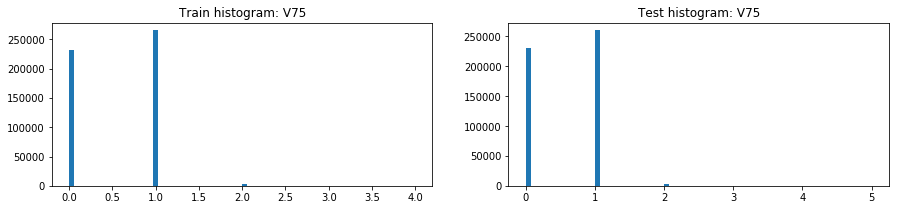

,V75,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.544278,0.398304,0.549210,0.538879,0.627842,0.517997
2,std,0.514318,0.545796,0.512495,0.512770,0.499932,0.513509
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,4.000000,3.000000,4.000000,5.000000,5.000000,5.000000
8,unique values,6.000000,5.000000,6.000000,7.000000,7.000000,6.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V75,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,265082,0.021239,5630,259969
1,0.0,232467,0.044385,10318,231432
2,-999.0,89164,0.047957,4276,12081
3,2.0,3676,0.114255,420,3106
4,3.0,150,0.126667,19,80
5,4.0,1,0.000000,0,1


,V75,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,232467,0.044385,10318,231432
1,1.0,265082,0.021239,5630,259969
2,-999.0,89164,0.047957,4276,12081
3,2.0,3676,0.114255,420,3106
4,3.0,150,0.126667,19,80
5,4.0,1,0.000000,0,1


,Column,Correlation with V75
0,V75,1.000000
1,V76,0.918449
2,V35,0.743539
3,V12,0.708756
4,V36,0.703356
5,V13,0.670498
208,V71,-0.411707
209,V42,-0.419077
210,V31,-0.420741
211,V92,-0.423442


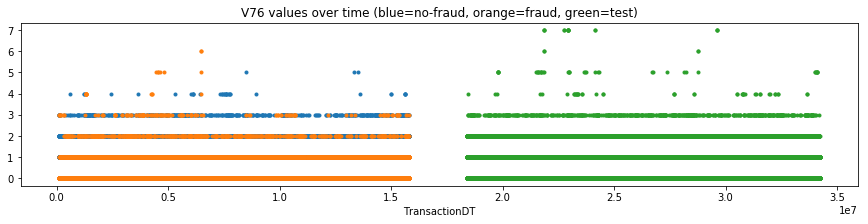

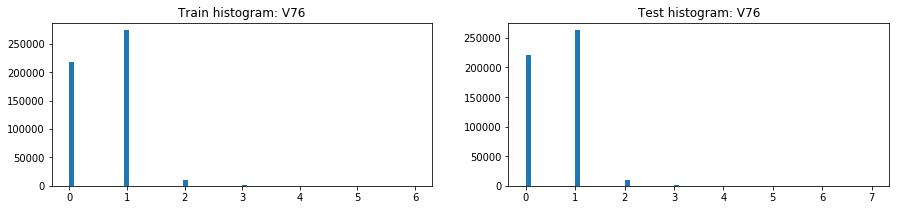

,V76,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.587557,0.451638,0.592150,0.573796,0.670194,0.551168
2,std,0.538230,0.624103,0.534486,0.542721,0.526512,0.543986
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,6.000000,5.000000,7.000000,5.000000,7.000000
8,unique values,8.000000,8.000000,7.000000,9.000000,7.000000,9.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V76,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,273293,0.020864,5702,262516
1,0.0,217817,0.045570,9926,221908
2,-999.0,89164,0.047957,4276,12081
3,2.0,9571,0.063421,607,9466
4,3.0,641,0.207488,133,617
5,4.0,43,0.255814,11,45
6,5.0,9,0.666667,6,38
7,6.0,2,1.000000,2,4


,V76,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,217817,0.045570,9926,221908
1,1.0,273293,0.020864,5702,262516
2,-999.0,89164,0.047957,4276,12081
3,2.0,9571,0.063421,607,9466
4,3.0,641,0.207488,133,617
5,4.0,43,0.255814,11,45
6,5.0,9,0.666667,6,38
7,6.0,2,1.000000,2,4


,Column,Correlation with V76
0,V76,1.000000
1,V75,0.918449
2,V36,0.746569
3,V13,0.719616
4,V35,0.704597
5,V12,0.671624
208,V71,-0.424893
209,V42,-0.430981
210,V31,-0.434187
211,V92,-0.436803


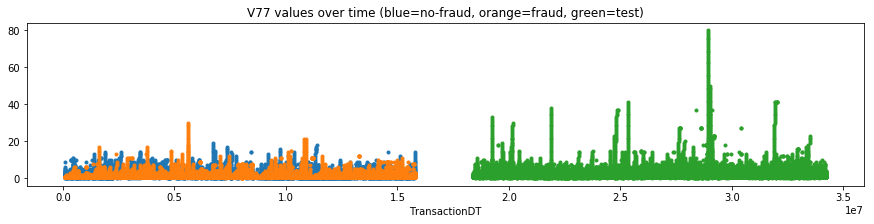

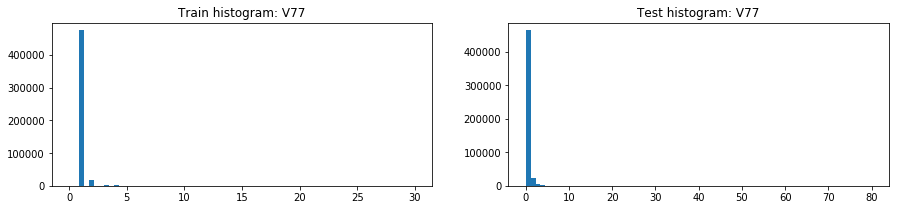

,V77,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,1.086893,1.546104,1.071377,1.123978,1.105911,1.128219
2,std,0.532958,1.677384,0.437279,1.020732,0.717580,1.079576
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,30.000000,30.000000,19.000000,80.000000,33.000000,80.000000
8,unique values,32.000000,32.000000,21.000000,82.000000,35.000000,82.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V77,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,474434,0.027321,12962,463392
1,-999.0,89164,0.047957,4276,12081
2,2.0,18955,0.089633,1699,22014
3,3.0,3695,0.169689,627,4221
4,4.0,1623,0.243993,396,1914
5,5.0,742,0.247978,184,855
6,0.0,571,0.019264,11,205
7,6.0,415,0.303614,126,584
8,7.0,297,0.370370,110,314
9,8.0,183,0.333333,61,242


,V77,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,474434,0.027321,12962,463392
1,-999.0,89164,0.047957,4276,12081
2,2.0,18955,0.089633,1699,22014
3,3.0,3695,0.169689,627,4221
4,4.0,1623,0.243993,396,1914
5,5.0,742,0.247978,184,855
6,6.0,415,0.303614,126,584
7,7.0,297,0.370370,110,314
8,9.0,157,0.420382,66,137
9,8.0,183,0.333333,61,242


,Column,Correlation with V77
0,V77,1.000000
1,V78,0.752716
2,V37,0.688616
3,V38,0.636275
4,V228,0.615251
5,V86,0.589516
375,V36,-0.114821
376,V12,-0.115449
377,V13,-0.118758
378,D8,-0.129262


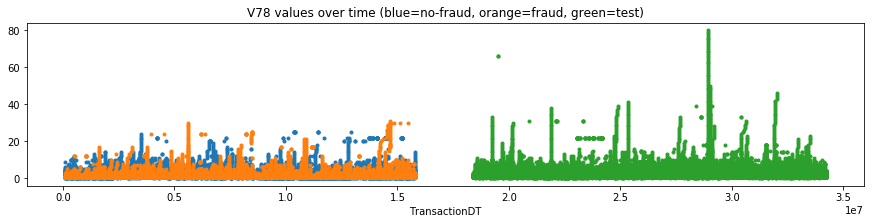

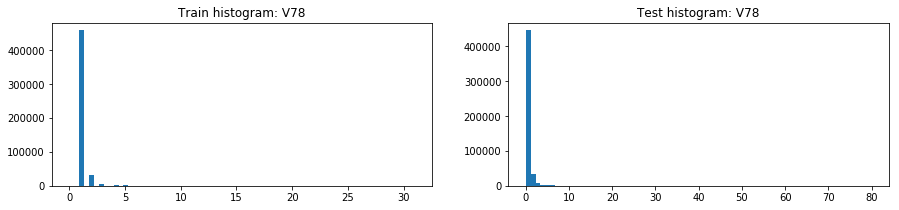

,V78,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,1.144462,1.783975,1.122854,1.191442,1.165185,1.197604
2,std,0.781474,2.366350,0.654110,1.167254,0.864204,1.227508
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
7,max,31.000000,31.000000,25.000000,80.000000,66.000000,80.000000
8,unique values,33.000000,33.000000,27.000000,82.000000,36.000000,82.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V78,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,457915,0.026145,11972,445500
1,-999.0,89164,0.047957,4276,12081
2,2.0,31364,0.068199,2139,34375
3,3.0,6135,0.143439,880,7032
4,4.0,2261,0.204334,462,2938
5,5.0,1125,0.232889,262,1431
6,6.0,609,0.270936,165,886
7,0.0,571,0.019264,11,202
8,7.0,353,0.303116,107,463
9,8.0,211,0.327014,69,402


,V78,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,457915,0.026145,11972,445500
1,-999.0,89164,0.047957,4276,12081
2,2.0,31364,0.068199,2139,34375
3,3.0,6135,0.143439,880,7032
4,4.0,2261,0.204334,462,2938
5,5.0,1125,0.232889,262,1431
6,6.0,609,0.270936,165,886
7,7.0,353,0.303116,107,463
8,8.0,211,0.327014,69,402
9,9.0,157,0.312102,49,298


,Column,Correlation with V78
0,V78,1.000000
1,V77,0.752716
2,V38,0.633121
3,V56,0.587449
4,V37,0.537413
5,V87,0.535899
375,V13,-0.105462
376,V53,-0.105782
377,D8,-0.128558
378,D2,-0.128967


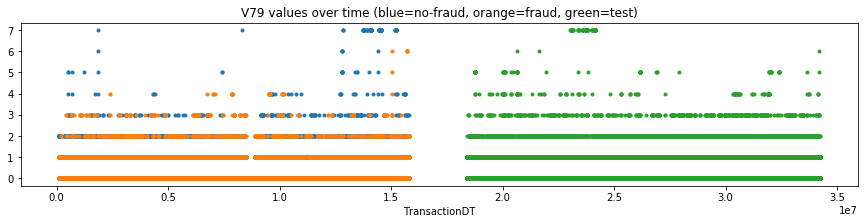

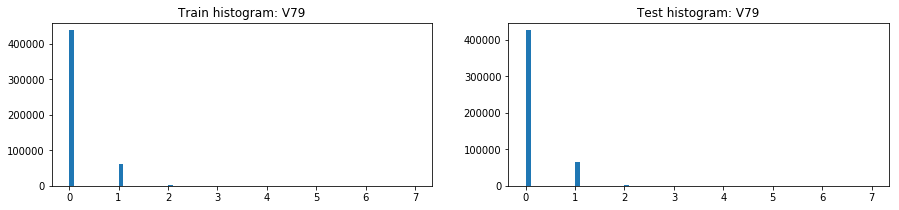

,V79,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.136867,0.538109,0.123310,0.150820,0.115399,0.159133
2,std,0.379904,0.667046,0.358534,0.399481,0.366889,0.406306
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,7.000000,6.000000,7.000000,7.000000,6.000000,7.000000
8,unique values,9.000000,8.000000,9.000000,9.000000,8.000000,9.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V79,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,436802,0.020149,8801,425386
1,-999.0,89164,0.047957,4276,12081
2,1.0,61751,0.107739,6653,65288
3,2.0,2179,0.316659,690,3020
4,3.0,435,0.464368,202,662
5,7.0,109,0.000000,0,64
6,4.0,68,0.485294,33,118
7,5.0,19,0.052632,1,69
8,6.0,13,0.538462,7,3


,V79,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,436802,0.020149,8801,425386
1,1.0,61751,0.107739,6653,65288
2,-999.0,89164,0.047957,4276,12081
3,2.0,2179,0.316659,690,3020
4,3.0,435,0.464368,202,662
5,4.0,68,0.485294,33,118
6,6.0,13,0.538462,7,3
7,5.0,19,0.052632,1,69
8,7.0,109,0.000000,0,64


,Column,Correlation with V79
0,V79,1.000000
1,V58,0.947932
2,V15,0.928438
3,V57,0.926381
4,V93,0.924026
5,V16,0.909113
315,V53,-0.415449
316,V35,-0.418987
317,V54,-0.426989
318,V36,-0.428184


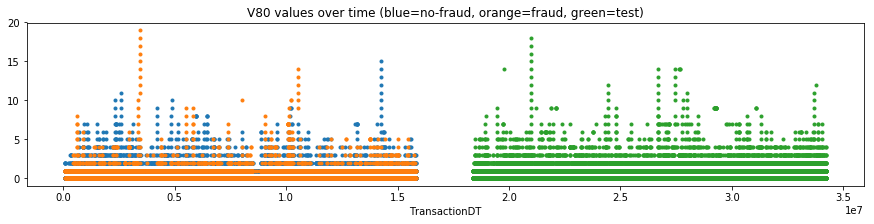

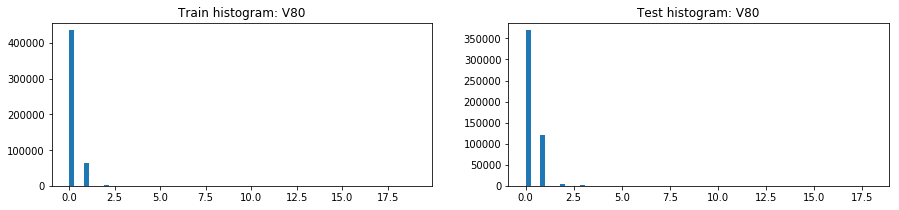

,V80,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.143954,0.546043,0.130368,0.270427,0.130959,0.303161
2,std,0.409932,0.865550,0.377840,0.508879,0.426872,0.520895
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,19.000000,19.000000,15.000000,18.000000,18.000000,14.000000
8,unique values,21.000000,21.000000,17.000000,20.000000,20.000000,16.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V80,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,434732,0.020751,9021,368894.0
1,-999.0,89164,0.047957,4276,12081.0
2,1.0,63368,0.103901,6584,120578.0
3,2.0,2283,0.215506,492,3797.0
4,3.0,475,0.235789,112,731.0
5,4.0,245,0.322449,79,281.0
6,5.0,112,0.330357,37,116.0
7,6.0,52,0.307692,16,69.0
8,7.0,48,0.354167,17,58.0
9,8.0,20,0.300000,6,18.0


,V80,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,434732,0.020751,9021,368894
1,1.0,63368,0.103901,6584,120578
2,-999.0,89164,0.047957,4276,12081
3,2.0,2283,0.215506,492,3797
4,3.0,475,0.235789,112,731
5,4.0,245,0.322449,79,281
6,5.0,112,0.330357,37,116
7,7.0,48,0.354167,17,58
8,6.0,52,0.307692,16,69
9,8.0,20,0.300000,6,18


,Column,Correlation with V80
0,V80,1.000000
1,V81,0.953223
2,V17,0.903466
3,V39,0.902400
4,V59,0.901617
5,V84,0.896386
362,V53,-0.388425
363,V13,-0.389988
364,V35,-0.391247
365,V54,-0.399214


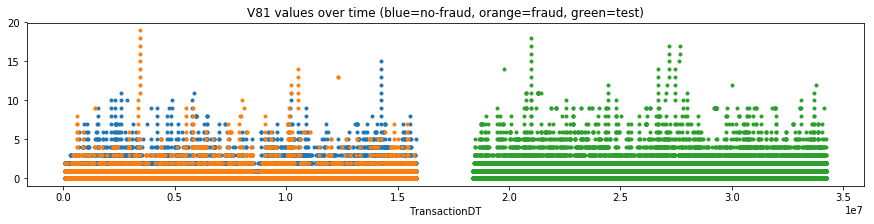

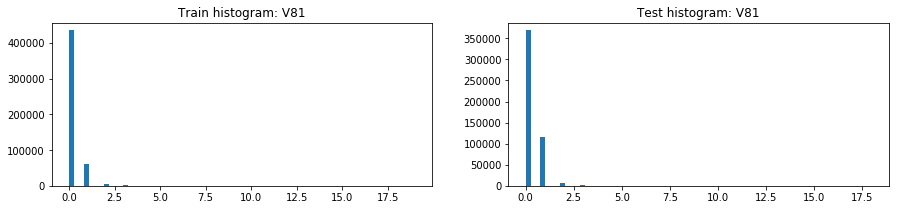

,V81,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.152696,0.601452,0.137533,0.285409,0.144413,0.318501
2,std,0.452298,0.976099,0.415043,0.568899,0.504404,0.578041
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,19.000000,19.000000,15.000000,18.000000,18.000000,17.000000
8,unique values,21.000000,21.000000,17.000000,20.000000,20.000000,19.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V81,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,434653,0.020702,8998,368726.0
1,-999.0,89164,0.047957,4276,12081.0
2,1.0,60829,0.100610,6120,116427.0
3,2.0,4033,0.189933,766,6846.0
4,3.0,902,0.268293,242,1313.0
5,4.0,509,0.245580,125,600.0
6,5.0,191,0.225131,43,270.0
7,6.0,106,0.339623,36,145.0
8,7.0,68,0.308824,21,98.0
9,8.0,29,0.275862,8,48.0


,V81,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,434653,0.020702,8998,368726
1,1.0,60829,0.100610,6120,116427
2,-999.0,89164,0.047957,4276,12081
3,2.0,4033,0.189933,766,6846
4,3.0,902,0.268293,242,1313
5,4.0,509,0.245580,125,600
6,5.0,191,0.225131,43,270
7,6.0,106,0.339623,36,145
8,7.0,68,0.308824,21,98
9,9.0,20,0.400000,8,79


,Column,Correlation with V81
0,V81,1.000000
1,V80,0.953223
2,V60,0.879026
3,V40,0.876484
4,V85,0.875131
5,V17,0.873443
362,V53,-0.373756
363,V13,-0.374584
364,V35,-0.376165
365,V54,-0.384137


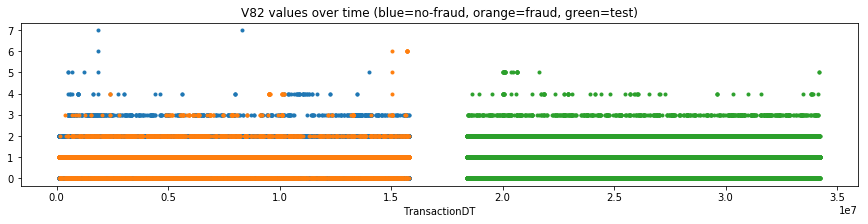

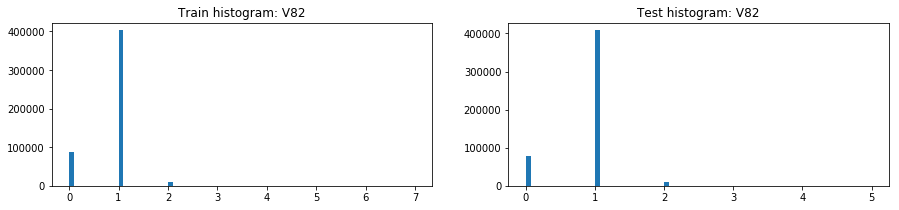

,V82,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.844610,0.962104,0.840640,0.864429,0.841420,0.869829
2,std,0.422529,0.490821,0.419453,0.403460,0.431988,0.396273
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,7.000000,6.000000,7.000000,5.000000,5.000000,5.000000
8,unique values,9.000000,8.000000,9.000000,7.000000,7.000000,7.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V82,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,402612,0.032736,13180,407790.0
1,-999.0,89164,0.047957,4276,12081.0
2,0.0,88757,0.022759,2020,77355.0
3,2.0,9288,0.109496,1017,8745.0
4,3.0,626,0.228435,143,629.0
5,4.0,76,0.250000,19,67.0
6,6.0,8,0.875000,7,NaN
7,5.0,7,0.142857,1,24.0
8,7.0,2,0.000000,0,NaN


,V82,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,402612,0.032736,13180,407790.0
1,-999.0,89164,0.047957,4276,12081.0
2,0.0,88757,0.022759,2020,77355.0
3,2.0,9288,0.109496,1017,8745.0
4,3.0,626,0.228435,143,629.0
5,4.0,76,0.250000,19,67.0
6,6.0,8,0.875000,7,NaN
7,5.0,7,0.142857,1,24.0
8,7.0,2,0.000000,0,NaN


,Column,Correlation with V82
0,V82,1.000000
1,V83,0.881632
2,V19,0.722277
3,V61,0.697912
4,V4,0.683717
5,V20,0.661167
375,V329,-0.177024
376,V224,-0.184503
377,D6,-0.227429
378,V327,-0.381177


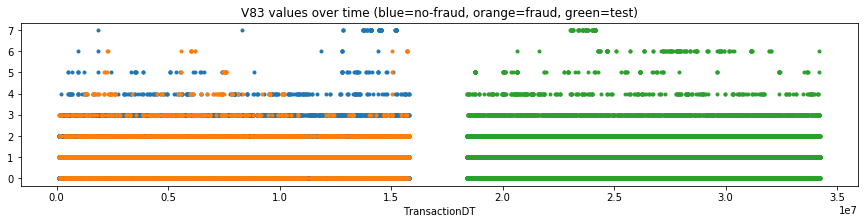

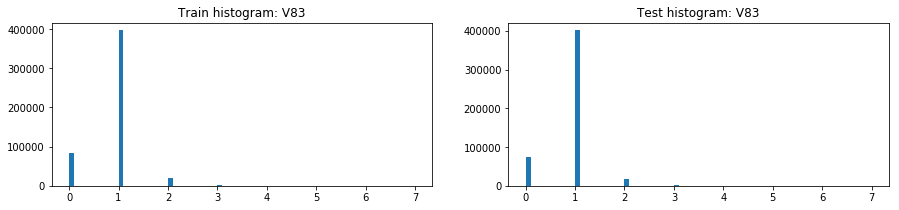

,V83,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.881965,1.059071,0.875981,0.896656,0.876486,0.901390
2,std,0.470757,0.621182,0.463645,0.454836,0.477224,0.449288
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,7.000000,6.000000,7.000000,7.000000,6.000000,7.000000
8,unique values,9.000000,8.000000,9.000000,9.000000,8.000000,9.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V83,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,396619,0.031857,12635,400827
1,-999.0,89164,0.047957,4276,12081
2,0.0,83605,0.020920,1749,74121
3,2.0,18834,0.077785,1465,17393
4,3.0,1816,0.226872,412,1709
5,4.0,292,0.318493,93,286
6,7.0,109,0.000000,0,64
7,5.0,76,0.210526,16,97
8,6.0,25,0.680000,17,113


,V83,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,396619,0.031857,12635,400827
1,-999.0,89164,0.047957,4276,12081
2,0.0,83605,0.020920,1749,74121
3,2.0,18834,0.077785,1465,17393
4,3.0,1816,0.226872,412,1709
5,4.0,292,0.318493,93,286
6,6.0,25,0.680000,17,113
7,5.0,76,0.210526,16,97
8,7.0,109,0.000000,0,64


,Column,Correlation with V83
0,V83,1.000000
1,V82,0.881632
2,V62,0.683948
3,V20,0.674453
4,V5,0.658500
5,V19,0.644119
375,D8,-0.151826
376,V329,-0.175486
377,D6,-0.175946
378,V327,-0.375414


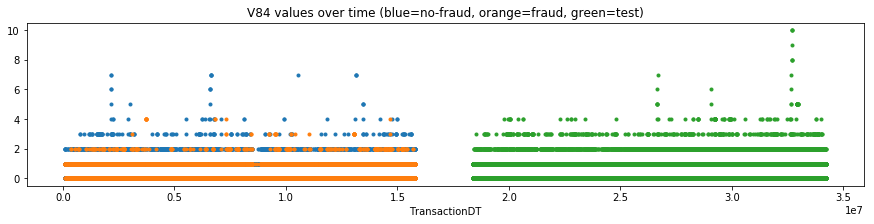

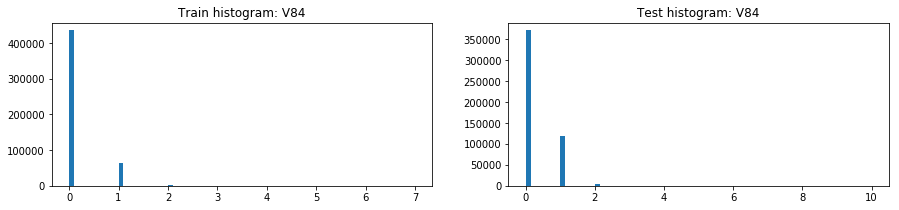

,V84,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.137145,0.470068,0.125896,0.258139,0.121206,0.290278
2,std,0.361875,0.554162,0.348039,0.463071,0.349349,0.480298
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
7,max,7.000000,4.000000,7.000000,10.000000,4.000000,10.000000
8,unique values,9.000000,6.000000,9.000000,12.000000,6.000000,12.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V84,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,435246,0.020910,9101,371522
1,-999.0,89164,0.047957,4276,12081
2,1.0,63848,0.108335,6917,119235
3,2.0,2035,0.162654,331,3307
4,3.0,191,0.146597,28,426
5,4.0,35,0.285714,10,84
6,7.0,10,0.000000,0,2
7,5.0,6,0.000000,0,24
8,6.0,5,0.000000,0,3


,V84,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,435246,0.020910,9101,371522
1,1.0,63848,0.108335,6917,119235
2,-999.0,89164,0.047957,4276,12081
3,2.0,2035,0.162654,331,3307
4,3.0,191,0.146597,28,426
5,4.0,35,0.285714,10,84
6,7.0,10,0.000000,0,2
7,5.0,6,0.000000,0,24
8,6.0,5,0.000000,0,3


,Column,Correlation with V84
0,V84,1.000000
1,V42,0.957588
2,V63,0.955156
3,V21,0.955048
4,V85,0.937156
5,V22,0.916949
362,V53,-0.420387
363,V13,-0.422154
364,V35,-0.425216
365,V54,-0.432063


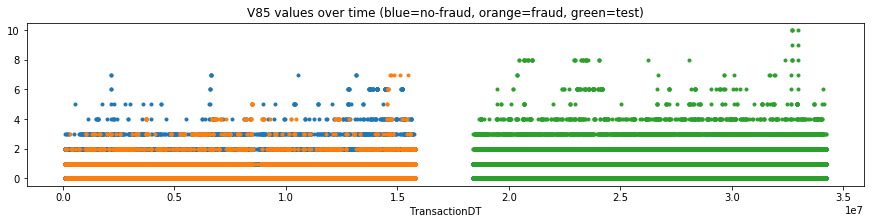

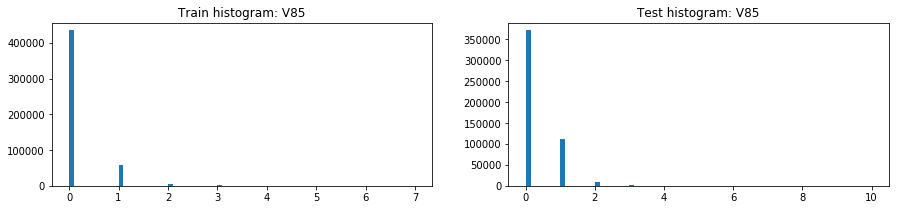

,V85,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.149788,0.535058,0.136770,0.279501,0.138446,0.312607
2,std,0.419445,0.707608,0.399721,0.535078,0.434581,0.550831
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
7,max,7.000000,7.000000,7.000000,10.000000,8.000000,10.000000
8,unique values,9.000000,9.000000,9.000000,12.000000,10.000000,12.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V85,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,435103,0.020862,9077,371150
1,-999.0,89164,0.047957,4276,12081
2,1.0,59565,0.105381,6277,112615
3,2.0,5322,0.138106,735,8175
4,3.0,987,0.207700,205,1937
5,4.0,216,0.342593,74,481
6,6.0,121,0.041322,5,104
7,5.0,47,0.191489,9,87
8,7.0,15,0.333333,5,13


,V85,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,435103,0.020862,9077,371150
1,1.0,59565,0.105381,6277,112615
2,-999.0,89164,0.047957,4276,12081
3,2.0,5322,0.138106,735,8175
4,3.0,987,0.207700,205,1937
5,4.0,216,0.342593,74,481
6,5.0,47,0.191489,9,87
7,6.0,121,0.041322,5,104
8,7.0,15,0.333333,5,13


,Column,Correlation with V85
0,V85,1.000000
1,V84,0.937156
2,V64,0.916422
3,V43,0.915452
4,V42,0.903436
5,V63,0.900024
362,V53,-0.396197
363,V13,-0.397457
364,V35,-0.401391
365,V54,-0.407201


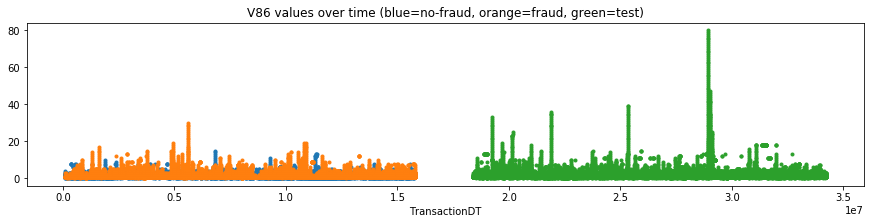

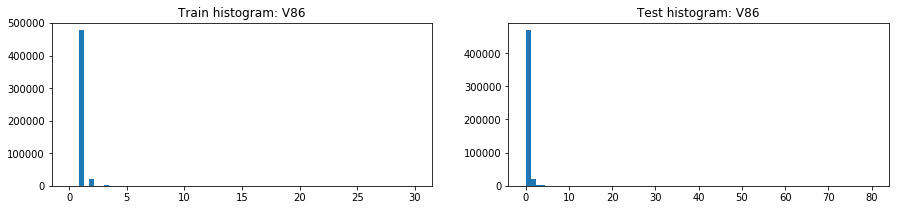

,V86,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,1.064885,1.640020,1.045453,1.092463,1.094457,1.091995
2,std,0.419807,1.737494,0.261994,0.896628,0.683657,0.939644
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,30.000000,30.000000,15.000000,80.000000,33.000000,80.000000
8,unique values,32.000000,32.000000,17.000000,82.000000,35.000000,82.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V86,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,476911,0.025766,12288,467922
1,-999.0,89164,0.047957,4276,12081
2,2.0,19527,0.095355,1862,21070
3,3.0,2428,0.358320,870,2684
4,4.0,743,0.675639,502,1112
5,0.0,727,0.070151,51,338
6,5.0,355,0.678873,241,317
7,6.0,217,0.764977,166,255
8,7.0,128,0.929688,119,129
9,8.0,86,0.697674,60,94


,V86,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,476911,0.025766,12288,467922
1,-999.0,89164,0.047957,4276,12081
2,2.0,19527,0.095355,1862,21070
3,3.0,2428,0.358320,870,2684
4,4.0,743,0.675639,502,1112
5,5.0,355,0.678873,241,317
6,6.0,217,0.764977,166,255
7,7.0,128,0.929688,119,129
8,9.0,79,0.936709,74,75
9,8.0,86,0.697674,60,94


,Column,Correlation with V86
0,V86,1.000000
1,V87,0.849442
2,V257,0.661346
3,V246,0.635958
4,V44,0.627641
5,V45,0.607564
375,V53,-0.078161
376,V54,-0.080616
377,D8,-0.109106
378,V326,-0.113469


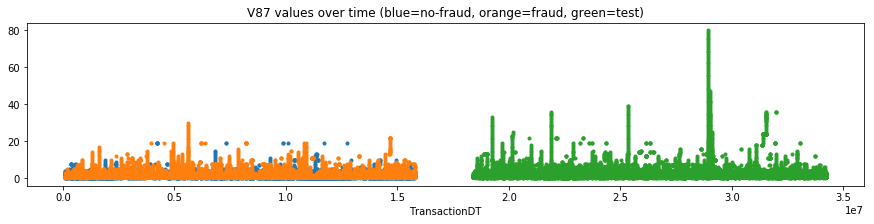

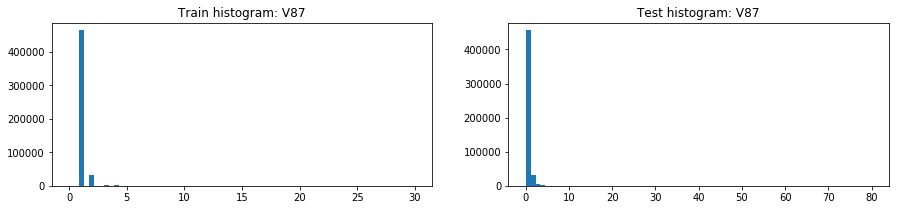

,V87,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,1.099456,1.799658,1.075798,1.131732,1.134298,1.131129
2,std,0.511281,2.020390,0.339411,0.989353,0.747773,1.037937
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
7,max,30.000000,30.000000,19.000000,80.000000,33.000000,80.000000
8,unique values,32.000000,32.000000,18.000000,82.000000,35.000000,82.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V87,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,463708,0.024893,11543,455162
1,-999.0,89164,0.047957,4276,12081
2,2.0,30832,0.072490,2235,31444
3,3.0,3761,0.248338,934,4209
4,4.0,1033,0.620523,641,1299
5,0.0,694,0.053314,37,328
6,5.0,480,0.585417,281,482
7,6.0,205,0.741463,152,349
8,7.0,148,0.905405,134,338
9,8.0,147,0.795918,117,170


,V87,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,463708,0.024893,11543,455162
1,-999.0,89164,0.047957,4276,12081
2,2.0,30832,0.072490,2235,31444
3,3.0,3761,0.248338,934,4209
4,4.0,1033,0.620523,641,1299
5,5.0,480,0.585417,281,482
6,6.0,205,0.741463,152,349
7,7.0,148,0.905405,134,338
8,8.0,147,0.795918,117,170
9,9.0,75,0.906667,68,95


,Column,Correlation with V87
0,V87,1.000000
1,V86,0.849442
2,V45,0.634342
3,V257,0.601958
4,V246,0.586705
5,V199,0.538906
375,V29,-0.073366
376,V69,-0.073509
377,V326,-0.090243
378,D8,-0.109901


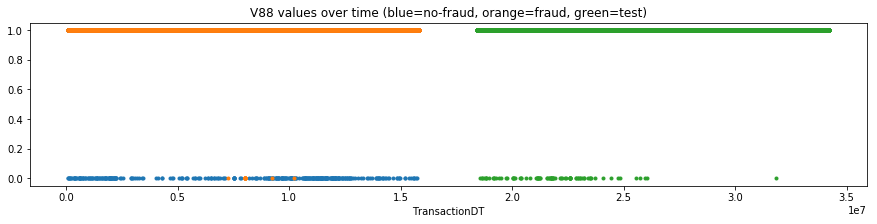

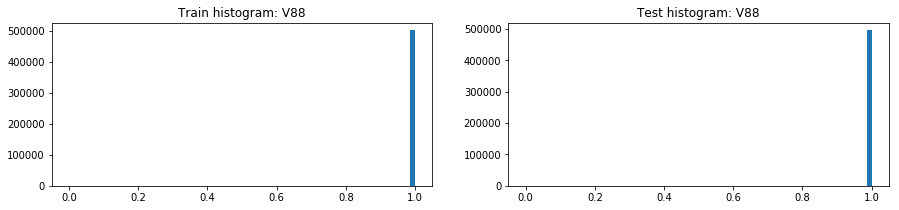

,V88,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.999246,0.999329,0.999243,0.999830,0.999521,0.999903
2,std,0.027447,0.025901,0.027498,0.013031,0.021872,0.009866
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,unique values,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V88,Count in train (desc),Mean target,Sum target,Count in test
0,1.0,500998,0.032687,16376,494526
1,-999.0,89164,0.047957,4276,12081
2,0.0,378,0.029101,11,84


,V88,Count in train,Mean target,Sum target (desc),Count in test
0,1.0,500998,0.032687,16376,494526
1,-999.0,89164,0.047957,4276,12081
2,0.0,378,0.029101,11,84


,Column,Correlation with V88
0,V88,1.000000
1,V41,0.942586
2,V14,0.834647
3,V65,0.794566
4,V1,0.547708
5,V46,0.143880
375,V153,-0.051329
376,V302,-0.053432
377,D8,-0.055283
378,D6,-0.055864


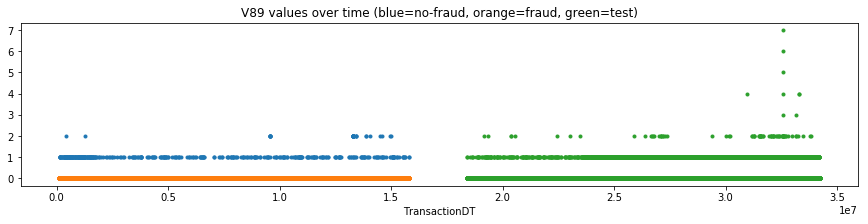

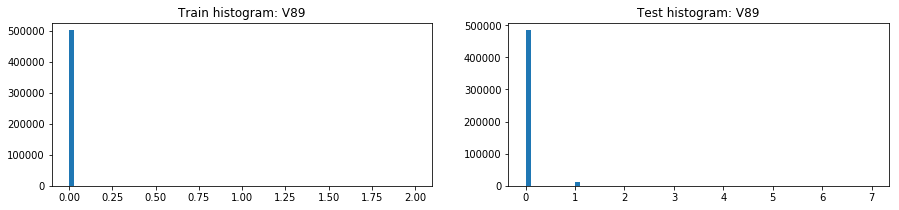

,V89,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.0000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.000902,0.0000,0.000932,0.022771,0.001266,0.027819
2,std,0.031943,0.0000,0.032478,0.151194,0.037019,0.166641
3,min,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
7,max,2.000000,0.0000,2.000000,7.000000,2.000000,7.000000
8,unique values,4.000000,2.0000,4.000000,9.000000,4.000000,9.000000
9,NaNs,89164.000000,4276.0000,84888.000000,12081.000000,7317.000000,4764.000000


,V89,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,500954,0.032712,16387,483452
1,-999.0,89164,0.047957,4276,12081
2,1.0,392,0.000000,0,11075
3,2.0,30,0.000000,0,74


,V89,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,500954,0.032712,16387,483452
1,-999.0,89164,0.047957,4276,12081
2,1.0,392,0.000000,0,11075
3,2.0,30,0.000000,0,74


,Column,Correlation with V89
0,V89,1.000000
1,V28,0.968086
2,V27,0.935332
3,V68,0.913305
4,C3,0.592326
5,V264,0.211481
360,V19,-0.048405
361,V83,-0.051946
362,V82,-0.055381
363,V327,-0.062781


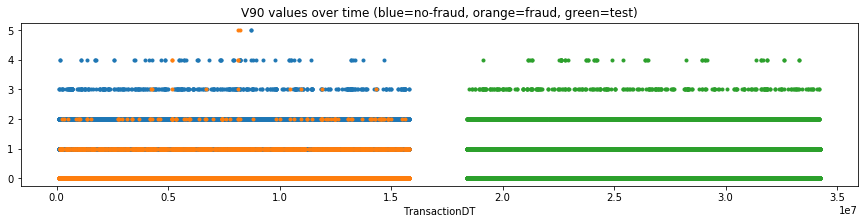

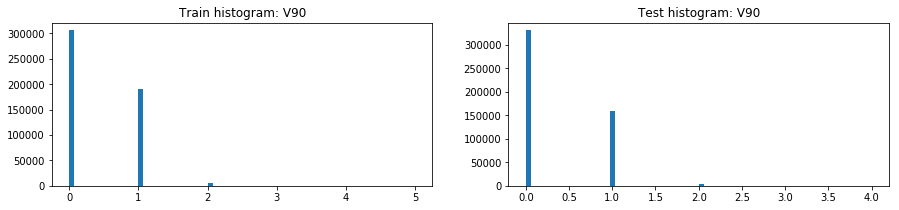

,V90,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.401862,0.092512,0.412315,0.340953,0.412669,0.324123
2,std,0.516153,0.322831,0.518220,0.494283,0.516688,0.487351
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000
8,unique values,7.000000,7.000000,7.000000,6.000000,6.000000,6.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V90,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,305817,0.049062,15004,330402.0
1,1.0,190162,0.006694,1273,160149.0
2,-999.0,89164,0.047957,4276,12081.0
3,2.0,4941,0.019227,95,3734.0
4,3.0,388,0.023196,9,278.0
5,4.0,64,0.062500,4,47.0
6,5.0,4,0.500000,2,NaN


,V90,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,305817,0.049062,15004,330402.0
1,-999.0,89164,0.047957,4276,12081.0
2,1.0,190162,0.006694,1273,160149.0
3,2.0,4941,0.019227,95,3734.0
4,3.0,388,0.023196,9,278.0
5,4.0,64,0.062500,4,47.0
6,5.0,4,0.500000,2,NaN


,Column,Correlation with V90
0,V90,1.000000
1,V91,0.959692
2,V48,0.944901
3,V29,0.932192
4,V69,0.925255
5,V49,0.917756
208,V34,-0.310988
209,V92,-0.311532
210,V52,-0.313828
211,V51,-0.318642


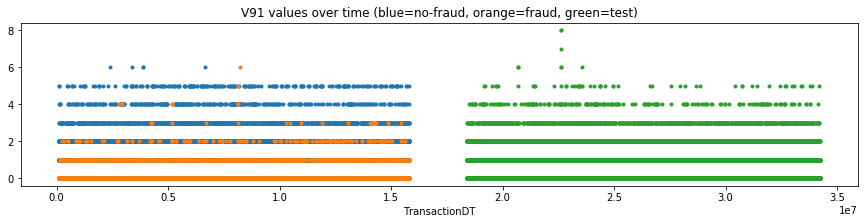

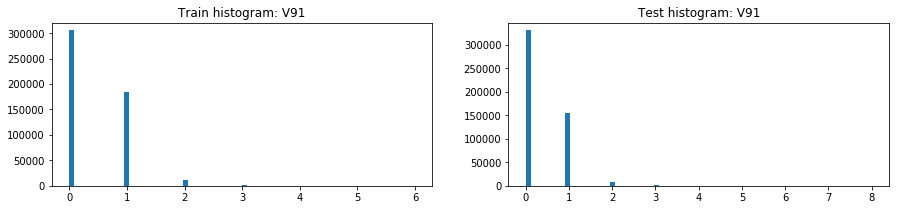

,V91,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.420461,0.098127,0.431352,0.356810,0.432027,0.339158
2,std,0.561865,0.349208,0.564455,0.534183,0.559849,0.526424
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,max,6.000000,6.000000,6.000000,8.000000,6.000000,8.000000
8,unique values,8.000000,8.000000,8.000000,10.000000,8.000000,10.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V91,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,305135,0.049159,15000,329824
1,1.0,184121,0.006539,1204,154755
2,-999.0,89164,0.047957,4276,12081
3,2.0,10470,0.014900,156,8720
4,3.0,1086,0.017495,19,1035
5,4.0,336,0.017857,6,211
6,5.0,222,0.004505,1,57
7,6.0,6,0.166667,1,5


,V91,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,305135,0.049159,15000,329824
1,-999.0,89164,0.047957,4276,12081
2,1.0,184121,0.006539,1204,154755
3,2.0,10470,0.014900,156,8720
4,3.0,1086,0.017495,19,1035
5,4.0,336,0.017857,6,211
6,5.0,222,0.004505,1,57
7,6.0,6,0.166667,1,5


,Column,Correlation with V91
0,V91,1.000000
1,V90,0.959692
2,V49,0.925746
3,V30,0.916219
4,V48,0.909608
5,V70,0.907717
208,V34,-0.298756
209,V92,-0.299432
210,V52,-0.302212
211,V51,-0.306848


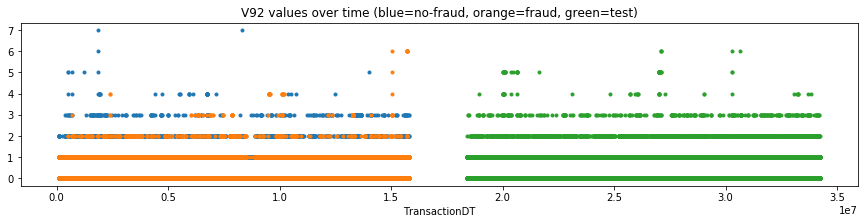

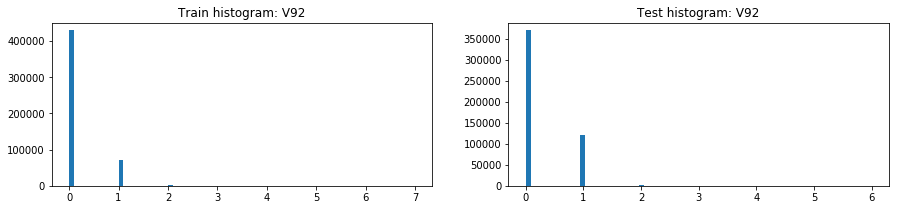

,V92,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.150322,0.519253,0.137857,0.259865,0.127300,0.290979
2,std,0.375682,0.609271,0.358622,0.460140,0.361654,0.475008
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,7.000000,6.000000,7.000000,6.000000,5.000000,6.000000
8,unique values,9.000000,8.000000,9.000000,8.000000,7.000000,8.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V92,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,428699,0.020161,8643,370042.0
1,-999.0,89164,0.047957,4276,12081.0
2,1.0,70511,0.101346,7146,121235.0
3,2.0,1744,0.271216,473,2844.0
4,3.0,348,0.281609,98,401.0
5,4.0,57,0.333333,19,39.0
6,6.0,8,0.875000,7,5.0
7,5.0,7,0.142857,1,44.0
8,7.0,2,0.000000,0,NaN


,V92,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,428699,0.020161,8643,370042.0
1,1.0,70511,0.101346,7146,121235.0
2,-999.0,89164,0.047957,4276,12081.0
3,2.0,1744,0.271216,473,2844.0
4,3.0,348,0.281609,98,401.0
5,4.0,57,0.333333,19,39.0
6,6.0,8,0.875000,7,5.0
7,5.0,7,0.142857,1,44.0
8,7.0,2,0.000000,0,NaN


,Column,Correlation with V92
0,V92,1.000000
1,V50,0.970760
2,V31,0.965936
3,V93,0.963108
4,V71,0.960691
5,V32,0.945899
362,V145,-0.459852
363,V36,-0.462045
364,V150,-0.464599
365,V151,-0.492945


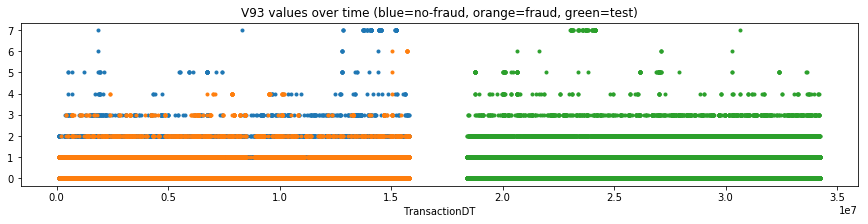

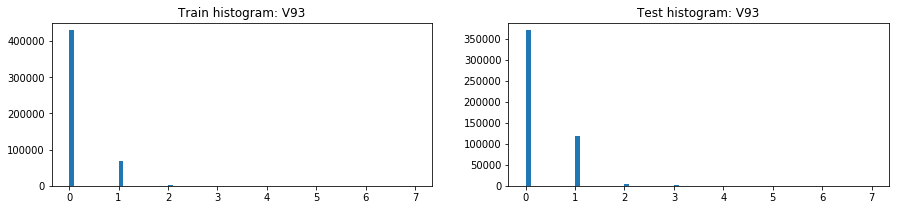

,V93,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.154812,0.550925,0.141428,0.266691,0.132395,0.298211
2,std,0.402314,0.671300,0.382908,0.485723,0.387364,0.500855
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,max,7.000000,6.000000,7.000000,7.000000,6.000000,7.000000
8,unique values,9.000000,8.000000,9.000000,9.000000,8.000000,9.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V93,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,428694,0.020157,8641,370007
1,-999.0,89164,0.047957,4276,12081
2,1.0,69196,0.097824,6769,118930
3,2.0,2682,0.271439,728,4593
4,3.0,556,0.374101,208,819
5,7.0,109,0.000000,0,65
6,4.0,80,0.412500,33,106
7,5.0,46,0.021739,1,84
8,6.0,13,0.538462,7,6


,V93,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,428694,0.020157,8641,370007
1,1.0,69196,0.097824,6769,118930
2,-999.0,89164,0.047957,4276,12081
3,2.0,2682,0.271439,728,4593
4,3.0,556,0.374101,208,819
5,4.0,80,0.412500,33,106
6,6.0,13,0.538462,7,6
7,5.0,46,0.021739,1,84
8,7.0,109,0.000000,0,65


,Column,Correlation with V93
0,V93,1.000000
1,V92,0.963108
2,V72,0.945832
3,V50,0.933852
4,V31,0.928171
5,V71,0.924839
362,V35,-0.434321
363,V54,-0.440320
364,V36,-0.443854
365,V151,-0.445465


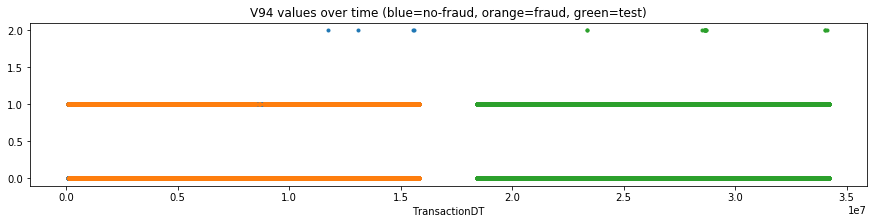

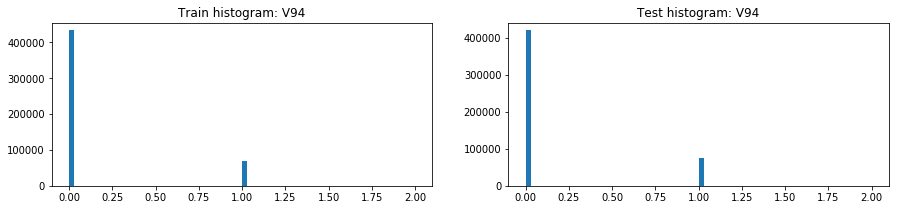

,V94,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,501376.000000,16387.000000,484989.000000,494610.000000,94022.000000,400589.000000
1,mean,0.137007,0.489473,0.125098,0.152702,0.117802,0.160893
2,std,0.343878,0.499904,0.330855,0.359779,0.322375,0.367528
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000
8,unique values,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000
9,NaNs,89164.000000,4276.000000,84888.000000,12081.000000,7317.000000,4764.000000


,V94,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,432688,0.019335,8366,419096
1,-999.0,89164,0.047957,4276,12081
2,1.0,68684,0.116781,8021,75500
3,2.0,4,0.000000,0,14


,V94,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,432688,0.019335,8366,419096
1,1.0,68684,0.116781,8021,75500
2,-999.0,89164,0.047957,4276,12081
3,2.0,4,0.000000,0,14


,Column,Correlation with V94
0,V94,1.000000
1,V33,0.975796
2,V15,0.953582
3,V51,0.950989
4,V73,0.946165
5,V57,0.936173
328,V53,-0.412627
329,V35,-0.417277
330,V54,-0.423711
331,V36,-0.427154


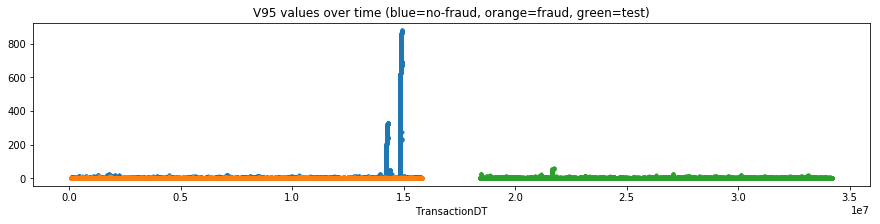

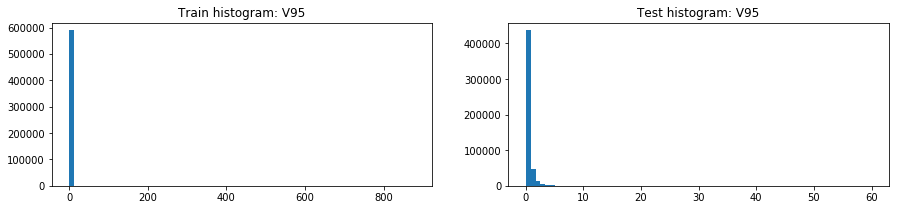

,V95,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590226.000000,20646.000000,569580.000000,506691.000000,101339.000000,405353.000000
1,mean,1.038019,0.582873,1.054517,0.231695,0.270952,0.221881
2,std,21.034304,1.239608,21.410652,0.859311,1.210804,0.745671
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,880.000000,13.000000,880.000000,60.000000,60.000000,27.000000
8,unique values,882.000000,15.000000,882.000000,61.000000,61.000000,28.000000
9,NaNs,314.000000,17.000000,297.000000,0.000000,0.000000,0.000000


,V95,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,510542,0.028568,14585,436511.0
1,1.0,52008,0.063740,3315,46915.0
2,2.0,14804,0.089976,1332,13276.0
3,3.0,5758,0.112365,647,4986.0
4,4.0,2646,0.125472,332,2330.0
5,5.0,1281,0.135831,174,1116.0
6,6.0,684,0.141813,97,578.0
7,7.0,411,0.163017,67,322.0
8,-999.0,314,0.054140,17,NaN
9,8.0,239,0.184100,44,196.0


,V95,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,510542,0.028568,14585,436511
1,1.0,52008,0.063740,3315,46915
2,2.0,14804,0.089976,1332,13276
3,3.0,5758,0.112365,647,4986
4,4.0,2646,0.125472,332,2330
5,5.0,1281,0.135831,174,1116
6,6.0,684,0.141813,97,578
7,7.0,411,0.163017,67,322
8,8.0,239,0.184100,44,196
9,9.0,167,0.191617,32,119


,Column,Correlation with V95
0,V95,1.000000
1,V322,0.999949
2,V101,0.999594
3,V279,0.998710
4,V293,0.998475
5,V132,0.995258
375,V155,-0.132920
376,V148,-0.137331
377,V154,-0.144542
378,V153,-0.147642


In [4]:
for col in list(tr.columns.values[:COLS_TO_SHOW]):
    proc(col)